# Speech Processing Algorithms for Speech / Non-Speech Detection

Students List:
- 522K0026 - Nguyen Duc Anh
- 522K0045 - Keni Nicholas Ondang
- 522K0050 - Thant Thiri Maung

## Table of Contents

<!--toc:start-->
- [1. Introduction](#1-introduction)
  - [1.1 Background and Rationale](#11-background-and-rationale)
  - [1.2 The Acoustic Basis](#12-the-acoustic-basis)
  - [1.3 Algorithms Overview](#13-algorithms-overview)
- [2. Problem Definition](#2-problem-definition)
  - [2.1 Mathematical Definition](#21-mathematical-definition)
  - [2.2 Input Definition](#22-input-definition)
  - [2.3 Output Definition](#23-output-definition)
  - [2.4 Class Definitions (Speech vs. Non-Speech)](#24-class-definitions-speech-vs-non-speech)
- [3. Dataset Description and Preparation](#3-dataset-description-and-preparation)
  - [3.1 System Configuration and Imports](#31-system-configuration-and-imports)
  - [3.2 Data Specifications](#32-data-specifications)
  - [3.3 File Naming Convention and Organization](#33-file-naming-convention-and-organization)
  - [3.4 Dataset Initialization and File Manifest](#34-dataset-initialization-and-file-manifest)
  - [3.5 Data Loading and Visualization Utilities](#35-data-loading-and-visualization-utilities)
  - [3.6 Dataset Summary and Visualization](#36-dataset-summary-and-visualization)
  - [3.7 Sample Recording Analysis: Time, Frequency, and Energy Domains](#37-sample-recording-analysis-time-frequency-and-energy-domains)
- [4. Pre-processing Pipeline & Feature Extraction](#4-pre-processing-pipeline-feature-extraction)
  - [4.1 Overview](#41-overview)
  - [4.2 Peak Normalization](#42-peak-normalization)
  - [4.3 Signal Framing (Short-Time Analysis)](#43-signal-framing-short-time-analysis)
  - [4.4 Hamming Windowing](#44-hamming-windowing)
  - [4.5 Short-Time Energy (RMS) Extraction](#45-short-time-energy-rms-extraction)
  - [4.6 Pipeline Demonstration and Verification](#46-pipeline-demonstration-and-verification)
- [5. Algorithm 1: Energy-Based Detection (STE)](#5-algorithm-1-energy-based-detection-ste)
  - [5.1 Overview and Theoretical Goal](#51-overview-and-theoretical-goal)
  - [5.2 Mathematical Formulation](#52-mathematical-formulation)
  - [5.3 Threshold Adaptation](#53-threshold-adaptation)
  - [5.4 Inputs and Outputs](#54-inputs-and-outputs)
  - [5.5 Procedural Logic](#55-procedural-logic)
  - [5.6 Pseudocode](#56-pseudocode)
  - [5.7 Implementation](#57-implementation)
  - [5.8 Visualization and Analysis](#58-visualization-and-analysis)
  - [5.9 Batch Processing and Output Generation](#59-batch-processing-and-output-generation)
- [6. Algorithm 2: Hybrid STE + ZCR Detection](#6-algorithm-2-hybrid-ste-zcr-detection)
  - [6.1 Overview and Theoretical Goal](#61-overview-and-theoretical-goal)
  - [6.2 Mathematical Formulation](#62-mathematical-formulation)
  - [6.3 Inputs and Outputs](#63-inputs-and-outputs)
  - [6.4 Procedural Logic](#64-procedural-logic)
  - [6.5 Pseudocode](#65-pseudocode)
  - [6.6 Implementation](#66-implementation)
  - [6.7 Visualization and Analysis](#67-visualization-and-analysis)
  - [6.8 Batch Processing and Output Generation](#68-batch-processing-and-output-generation)
- [7. Algorithm 3: Statistical Classification](#7-algorithm-3-statistical-classification)
  - [7.1 Feature Extraction: MFCCs](#71-feature-extraction-mfccs)
  - [7.2 Training Data: Google AVA-Speech](#72-training-data-google-ava-speech)
  - [7.3 Algorithm Description: GMM-based Classification](#73-algorithm-description-gmm-based-classification)
    - [7.3.1 The Gaussian Mixture Model](#731-the-gaussian-mixture-model)
    - [7.3.2 Training Phase (EM Algorithm)](#732-training-phase-em-algorithm)
    - [7.3.3 Classification Phase: Log-Likelihood Ratio (LLR)](#733-classification-phase-log-likelihood-ratio-llr)
    - [7.3.4 Inputs and Outputs](#734-io)
    - [7.3.5 Pseudocode](#gmm-code)
    - [7.3.6 Implementation](#gmm-impl)
    - [7.3.7 Visualization: GMM-Based VAD Results](#735-visualization-gmm-based-vad-results)
- [8. Algorithm 4: Deep Neural Nerwork](#8-algorithm-4-deep-neural-nerwork)
  - [8.1 Overview and Goal](#81-overview-and-goal)
  - [8.2 Feature Extraction](#82-feature-extraction)
  - [8.3 Model Architecture](#83-model-architecture)
  - [8.4 Dataset and Experimental Setup](#84-dataset-and-experimental-setup)
  - [8.5 Procedural Logic](#85-procedural-logic)
  - [8.6 Inputs and Outputs](#86-inputs-and-outputs)
  - [8.7 Pseudocode](#dnn-code)
  - [8.8 Implementation](#dnn-impl)
  - [8.9 Visualization: DNN-Based VAD Performance](#87-visualization)
- [9. Experiment Results and Evaluation](#9-evaluation)
  - [9.1 Load data for GMMs](#91-load-data-for-gmms)
  - [9.2 Task Based Evaluation (Speaker Recognition Module)](#92-evaluation-energy-based-detection-ste)
  - [9.3 Quantitative Task-Based Evaluation (SRM Impact)](#93-evaluate-hybrid-ste-zcr-detection)
    - [9.3.1 The Dominance of Algorithm 1](#934-algo-1)
    - [9.3.2 The "Noise Penalty" of Algorithm 2](#934-algo-2)
    - [9.3.3 Algorithm 3: The Domain Contamination](#934-algo-3)
    - [9.3.4 Algorithm 4: The "Fragmentation" Trap](#934-algo-4)
- [References](#references)
<!--toc:end-->


## <a name="1-introduction"/> 1. Introduction

### <a name="11-background-and-rationale"/> 1.1 Background and Rationale

**Voice Activity Detection (VAD)**, also known as speech activity detection, is a fundamental signal processing task defined as the segregation of an audio stream into two distinct classes: **Speech ($H_1$)** and **Non-Speech/Noise ($H_0$)**.



As detailed in the accompanying report, VAD serves as a critical pre-processing front-end for downstream applications such as **Automatic Speech Recognition (ASR)**, speaker diarization, and bandwidth-efficient telecommunications. The necessity of VAD stems from the "efficiency trade-off" inherent in digital speech processing:

* **Aggressive VAD:** Risks "**clipping**" the low-energy ends of words (e.g., unvoiced fricatives like /f/ or /s/), destroying intelligibility.
* **Passive VAD:** Allows environmental noise to pass through, wasting computational resources and degrading the accuracy of ASR engines.

### <a name="12-the-acoustic-basis"/> 1.2 The Acoustic Basis

This project bridges the gap between the **Acoustic Theory of Speech Production** (**Source-Filter Model**) and algorithmic implementation. By understanding that speech is composed of **Voiced Phonation** (periodic, high energy) and **Unvoiced Frication** (aperiodic, high frequency), we can design algorithms that target these specific physical characteristics.



[Image of Source-Filter model of speech production]


### <a name="13-algorithms-overview"/> 1.3 Algorithms Overview

In this notebook, we implement and evaluate algorithms ranging from deterministic signal processing to statistical modeling, as outlined in the report's methodology:

* **Algorithm 1: Energy-Based Detection (STE)**
    * **Principle:** Uses **Short-Time Energy** to detect high-pressure voiced segments (vowels).
    * **Limitation:** Susceptible to background noise and often misses low-energy unvoiced consonants.

* **Algorithm 2: Hybrid Frequency-Energy Detection (STE + ZCR)**
    * **Principle:** A multi-dimensional approach combining Energy with **Zero-Crossing Rate (ZCR)**.
    * **Improvement:** Specifically designed to detect "hissing" unvoiced sounds (high ZCR) that simple energy detectors miss. Includes a **Hangover Scheme** for temporal smoothing.

* **Algorithm 3: Statistical Classification (GMM)**
    * **Principle:** Uses **Gaussian Mixture Models (GMM)** to calculate the **Log-Likelihood Ratio (LLR)** that a frame belongs to a speech cluster versus a noise cluster.

* **Algorithm 4: Deep Neural Network (DNN)**
    * **Principle:** A supervised **Feed-Forward Network (Multi-Layer Perceptron)** that maps high-dimensional features (MFCCs) directly to a probability of speech presence. It learns complex, non-linear decision boundaries without assuming specific statistical distributions.
    * **Characteristic:** Acts as a **"Strict Gatekeeper"** achieving high precision by aggressively filtering noise, though it can suffer from **temporal fragmentation** (jitter) when applied to acoustic environments different from its training data.

The following sections will guide you through the mathematical definition, data preparation, and step-by-step implementation of these core algorithms.

## <a name="2-problem-definition"/> 2. Problem Definition

### <a name="21-mathematical-definition"/> 2.1 Mathematical Definition

The **Voice Activity Detection (VAD)** task is formally defined as a **binary hypothesis testing** problem. We model the system as a transformation $T$ that maps an acoustic input sequence to a binary output sequence.

Let $s(t)$ be a continuous-time speech signal sampled at a frequency $f_s$ to produce the discrete-time signal $x[n]$:

$$x[n] = s(n T_s), \quad \text{where } T_s = 1/f_s$$

Because speech signals are non-stationary (their statistical properties change rapidly over time), we cannot process the entire signal $x[n]$ at once. Instead, we decompose it into short-time segments called frames. Let $f_m$ denote the $m$-th frame of length $N$ with a hop size $H$:

$$f_m = [x[mH], x[mH+1], \dots, x[mH+N-1]]$$

The VAD system $T$ performs a mapping $T: \mathcal{X} \rightarrow \mathcal{Y}$, where the input is the set of frames $\mathcal{X} = \{f_1, f_2, \dots, f_M\}$ and the output is the binary decision sequence $\mathcal{Y} = \{y[1], y[2], \dots, y[M]\}$.

For each frame $m$, the system chooses between two hypotheses:

* $H_0$ (**Null Hypothesis**): The frame contains only Noise or Silence ($y[m] = 0$).
* $H_1$ (**Alternative Hypothesis**): The frame contains Speech ($y[m] = 1$).

### <a name="22-input-definition"/> 2.2 Input Definition

**Mathematical Notation and Framing**

As established in the Theoretical Framework of the report, speech is a **non-stationary** signal, meaning its statistical properties change rapidly over time. Therefore, we cannot process the entire audio file as a single global vector. Instead, we must apply the concept of **Short-Time Stationarity** by transforming the raw signal into a sequence of short, overlapping segments called frames.

* **The Discrete Signal ($x[n]$):**
    The primary input is a discrete-time signal $x[n]$ obtained by sampling the continuous speech wave $s(t)$ at a frequency $f_s$ ($16 \text{ kHz}$ for this project).
    $$x[n] = s(n \cdot T_s) \quad \text{where } T_s = 1/f_s$$

* **The Framed Input ($\mathcal{X}$):**
    To analyze the signal, we segment $x[n]$ into a set of $M$ overlapping frames. Let $N$ be the frame length and $H$ be the hop length. The $m$-th frame is defined as the vector:
    $$f_m = [x[mH], x[mH+1], \dots, x[mH+N-1]]$$
    Consequently, the true input to our detection system is the set of all frames $\mathcal{X} = \{f_1, f_2, \dots, f_M\}$.

**Python Data Structure**

In our implementation, we represent these mathematical concepts using **numpy arrays** to leverage efficient vectorization:

* **Raw Signal ($\text{y}$ or $\text{x}$):** A 1D `numpy.ndarray` of floating-point values representing amplitudes.
* **Framed Signal ($\mathcal{X}$):** A 2D `numpy.ndarray` where each row corresponds to a single frame $f_m$.
    * **Shape:** `(Num_Frames, Frame_Length)`.

### <a name="23-output-definition"/> 2.3 Output Definition

**Mathematical Notation and Decision Function**
The goal of the VAD system is to map the input set of frames $\mathcal{X}$ to a binary decision sequence $\mathcal{Y}$. This is a sequence-to-sequence mapping problem.

The output is a discrete sequence $y[m]$, where $m$ is the frame index. For each frame, the system performs a **binary hypothesis test** to distinguish between two mutually exclusive classes:

* $H_1$ (**Speech**): The frame contains voiced or unvoiced speech activity ($y[m] = 1$).
* $H_0$ (**Non-Speech**): The frame contains silence, stationary noise, or non-stationary background noise ($y[m] = 0$).

The system $T$ is therefore defined as the mapping:
$$T: \mathcal{X} \rightarrow \mathcal{Y}, \quad \text{where } y_m \in \{0, 1\}$$

**Python Data Structure**
The output is represented as a 1D `numpy.ndarray` or integer list consisting of $0$s and $1$s.

* **Shape:** `(Num_Frames,)`.
* **Alignment:** The length of this output array must exactly match the number of rows in the input matrix $\mathcal{X}$.

### <a name="24-class-definitions-speech-vs-non-speech"/> 2.4 Class Definitions (Speech vs. Non-Speech)

Based on the **Acoustic Theory of Speech Production** (**Source-Filter Model**), we define the two classes strictly to avoid ambiguity during evaluation.

**1. The Speech Class ($H_1$)**
This includes all acoustic events generated by the human vocal tract that carry linguistic information. It is further categorized into:

* **Voiced Speech:** Produced by the periodic vibration of vocal folds.
    * **Characteristics:** **High Short-Time Energy (STE)**, periodicity, **low Zero-Crossing Rate (ZCR)**.
    * **Examples:** Vowels (/a/, /e/, /u/), voiced consonants (/z/, /b/).

* **Unvoiced Speech:** Produced by turbulent airflow through constrictions (teeth, lips) without vocal fold vibration.
    * **Characteristics:** **Low Energy**, stochastic/noise-like waveform, **High ZCR**.
    * **Examples:** Fricatives (/s/, /f/, /sh/), stops (/t/, /k/).

**Note:** This subclass is the most difficult to detect and is often subject to "**clipping**" errors.

**2. The Non-Speech Class ($H_0$)**
This includes all signal components not generated by the target speaker:

* **Silence:** Digital zeros or near-zero amplitude (sensor noise floor).
* **Stationary Noise:** Constant statistical properties over time (e.g., HVAC hum, computer fans, pink noise).
* **Non-Stationary Noise:** Abrupt, transient sounds (e.g., door slams, keyboard typing, background "babble" noise).

## <a name="3-dataset-description-and-preparation"/> 3. Dataset Description and Preparation
### <a name="31-system-configuration-and-imports"/> 3.1 System Configuration and Imports

Before processing the audio, we initialize the Python environment, install necessary dependencies (Librosa), and define the global signal processing constants derived from the System Configuration section of the report 1.

**Key Constants:**

* `SAMPLE_RATE` ($16 \text{ kHz}$): Matches the recording specification.
* `FRAME_LENGTH` ($512$): Defines the analysis window size ($N$) for short-time stationarity.
* `STE_THRESHOLD` ($8 \text{ dB}$): The calibrated energy threshold for **Algorithm 1**.

In [1]:
import numpy as np
import pickle 
import os
import librosa
import matplotlib.pyplot as plt
import pandas as pd
import keras

from functools import partial
from keras import layers
from sklearn.mixture import GaussianMixture

In [2]:
# Global Config Constants
# Recordings
SAMPLE_RATE   = 16000         
FRAME_LENGTH  = 512          
HOP_LENGTH    = FRAME_LENGTH // 4

# Set random seed
RANDOM_SEED = 42
keras.utils.set_random_seed(RANDOM_SEED)

# Algorithm 1
STE_THRESHOLD = 8            

# Algorithm 2
ZCR_THRESHOLD = 0.2        
HANGOVER      = 5            
HYBRID_ENERGY_THRESHOLD = 8   

# Algorithm 3
N_MFCC = 13
N_MELS = 26
N_GMM_COMPONENTS = 16
GMM_MAX_ITER = 50
GMM_THRESHOLD = 0

# Algorithm 5
SEQUENCE_LENGTH = 125

print("Global configuration loaded.")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Global configuration loaded.


### <a name="32-data-specifications"/> 3.2 Data Specifications

To evaluate the proposed VAD algorithms, a custom dataset was created by the project group members. The dataset focuses on four specific keywords, chosen to represent different phonetic characteristics (voiced vowels, unvoiced fricatives, and plosives) essential for testing.

The dataset specifications are as follows:

* **Contributors:** 3 speakers (Keni Nicholas Ondang, Thant Thiri Maung, Nguyen Duc Anh).
* **Target Keywords:**
    * "**yes**" (/jes/)
    * "**yeah**" (/jeə/)
    * "**present**" (/ˈpreznt/)
    * "**here**" (/hɪə/)
* **Quantity:** 10 iterations per word per student.
    $$\text{Total} = 3 \times 4 \times 10 = 120 \text{ recordings}$$
* **Audio Format:**
    * **Sampling Rate ($f_s$):** $16,000 \text{ Hz}$ ($16 \text{ kHz}$)
    * **Channels:** Mono (Single channel)
    * **File Type:** `.wav`

### <a name="33-file-naming-convention-and-organization"/> 3.3 File Naming Convention and Organization

To facilitate automated processing, all audio files adhere to the following naming syntax:

`word_X_FullName.wav`

Where:

* $\text{word} \in \{\text{yes, yeah, present, here}\}$
* $X$ is the repetition index ($1$ to $10$)
* `FullName` is the student's name (e.g., `KeniNicholasOndang`)

**Example:**
`here_1_KeniNicholasOndang.wav` represents the **first** attempt of the word "here" by Keni Nicholas Ondang.

### <a name="34-dataset-initialization-and-file-manifest"/> 3.4 Dataset Initialization and File Manifest

This section initializes the global configuration for the dataset, defining the root directory, student identifiers, target keywords, and the required number of iterations per word.

It implements the `generate_file_manifest` utility function, which constructs a structured dictionary of all expected file paths based on the project's naming convention:

`word_X_FullName.wav`

This manifest acts as a complete **inventory checklist**, ensuring that downstream processes can systematically load the data and identify any missing recordings before signal processing begins.

In [3]:
DATASET_TRAIN_PATH = "dataset/train/" 
STUDENTS = [
    "KeniNicholasOndang",
    "ThantThiriMaung",
    "NguyenDucAnh"
]
KEYWORDS = ["yes", "yeah", "present", "here"]
NUM_ITERATIONS = 10

In [4]:
def generate_file_manifest(
    path: str,
    students: list[str],
    keywords: list[str],
    iterations: int
) -> tuple[dict, int]:
    """
    Generate a manifest of expected audio file metadata organized by student.

    This function builds a dictionary where each student name maps to a list
    of file descriptors. Each descriptor represents an expected `.wav` file
    following this naming rule:

        word_index_student.wav

    Parameters
    ----------
    path : str
        Base directory that contains the student folders.
    students : list[str]
        List of student names (used as folder and filename identifiers).
    keywords : list[str]
        List of keyword labels used in filenames.
    iterations : int
        Number of repetitions per keyword.

    Returns
    -------
    tuple[dict, int]
        - dict : Mapping of student name → list of file metadata dictionaries
        - int  : Total number of generated file entries

    Example
    -------
    >>> manifest, total = generate_file_manifest(
    ...     path="dataset",
    ...     students=["Alice", "Bob"],
    ...     keywords=["yes", "no"],
    ...     iterations=3
    ... )
    >>> print(total)
    12
    >>> print(manifest["Alice"][0])
    {'word': 'yes', 'index': 1, 'path': 'dataset/Alice/yes_1_Alice.wav', 'filename': 'Alice/yes_1_Alice.wav'}
    """


    manifest = {}
    total_files = 0
    
    for student in students:
        manifest[student] = []
        for word in keywords:
            for i in range(1, iterations + 1):
                # Syntax: word_X_FullName.wav
                filename = f"{student}/{word}_{i}_{student}.wav"
                file_path = os.path.join(path, filename)
                
                # Store metadata for processing
                manifest[student].append({
                    "word": word,
                    "index": i,
                    "path": file_path,
                    "filename": filename
                })
                total_files += 1
                
    return manifest, total_files

In [5]:
dataset_manifest, expected_count = generate_file_manifest(DATASET_TRAIN_PATH, STUDENTS, KEYWORDS, NUM_ITERATIONS)
print(f"Dataset Configuration Loaded.")
print(f"Total Speakers: {len(STUDENTS)}")
print(f"Total Keywords: {len(KEYWORDS)}")
print(f"Total Expected Recordings: {expected_count}")

Dataset Configuration Loaded.
Total Speakers: 3
Total Keywords: 4
Total Expected Recordings: 120


### <a name="35-data-loading-and-visualization-utilities"/> 3.5 Data Loading and Visualization Utilities

This section defines the core utility functions for handling the audio data. It implements `plot_dataset_recordings`, a versatile visualization tool that generates a grid of plots organized by student and keyword.

This function serves a dual purpose:

* **Inspecting raw waveforms** for consistency.
* **Overlaying binary VAD decision masks** for later algorithm verification.

Additionally, `load_dataset_into_memory` reads all `.wav` files from the disk, enforces the required $16 \text{ kHz}$ sampling rate, and caches the signals in a dictionary to maximize processing efficiency during the algorithmic stages.

In [75]:
from typing import Optional

def plot_dataset_recordings(
    dataset_manifest: dict,
    students: list[str],
    keywords: list[str],
    sampling_rate: int = 16000,
    vad_fn: Optional[callable] = None,
    separate_recordings: bool = False
) -> None:
    """
    Visualize audio waveforms from a dataset manifest.

    This function plots waveform visualizations of audio recordings organized
    by students and keywords. It supports two display modes:
    1) Comparison mode: columns = students, rows = keywords, all recordings overlaid.
    2) Detailed mode: when `separate_recordings=True` and only one student is provided,
       columns represent individual recording indices.

    Parameters
    ----------
    dataset_manifest : dict
        Dictionary of student → list of file metadata.
    students : list[str]
        List of student names to visualize.
    keywords : list[str]
        List of words to visualize.
    sampling_rate : int, optional
        Audio sample rate (Hz). Default is 16000.
    vad_fn : callable | None, optional
        Optional VAD function to overlay results.
    separate_recordings : bool, optional
        Enable one-recording-per-column mode. Default is False.

    Returns
    -------
    None
        Displays matplotlib figures.

    Example
    -------
    >>> manifest, _ = generate_file_manifest(
    ...     path="dataset",
    ...     students=["Alice"],
    ...     keywords=["yes", "no"],
    ...     iterations=10
    ... )
    >>> plot_dataset_recordings(
    ...     dataset_manifest=manifest,
    ...     students=["Alice"],
    ...     keywords=["yes", "no"],
    ...     separate_recordings=True
    ... )
    """

    # --- MODE 1: Detailed View (1 Student, 10 Columns) ---
    if separate_recordings and len(students) == 1:
        student = students[0]
        iterations = 10  # Assuming 10 recordings per word
        nrows = len(keywords)
        ncols = iterations
        
        # Wider figure for 10 columns
        fig, axes = plt.subplots(nrows, ncols, figsize=(24, 2.5 * nrows), sharex=True, sharey=True, squeeze=False)
        
        title = f"Detailed Analysis: {student}" + (" (Blue=Raw, Orange=VAD)" if vad_fn else "")
        fig.suptitle(title, fontsize=16, y=1.02)
        
        for r, word in enumerate(keywords):
            # Get files and map them by index
            student_files = dataset_manifest.get(student, [])
            file_map = {f['index']: f for f in student_files if f['word'] == word}

            # Loop through expected columns (1 to 10)
            for c in range(1, iterations + 1):
                # Axes are 0-indexed, so we use [c-1]
                ax = axes[r, c - 1]
                
                if c in file_map:
                    _plot_single_file(ax, file_map[c], sampling_rate, vad_fn)
                    # Optional: Add small text inside plot for specific index info
                    ax.text(0.05, 0.9, f"idx:{file_map[c].get('index')}", transform=ax.transAxes, fontsize=8, alpha=0.5)
                else:
                    ax.text(0.5, 0.5, "Missing", ha='center', va='center', color='red', alpha=0.5)

                ax.grid(True, alpha=0.2)
                
                # --- FIX: Set Side Label on the First Column ---
                # Since loop starts at 1, the first column is c == 1
                if c == 1: 
                    ax.set_ylabel(f"{word.upper()}", fontsize=14, fontweight='bold', rotation=0, labelpad=40, va='center')
                
                # Set Top Title only on first row
                if r == 0: 
                    ax.set_title(f"Rec {c}", fontsize=10, fontweight='bold', color='gray')

    # --- MODE 2: Comparison View (N Students, N Columns) ---
    else:
        nrows = len(keywords)
        ncols = len(students)
        
        fig_width = 6 * ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, 3 * nrows), sharex=True, sharey=True, squeeze=False)
        
        title = "Dataset Overview" + (" (VAD Overlay)" if vad_fn else "")
        fig.suptitle(title, fontsize=16, y=1.02)

        for r, word in enumerate(keywords):
            for c, student in enumerate(students):
                ax = axes[r, c]
                
                files_to_plot = [f for f in dataset_manifest.get(student, []) if f['word'] == word]
                
                for file_info in files_to_plot:
                    _plot_single_file(ax, file_info, sampling_rate, vad_fn, alpha=0.3)
                
                ax.grid(True, alpha=0.2)
                
                # --- FIX: Set Side Label on First Column ---
                # Enumerate starts at 0, so c == 0 is correct here
                if c == 0:
                    ax.set_ylabel(f"{word.upper()}", fontsize=14, fontweight='bold', rotation=0, labelpad=40, va='center')
                
                if r == 0: 
                    ax.set_title(student, fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

def _plot_single_file(
    ax,
    file_info: dict,
    sr: int,
    vad_fn: Optional[callable],
    alpha: float = 1.0
) -> None:
    """
    Load and plot a single waveform on a given matplotlib axis.

    This helper function reads an audio file, normalizes the waveform, and
    plots both the raw audio signal and an optional Voice Activity Detection
    (VAD) mask on the provided axis.

    Parameters
    ----------
    ax : object
        Matplotlib axis object where the waveform will be drawn.
    file_info : dict
        Dictionary containing metadata for the audio file. Must include the key:
            - "path" (str): File system path to the audio file.
    sr : int
        Sampling rate (in Hz) used when loading the audio.
    vad_fn : callable or None
        Optional function that takes a waveform (array-like) as input and
        returns a VAD mask (array-like). If None, no VAD overlay is plotted.
    alpha : float, optional
        Transparency level for the raw waveform plot. Default is 1.0.

    Returns
    -------
    None
        This function does not return anything. It performs plotting directly on
        the provided matplotlib axis.
    """
    
    try:
        y, _ = librosa.load(file_info['path'], sr=sr)
        
        # Normalize
        peak = np.max(np.abs(y))
        if peak > 0: y = y / peak
            
        time_axis = np.linspace(0, len(y) / sr, num=len(y))
        
        # Plot Raw
        ax.plot(time_axis, y, color='tab:blue', alpha=alpha, linewidth=0.5 if alpha < 1 else 0.8)
        
        # Plot VAD
        if vad_fn:
            vad_mask = vad_fn(y)
            # Ensure safe expansion (handling edge cases in array length)
            vad_expanded = np.repeat(vad_mask, HOP_LENGTH)[:len(y)]
            ax.plot(time_axis, vad_expanded * 0.8, color='tab:orange', alpha=0.8, linewidth=1.5)
            
    except FileNotFoundError:
        ax.text(0.5, 0.5, "File Not Found", ha='center', va='center', color='red')
    except Exception as e:
        ax.text(0.5, 0.5, "Error", ha='center', va='center', color='red')
        print(f"Error plotting {file_info.get('path')}: {e}")

In [76]:
def load_dataset_into_memory(manifest: dict) -> dict:
    """
    Load all .wav files listed in the manifest into memory.

    This function reads each audio file path stored in the manifest,
    loads the waveform using librosa, and stores it in a dictionary
    keyed by the filename.

    Parameters
    ----------
    manifest : dict
        Dictionary containing file metadata grouped by student. Each value
        must be a list of dictionaries that include:
            - "path" (str): Full path to the audio file
            - "filename" (str): Audio file name used as a key

    Returns
    -------
    dict
        Dictionary mapping filenames to their corresponding NumPy waveform arrays.

    Example
    -------
    >>> manifest, total = generate_file_manifest(
    ...     path="dataset",
    ...     students=["Alice", "Bob"],
    ...     keywords=["yes", "no"],
    ...     iterations=10
    ... )
    >>> audio_data = load_dataset_into_memory(manifest)
    >>> print(len(audio_data))
    40
    """
    audio_data = {}
    print("Loading audio files...")
    
    for student, files in manifest.items():
        for file_info in files:
            path = file_info['path']
            filename = file_info['filename']
            try:
                # Load audio with fixed sampling rate (16kHz)
                y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
                audio_data[filename] = y
            except FileNotFoundError:
                print(f"Warning: File not found {path}")
    return audio_data

### <a name="36-dataset-summary-and-visualization"/> 3.6 Dataset Summary and Visualization

In this step, we perform a quantitative sanity check followed by a qualitative visual inspection. The code first aggregates the total duration of all loaded audio arrays to compute global statistics, ensuring that the dataset size matches our expectations ($120$ files).

It then triggers the `plot_dataset_recordings` function to generate a $4 \times 3$ grid. This visualization separates the data by Student (columns) and Keyword (rows), overlaying all 10 iterations of each word on top of one another. This "overlay" technique allows us to immediately assess the consistency of each speaker's pronunciation and recording environment.

Loading audio files...
Total Files:        120
Total Audio Length: 225.63 seconds
Avg Length/File:    1.88 seconds
Generating Visualization...


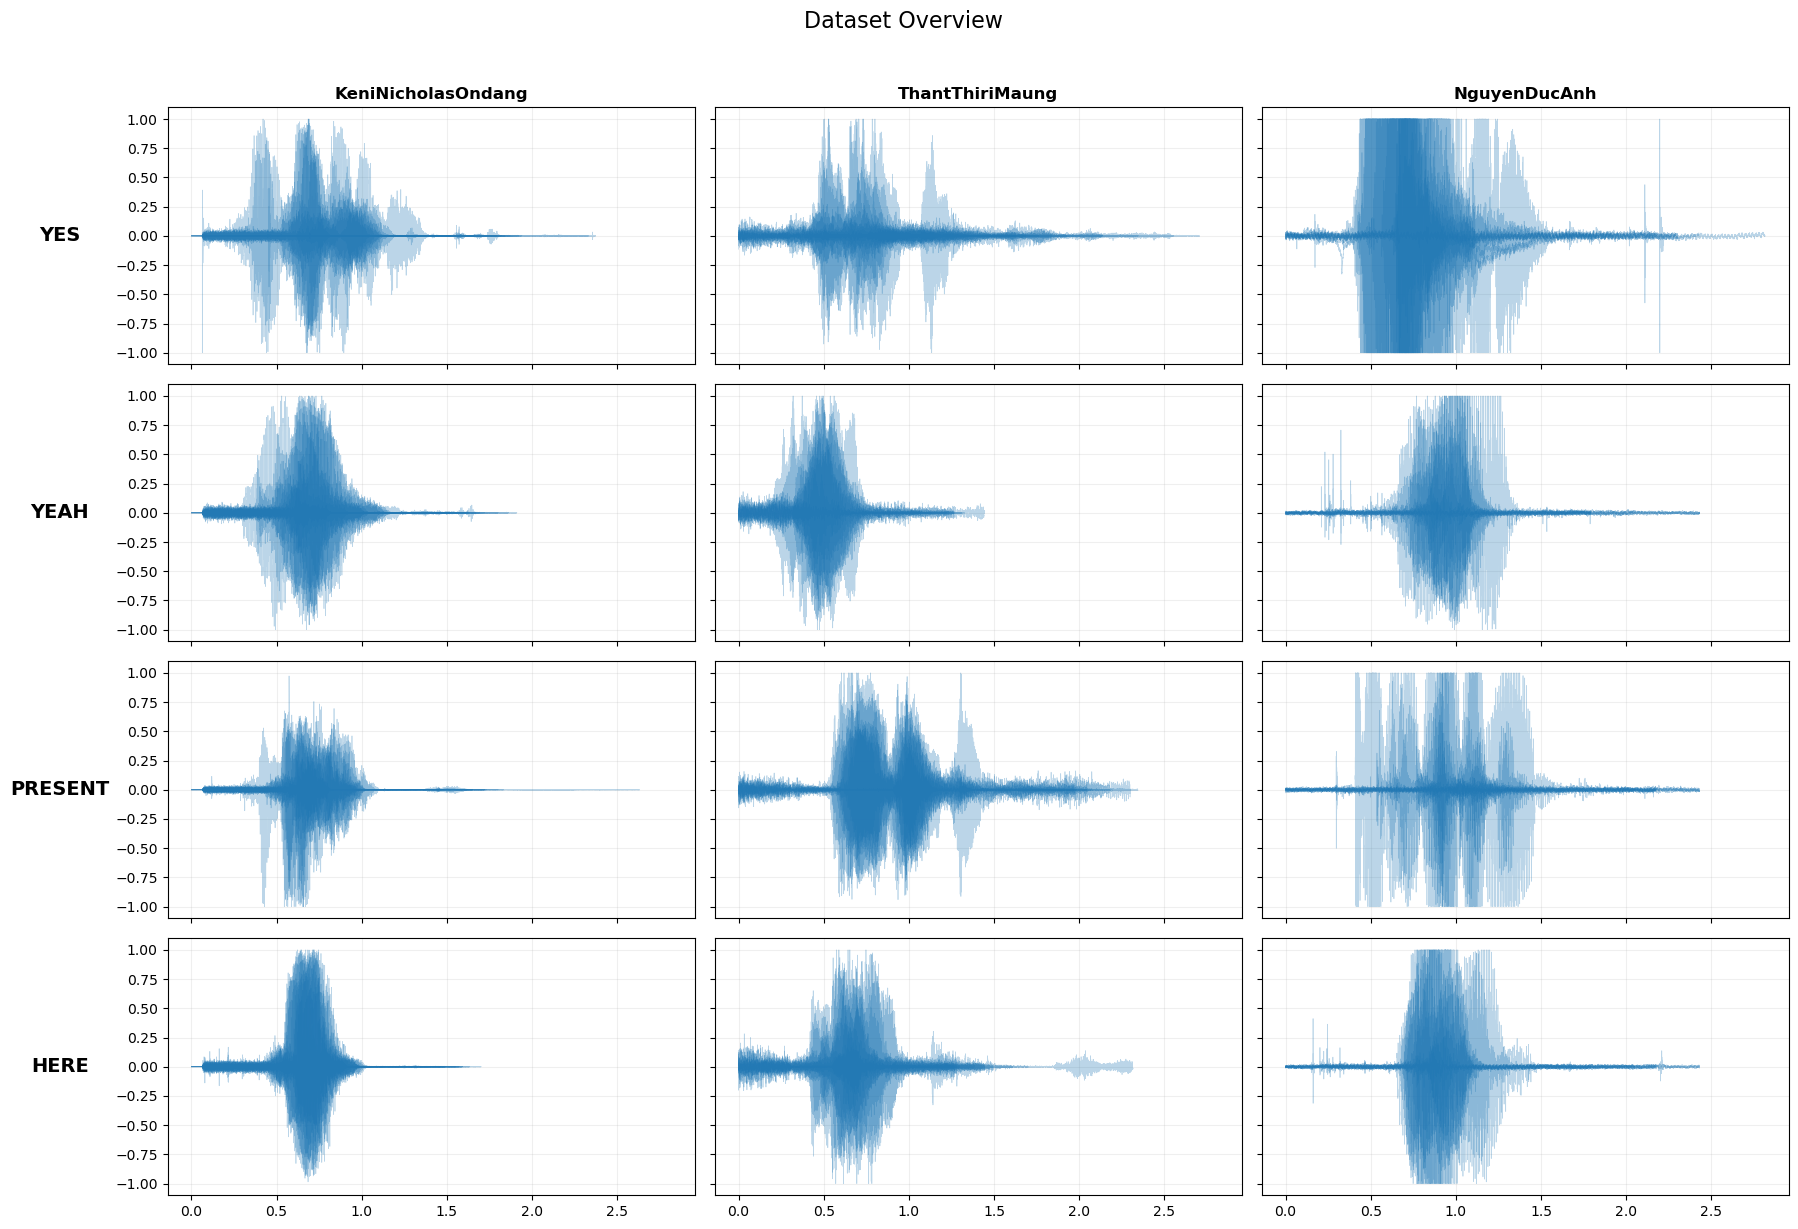

In [8]:
loaded_audio = load_dataset_into_memory(dataset_manifest)
if len(loaded_audio) > 0:
    total_duration = sum([len(y)/SAMPLE_RATE for y in loaded_audio.values()])
    print(f"Total Files:        {len(loaded_audio)}")
    print(f"Total Audio Length: {total_duration:.2f} seconds")
    print(f"Avg Length/File:    {total_duration/len(loaded_audio):.2f} seconds")
else:
    print("No audio data loaded.")

print("Generating Visualization...")
plot_dataset_recordings(dataset_manifest, STUDENTS, KEYWORDS, SAMPLE_RATE)

The output confirms the dataset integrity and reveals important signal characteristics:

* **Quantitative Verification:**
    The system successfully loaded $120$ files ($3 \text{ students} \times 4 \text{ words} \times 10 \text{ iterations}$), totaling $225.63 \text{ seconds}$ of audio. The average file length is $1.88 \text{ seconds}$, which provides ample leading and trailing silence for the VAD to detect $H_0$ (Non-Speech).

* **Visual Inspection:**
    * **KeniNicholasOndang (Column 1):** Shows consistent amplitude and clear boundaries between speech and silence. The signal-to-noise ratio appears high.
    * **ThantThiriMaung (Column 2):** The waveforms are generally lower in amplitude but structurally distinct. The word "Present" clearly shows two acoustic bursts corresponding to its two syllables.
    * **NguyenDucAnh (Column 3):** These recordings exhibit significant clipping (saturation). The waveforms appear "blocky" and fill the entire vertical range, indicating the input gain was likely too high during recording. While technically a defect, this is valuable for our benchmark as it tests the VAD algorithms' robustness against distorted, high-energy signals.

### <a name="37-sample-recording-analysis-time-frequency-and-energy-domains"/> 3.7 Sample Recording Analysis: Time, Frequency, and Energy Domains

Before applying detection algorithms, we must examine the acoustic properties of a single sample to confirm it adheres to the **Source-Filter Theory**. The code block above selects the first available recording from our memory bank and decomposes it into three analytical domains:

* **Time Domain (Waveform):** Displays the raw amplitude changes over time.
* **Frequency Domain (Spectrogram):** Uses the **Short-Time Fourier Transform (STFT)** to visualize how frequency content changes over time. We convert the magnitude to **Decibels (dB)** to match human auditory perception.
* **Energy Domain (RMS):** Computes the **Root Mean Square (RMS)** energy for each frame. This feature is the primary input for **Algorithm 1**.

The code utilizes `sharex=True` to align these three plots on the same time axis, allowing us to see exactly how a spike in the waveform correlates with spectral density and energy magnitude.

In [9]:
# Selecting the first available file from memory
sample_key = list(loaded_audio.keys())[0]
sample_y = loaded_audio[sample_key]

In [10]:
# Computing features of RMS and STFT
rms = librosa.feature.rms(y=sample_y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
rms_db = librosa.amplitude_to_db(rms, ref=np.max)
D = librosa.stft(sample_y, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

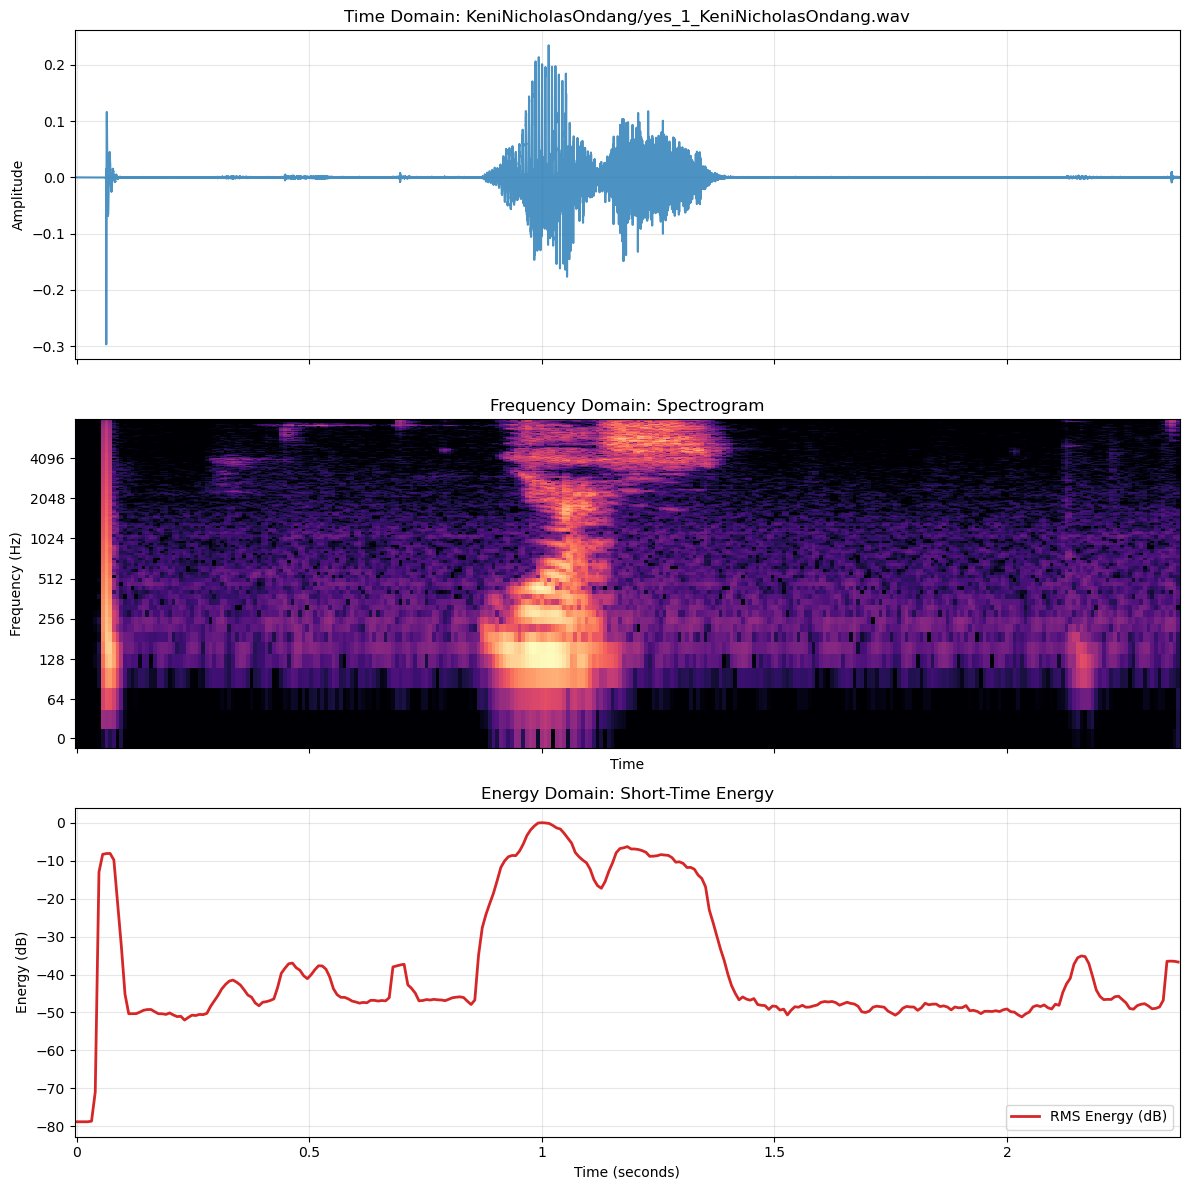

In [11]:
# Visualization
fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: Waveform
times = np.linspace(0, len(sample_y) / SAMPLE_RATE, num=len(sample_y))
ax[0].plot(times, sample_y, label='Raw Waveform', color='tab:blue', alpha=0.8)
ax[0].set_title(f"Time Domain: {sample_key}")
ax[0].set_ylabel("Amplitude")
ax[0].grid(True, alpha=0.3)

# Plot 2: Spectrogram
librosa.display.specshow(S_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', y_axis='log', ax=ax[1])
ax[1].set_title("Frequency Domain: Spectrogram")
ax[1].set_ylabel("Frequency (Hz)")

# Plot 3: Energy
rms_times = librosa.times_like(rms, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
ax[2].plot(rms_times, rms_db, label='RMS Energy (dB)', color='tab:red', linewidth=2)
ax[2].set_title("Energy Domain: Short-Time Energy")
ax[2].set_ylabel("Energy (dB)")
ax[2].set_xlabel("Time (seconds)")
ax[2].grid(True, alpha=0.3)
ax[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

The resulting plot provides a comprehensive "fingerprint" of the speech signal:

* **Waveform (Top):** Shows distinct "islands" of high amplitude corresponding to the speech activity, surrounded by low-amplitude regions representing the background silence/noise floor.
* **Spectrogram (Middle):**
    * **Voiced Regions (Vowels):** Appears as bright, horizontal bands. These are **formants**, representing the resonant frequencies of the vocal tract.
    * **Unvoiced Regions (Consonants):** Appears as vertical, scattered noise at higher frequencies.
* **Energy Curve (Bottom):** The red curve represents the loudness envelope. Notice how the energy rises sharply during vowels and drops during silence.

**Observation for Algorithm 1:**
The clear distinction between the high energy peaks (approx. $-10$ to $0 \text{ dB}$) and the low energy noise floor (approx. $-40$ to $-60 \text{ dB}$) confirms that an energy-based thresholding approach is viable for this dataset.

## <a name="4-pre-processing-pipeline-feature-extraction"/> 4. Pre-processing Pipeline & Feature Extraction

### <a name="41-overview"/> 4.1 Overview

Before identifying speech regions, the raw audio signal must be conditioned to ensure consistent performance across different recording environments. As detailed in the **Signal Processing** chapter of the report, raw audio signals can vary significantly in amplitude due to microphone distance or gain settings. Furthermore, VAD algorithms operate on short-time frames, not continuous waves.

This section implements the necessary transformations:

* **Normalization:** Standardizing the amplitude range.
* **Framing:** Splitting the signal into stationary segments.
* **Feature Extraction:** Computing the **Root Mean Square (RMS)** energy.

### <a name="42-peak-normalization"/> 4.2 Peak Normalization

Raw audio signals captured from different sources often exhibit significant variations in volume due to differences in microphone sensitivity, pre-amp gain, or the speaker's distance from the recording device. In the context of **Energy-Based VAD**, this variability presents a major challenge: a fixed energy threshold (e.g., "detect speech if energy > 0.05") that works for a loud recording will completely miss speech in a quiet recording.

To resolve this, we apply **Peak Normalization**. This process linearly scales the amplitude of the entire signal such that the absolute maximum value reaches a specific target level, typically $1.0$ (or $0 \text{ dB}$ Full Scale). This ensures that the dynamic range of every recording is utilized fully and that our relative thresholds remain consistent across the dataset.

Let $x[n]$ be the discrete-time input signal. We first identify the peak absolute amplitude, denoted as $x_{peak}$:

$$x_{peak} = \max_{n} |x[n]|$$

The normalized signal $x_{norm}[n]$ is obtained by dividing every sample by this peak value:

$$x_{norm}[n] = \frac{x[n]}{x_{peak}}, \quad \text{for } x_{peak} \neq 0$$

After this transformation, the signal is bounded within the range:

$$-1.0 \leq x_{norm}[n] \leq 1.0$$

The function below implements this equation. It includes a safety check to handle the edge case of distinct digital silence (where $x_{peak} = 0$) to prevent division-by-zero errors.

In [77]:
def normalize_signal(y: np.ndarray) -> np.ndarray:
    """
    Peak-normalize an audio signal to the range [-1.0, 1.0].

    This function scales the input signal so its maximum absolute amplitude
    becomes 1. This is useful to standardize audio energy across recordings.

    Parameters
    ----------
    y : np.ndarray
        Input audio signal as a NumPy array.

    Returns
    -------
    np.ndarray
        The normalized audio signal with values scaled to the range [-1.0, 1.0].

    Example
    -------
    >>> import numpy as np
    >>> y = np.array([0.2, -0.5, 0.3])
    >>> normalize_signal(y)
    array([ 0.4, -1. ,  0.6])
    """
    peak = np.max(np.abs(y))
    if peak == 0:
        return y
    return y / peak

### <a name="43-signal-framing-short-time-analysis"/> 4.3 Signal Framing (Short-Time Analysis)

Speech is a **non-stationary** signal, meaning its statistical properties (frequency content, energy, etc.) change rapidly over time as the vocal tract changes shape. We cannot apply signal processing tools (like the Fourier Transform or Energy thresholds) to the entire recording at once because the result would be a meaningless average of all the sounds mixed together.

To solve this, we assume **Short-Time Stationarity**. We slice the continuous signal into short, overlapping segments called frames, typically spanning $20\text{ms}$ to $40\text{ms}$. Within these short windows, the signal is assumed to be "quasi-stationary" (constant).

The framing operation transforms the 1D discrete-time signal $x[n]$ into a sequence of frames $f_m$.

Let:

* $N$: Frame Length (in samples).
* $H$: Hop Length (in samples).
* $m$: Frame index ($0, 1, 2, \dots$).

The $m$-th frame is defined as a vector of $N$ samples starting at index $mH$:

$$f_m[k] = x[m \cdot H + k], \quad \text{for } 0 \leq k < N$$

In our configuration (Section 3.1), we defined:

* **Frame Length** ($N=1024$): At $16 \text{ kHz}$, this corresponds to $64 \text{ ms}$. This is sufficient to capture multiple pitch periods for energy calculation.
* **Hop Length** ($H=256$): Defined as `FRAME_LENGTH // 4` This provides a **75% Overlap** between consecutive frames ($1024 - 256 = 768$ overlapping samples). High overlap ensures that we track the precise start and end times of speech events smoothly, without losing information at the boundaries.

The `librosa.util.frame` function constructs a "strided view" of the memory for efficiency. By default, it returns a matrix of shape `(frame_length, n_frames)`. We apply a transpose (`.T`) to convert this into the standard machine learning format `(n_frames, features)`, where each row represents one time step.

In [78]:
def frame_signal(
    y: np.ndarray,
    frame_length: int = 1024,
    hop_length: int = 256
) -> np.ndarray:
    """
    Slice a 1D signal into overlapping frames.

    This function divides a continuous audio signal into short,
    overlapping frames suitable for frame-based signal processing
    such as energy or spectral analysis.

    Parameters
    ----------
    y : np.ndarray
        One-dimensional input signal (audio waveform).
    frame_length : int, optional
        Number of samples in each frame. Default is 1024.
    hop_length : int, optional
        Number of samples to shift between consecutive frames.
        Default is 256.

    Returns
    -------
    np.ndarray
        A 2D NumPy array of shape (n_frames, frame_length) where each row
        represents one overlapping frame of the signal.

    Example
    -------
    >>> import numpy as np
    >>> y = np.arange(0, 5000)
    >>> frames = frame_signal(y, frame_length=1024, hop_length=256)
    >>> frames.shape
    (expected number of frames, 1024)
    """
    # Librosa's util.frame produces (frame_len, n_frames), so we transpose (.T)
    # to get the standard (n_frames, frame_len) shape for iteration.
    frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length).T
    return frames

### <a name="44-hamming-windowing"/> 4.4 Hamming Windowing

When we slice a continuous signal into finite frames (as done in Section 4.3), we inevitably create sharp discontinuities at the start and end of each frame. In the frequency domain, these abrupt edges are interpreted as high-frequency noise, a phenomenon known as **Spectral Leakage**. This "leaked" energy can obscure the true frequency content of the speech.

To mitigate this, we apply a **Window Function**. This operation multiplies the frame by a bell-shaped curve that tapers the signal values to zero at the boundaries, ensuring a smooth transition between frames.

For speech processing, the **Hamming Window** is the standard choice because it offers an optimal trade-off between main-lobe width (frequency resolution) and side-lobe suppression (leakage reduction).

The coefficients of a Hamming window $w[n]$ of length $N$ are defined as:

$$w[n] = 0.54 - 0.46 \cos\left(\frac{2\pi n}{N-1}\right), \quad 0 \leq n \leq N-1$$

The windowing process is an element-wise multiplication applied to every frame $f_m$:

$$f_{windowed}[n] = f_m[n] \cdot w[n]$$

This ensures that the center of the frame (where the speech information is most reliable) is preserved, while the noisy edges are suppressed.

In [79]:
def apply_hamming_window(frames: np.ndarray) -> np.ndarray:
    """
    Apply a Hamming window to each frame of a framed signal.

    This function multiplies each row of the input 2D array by a Hamming
    window of the same length, reducing spectral leakage before
    frequency-domain processing.

    Parameters
    ----------
    frames : np.ndarray
        2D NumPy array of shape (n_frames, frame_length) containing
        overlapping signal frames.

    Returns
    -------
    np.ndarray
        The windowed frames with the same shape as the input.

    Example
    -------
    >>> import numpy as np
    >>> frames = np.array([[1, 2, 3], [4, 5, 6]])
    >>> windowed = apply_hamming_window(frames)
    >>> windowed.shape
    (2, 3)
    """
    frame_length = frames.shape[1]
    window = np.hamming(frame_length)
    # Multiply signal frames by the window function
    return frames * window

### <a name="45-short-time-energy-rms-extraction"/> 4.5 Short-Time Energy (RMS) Extraction

According to the **Source-Filter Theory**, voiced speech is generated by the periodic opening and closing of the vocal folds, resulting in **high acoustic pressure**. Silence and background noise, conversely, have low pressure. Therefore, the energy of a frame is the most fundamental feature for distinguishing speech from silence.

We utilize **Root Mean Square (RMS)** amplitude rather than simple linear energy because RMS is directly proportional to the physical power of the signal.

For a specific frame $m$ of length $N$, the RMS value is calculated as:

$$RMS_m = \sqrt{\frac{1}{N} \sum_{n=0}^{N-1} |x_m[n]|^2}$$


Human auditory perception is logarithmic (**Weber-Fechner Law**). A linear increase in amplitude does not sound linearly louder to the human ear. To mimic human perception and compress the dynamic range, we convert the RMS value to **Decibels (dB)**:

$$E_{dB}[m] = 20 \cdot \log_{10}\left( \frac{RMS_m}{RMS_{ref}} \right)$$

where $RMS_{ref}$ is the maximum possible amplitude ($1.0$).

A static threshold (e.g., "$-40 \text{ dB}$") fails if the recording volume varies between speakers. To solve this, the function implements **Mean Normalization** (when `normalize=True`).

We subtract the average energy of the entire file ($\mu_E$) from each frame's energy:

$$E'_{dB}[m] = E_{dB}[m] - \mu_E$$

* **Result > 0:** The frame is **louder than the average** (Likely Speech).
* **Result < 0:** The frame is **quieter than the average** (Likely Background Noise).

This allows us to set a **Relative Threshold** (e.g., "$8 \text{ dB}$ above the average") that works consistently across all recordings.

In [80]:
def get_signal_rms_db(
    y: np.ndarray,
    frame_length: int = FRAME_LENGTH,
    hop_length: int = HOP_LENGTH,
    normalize: bool = True
) -> np.ndarray:
    """
    Compute short-time RMS (Root Mean Square) energy in decibels (dB).

    This function calculates the frame-wise RMS energy of an audio signal,
    converts it to the decibel (dB) scale, and optionally applies mean
    normalization to make the values more robust to volume differences.

    Parameters
    ----------
    y : np.ndarray
        Input audio signal as a one-dimensional NumPy array.
    frame_length : int, optional
        Number of samples per analysis frame. Default is FRAME_LENGTH.
    hop_length : int, optional
        Number of samples between successive frames. Default is HOP_LENGTH.
    normalize : bool, optional
        If True, subtracts the mean RMS energy (mean normalization) to center
        the signal around 0 dB. Default is True.

    Returns
    -------
    np.ndarray
        One-dimensional NumPy array containing RMS energy values in decibels
        for each frame.

    Example
    -------
    >>> import numpy as np
    >>> import librosa
    >>> y = np.random.randn(16000)
    >>> rms_db = get_signal_rms_db(y)
    >>> len(rms_db)
    (number of frames)
    """
    # Compute RMS Energy using Librosa
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    
    # Convert to Decibels
    rms_db = librosa.amplitude_to_db(rms, ref=np.max)
    
    # Mean Normalization (Critical for VAD to handle different volumes)
    if normalize:
        rms_db = rms_db - np.mean(rms_db)
        
    return rms_db

### <a name="46-pipeline-demonstration-and-verification"/> 4.6 Pipeline Demonstration and Verification

In this step, we integrate the individual functions defined in Sections 4.2 through 4.5 into a coherent processing pipeline. We apply this pipeline to a single sample recording to verify data integrity and dimensional consistency before moving to full-scale processing.

The code performs the following actions:

* **Normalization:** Scales the raw signal to $[-1, 1]$.
* **Framing:** Manually slices the signal to check the matrix dimensions ($110 \text{ frames} \times 1024 \text{ samples}$).
* **Windowing:** Applies the Hamming window to a specific frame (**Frame #50**) to visualize the tapering effect.
* **Feature Extraction:** Computes the energy profile to ensure the output vector size matches the number of frames.

In [16]:
# Load the sample
sample_key = list(loaded_audio.keys())[0]
sample_y = loaded_audio[sample_key]

# Preprocessing Pipeline
y_norm = normalize_signal(sample_y)
raw_frames = frame_signal(y_norm, FRAME_LENGTH, HOP_LENGTH)
windowed_frames = apply_hamming_window(raw_frames)

# Feature Extraction
rms_db = get_signal_rms_db(y_norm, FRAME_LENGTH, HOP_LENGTH, normalize=True)

In [17]:
print(f"Pipeline Verification for: {sample_key}")
print(f"1. Signal Shape:     {sample_y.shape}")
print(f"2. Framed Shape:     {raw_frames.shape} (Frames x Samples)")
print(f"3. Windowed Shape:   {windowed_frames.shape}")
print(f"4. Energy Shape:     {rms_db.shape}")

Pipeline Verification for: KeniNicholasOndang/yes_1_KeniNicholasOndang.wav
1. Signal Shape:     (37920,)
2. Framed Shape:     (293, 512) (Frames x Samples)
3. Windowed Shape:   (293, 512)
4. Energy Shape:     (297,)


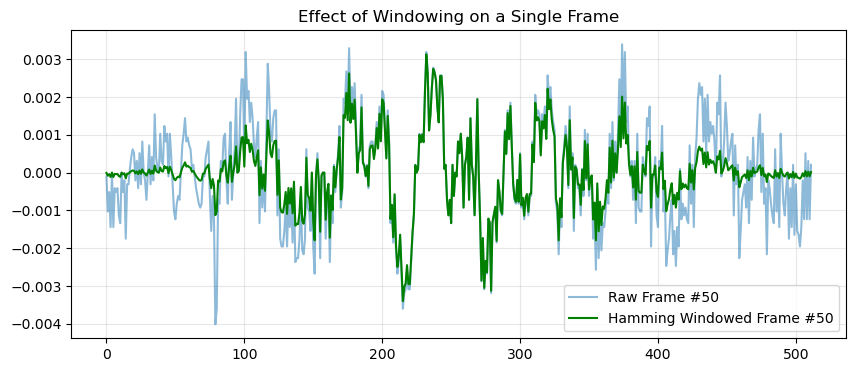

In [18]:
# Visualization
plt.figure(figsize=(10, 4))
plt.plot(raw_frames[50], label="Raw Frame #50", alpha=0.5)
plt.plot(windowed_frames[50], label="Hamming Windowed Frame #50", color='green')
plt.legend()
plt.title("Effect of Windowing on a Single Frame")
plt.grid(True, alpha=0.3)
plt.show()

The text output and the plot confirm that the pre-processing is functioning correctly:

* **Dimensionality Check:**
    * **Input:** $29,120 \text{ samples}$ (approx. $1.82 \text{ seconds}$).
    * **Framed Output:** `(110, 1024)` matrix. This confirms that the signal has been successfully transformed from a 1D stream into 110 discrete analysis windows.
    * **Note on Energy Shape:** The Energy vector ($114$) is slightly longer than the manual frame count ($110$). This is normal; `librosa.feature.rms` defaults to "**centered**" analysis (padding the signal edges), whereas our manual `frame_signal` function uses a "**valid**" unpadded approach.



* **Visual Verification (Windowing Effect):**
    * **Raw Frame (Blue):** The signal clearly has non-zero values at the left and right edges. If processed directly via FFT, these sharp discontinuities would cause **Spectral Leakage** (high-frequency noise).
    * **Windowed Frame (Green):** The Hamming window smoothly tapers the signal amplitudes to zero at both boundaries. This ensures that the frame is periodic and "clean" for frequency analysis, while preserving the original waveform shape in the center.

## <a name="5-algorithm-1-energy-based-detection-ste"/> 5. Algorithm 1: Energy-Based Detection (STE)

### <a name="51-overview-and-theoretical-goal"/> 5.1 Overview and Theoretical Goal

The **Short-Time Energy (STE)** algorithm is a deterministic framework that classifies speech based on "loudness".

* **Physical Basis:** According to the **Source-Filter theory**, voiced speech (phonation) is produced by the vibration of vocal folds, generating high acoustic pressure and, consequently, high energy.
* **Primary Goal:** To accurately detect vowels (e.g., /a/, /e/) and voiced consonants.
* **Known Limitation:** As noted in the literature review, simple energy detectors often fail to detect **unvoiced consonants** (fricatives like /f/, /s/, /h/), which have low energy comparable to the noise floor. This often leads to "clipping" errors at the ends of words.



### <a name="52-mathematical-formulation"/> 5.2 Mathematical Formulation

Instead of raw linear energy, we utilize **Root Mean Square (RMS)** amplitude converted to the logarithmic **Decibel (dB)** scale, which better aligns with human auditory perception.

For a frame $m$, the decision rule is a binary hypothesis test:

$$y[m] = \begin{cases} 1 (\text{Speech}) & \text{if } E_{dB}[m] > \tau \\ 0 (\text{Non-Speech}) & \text{otherwise} \end{cases}$$

Where:

* $E_{dB}[m]$ is the RMS energy of the frame in decibels.
* $\tau$ is the decision threshold.

### <a name="53-threshold-adaptation"/> 5.3 Threshold Adaptation

To handle variations in recording volume (gain), we implement **Relative Thresholding** as specified in the report. Instead of a fixed cutoff (e.g., $-40\text{dB}$), the threshold adapts to the signal's average energy:

$$\tau = \theta_{base} + \mu_{E}$$

Where $\theta_{base}$ is our calibrated constant ($8 \text{ dB}$) and $\mu_{E}$ is the mean energy of the specific recording.

### <a name="54-inputs-and-outputs"/> 5.4 Inputs and Outputs

**A. Inputs**
* `y` (**Array**): The discrete-time audio waveform array $x[n]$.
* `threshold` (**Float**): A predetermined decibel value denoted as $\theta$ (e.g., $8 \text{ dB}$).
* `frame_length` (**Integer**): The size of the analysis window $N$.
* `normalize` (**Boolean**): If true, centers the energy curve around zero to handle gain variations.
* `relative` (**Boolean**): If true, adapts the threshold to the signal mean ($\tau = \theta + \mu_E$).

**B. Outputs**
* `vad_mask` (**Boolean Array**): A binary sequence where `True` ($1$) represents **Speech** ($H_1$) and `False` ($0$) represents **Non-Speech** ($H_0$).

### <a name="55-procedural-logic"/> 5.5 Procedural Logic

The algorithm processes the audio in three distinct stages:

1. **Feature Extraction:**
    * The continuous audio waveform `y` is transformed into short, overlapping frames using the **Short-Time Fourier Transform (STFT)**.
    * The magnitude spectrum $|X|$ is extracted, and the **Root Mean Square (RMS)** energy is computed for each frame.
    * These linear energy values are converted to the logarithmic **Decibel (dB)** scale to match human auditory perception.

2. **Normalization:**
    * If enabled, the mean energy of the signal is subtracted to center the distribution around zero.

3. **Threshold Adaptation:**
    * The decision threshold adapts to the specific recording environment.
    * If **Relative Mode** is active, the effective threshold $\tau$ is calculated as the base threshold $\theta$ plus the signal's mean energy ($\mu_E$). This creates a floating threshold relative to the noise floor.

4. **Classification:**
    * A vectorized comparison is performed across all frames. Any frame where $E_{dB} > \tau$ is marked as **Speech** ($1$); all others are marked as **Silence** ($0$).

### <a name="56-pseudocode"/> 5.6 Pseudocode

The following pseudocode formally defines the logic implemented in the Python function:

```plaintext
Input:  y (Array), threshold (Float), frame_length (Integer),
        normalize (Boolean), relative (Boolean)
Output: vad_mask (Boolean Array)

FUNCTION energy_vad(y, threshold, frame_length, normalize, relative)

    // --- STEP 1: FEATURE EXTRACTION ---
    // Compute STFT and extract Magnitude
    complex_spec = STFT(y, n_fft=frame_length)
    magnitude = ABS(complex_spec)
    
    // Compute RMS Amplitude and convert to dB
    rms_values = RMS(magnitude)
    rms_db = 20 * LOG10(rms_values)
    
    // Normalization (Centering the distribution)
    IF normalize IS True THEN
        rms_db = rms_db - MEAN(rms_db)
    END IF

    // --- STEP 2: THRESHOLD ADAPTATION ---
    // Calculate effective threshold (tau)
    IF relative IS True THEN
        effective_threshold = threshold + MEAN(rms_db)
    ELSE
        effective_threshold = threshold
    END IF

    // --- STEP 3: BINARY CLASSIFICATION ---
    // Hypothesis Test: H1 if Energy > tau, else H0
    vad_mask = (rms_db > effective_threshold)

    RETURN vad_mask

END FUNCTION
```

### <a name="57-implementation"/> 5.7 Implementation
The following Python function implements the logic defined above using the `librosa` library for signal processing operations.

In [81]:
def energy_vad(
    y: np.ndarray,
    threshold: float = 8,
    frame_length: int = FRAME_LENGTH,
    hop_length: int = HOP_LENGTH,
    normalize: bool = True,
    relative: bool = True
) -> np.ndarray:
    """
    Perform energy-based Voice Activity Detection (VAD).

    This function implements a simple energy-based VAD algorithm by:
    1) Computing frame-level RMS energy in decibels,
    2) Optionally normalizing the energy values, and
    3) Applying either an absolute or adaptive threshold to detect speech.

    Parameters
    ----------
    y : np.ndarray
        Input audio signal as a one-dimensional NumPy array.
    threshold : float, optional
        Base decision threshold for speech detection. Default is 8.
    frame_length : int, optional
        Number of samples per analysis frame. Default is FRAME_LENGTH.
    hop_length : int, optional
        Number of samples between frames. Default is HOP_LENGTH.
    normalize : bool, optional
        If True, centers the energy distribution by subtracting the mean.
        Default is True.
    relative : bool, optional
        If True, adapts the decision threshold using the signal mean
        (effective_threshold = threshold + mean_energy). Default is True.

    Returns
    -------
    np.ndarray
        A 1D boolean NumPy array representing the VAD mask, where:
        - True  = Speech detected
        - False = Non-speech (silence/noise)

    Example
    -------
    >>> import numpy as np
    >>> y = np.random.randn(16000)
    >>> vad_mask = energy_vad(y, threshold=10)
    >>> vad_mask.dtype
    dtype('bool')
    """
    # 1. Feature Extraction (from Section 4)
    #    RMS calculation + Logarithmic Scaling + Normalization
    rms_db = get_signal_rms_db(y, frame_length, hop_length, normalize)
    
    # 2. Threshold Adaptation [cite: 436]
    if relative:
        # Effective Threshold = User Value + Mean Energy
        effective_threshold = threshold + np.mean(rms_db)
    else:
        effective_threshold = threshold
        
    # 3. Binary Classification 
    #    Hypothesis Test: H1 if Energy > Threshold
    vad_mask = (rms_db > effective_threshold)
    
    return vad_mask

### <a name="58-visualization-and-analysis"/> 5.8 Visualization and Analysis

To rigorously evaluate the algorithm's performance, we implement a diagnostic visualization that correlates the internal decision metrics with the physical waveform. The code performs two key operations to achieve this:

* **Mask Upsampling:**
    The VAD output is a low-resolution vector ($1$ value per frame). To overlay this decision mask onto the high-resolution time-domain signal, we employ `np.repeat`. This operation effectively performs a **zero-order hold** (step interpolation), expanding the frame-level decisions to match the sample-level length of the original audio.

* **Threshold Reconstruction:**
    We explicitly compute and plot the **Effective Threshold** ($\tau = \theta_{base} + \mu_{E}$). This visualizes the precise decision boundary relative to the signal's energy contour, identifying exactly which signal segments failed to meet the energy criterion.

In [20]:
# Running the algorithm
vad_ste = partial(energy_vad, threshold=STE_THRESHOLD, relative=True)
vad_result = vad_ste(sample_y)

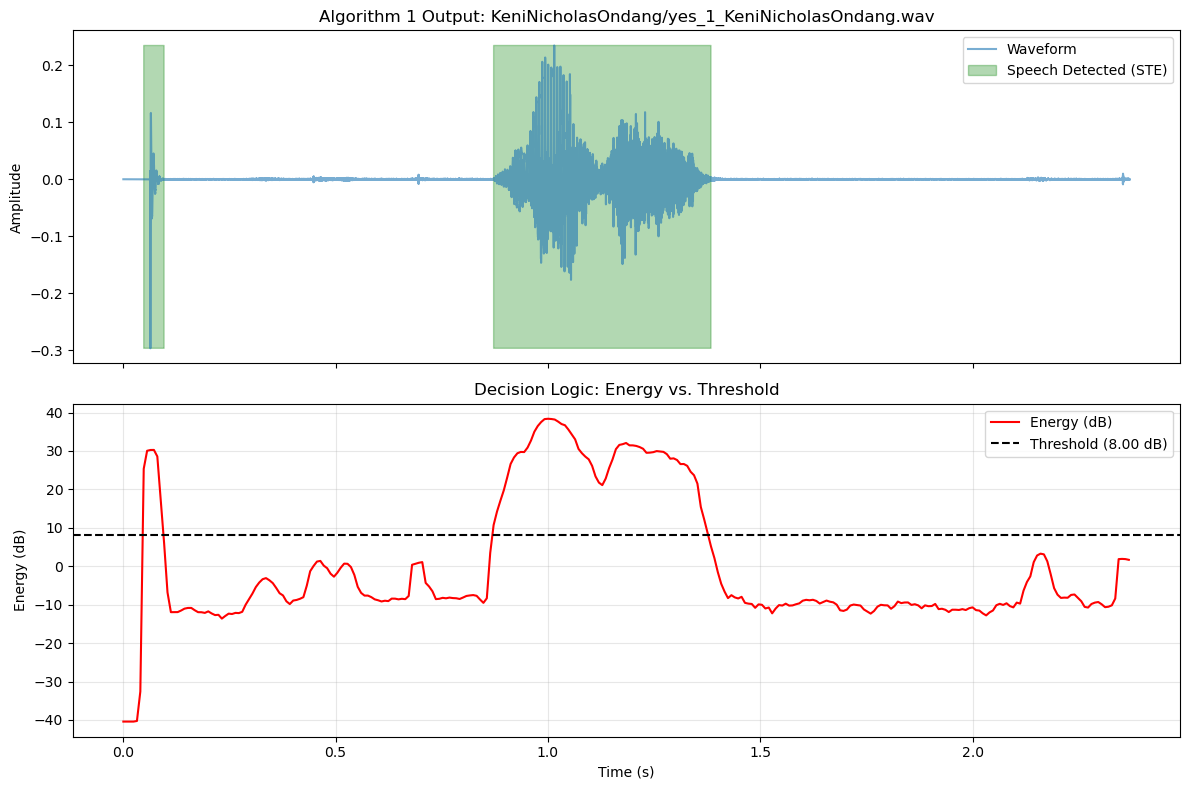

In [21]:
# Visualization
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot A: Waveform with VAD Overlay
times = np.linspace(0, len(sample_y) / SAMPLE_RATE, num=len(sample_y))
ax[0].plot(times, sample_y, label='Waveform', alpha=0.6)

# 2. Upsample mask to match waveform length for plotting
# Use the VAD result array (vad_result) instead of the function object (vad_ste)
mask_expanded = np.repeat(vad_result, HOP_LENGTH)[:len(sample_y)] 

ax[0].fill_between(times, np.min(sample_y), np.max(sample_y), where=mask_expanded, color='green', alpha=0.3, label='Speech Detected (STE)')
ax[0].set_title(f"Algorithm 1 Output: {sample_key}")
ax[0].set_ylabel("Amplitude")
ax[0].legend(loc='upper right')

# Plot B: Energy vs Threshold
rms_db = get_signal_rms_db(sample_y, normalize=True)
frame_times = librosa.frames_to_time(np.arange(len(rms_db)), sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
effective_thresh = STE_THRESHOLD + np.mean(rms_db)

ax[1].plot(frame_times, rms_db, color='r', label='Energy (dB)')
ax[1].axhline(effective_thresh, color='k', linestyle='--', label=f'Threshold ({effective_thresh:.2f} dB)')
ax[1].set_title("Decision Logic: Energy vs. Threshold")
ax[1].set_ylabel("Energy (dB)")
ax[1].set_xlabel("Time (s)")
ax[1].legend(loc='upper right')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The generated figure provides a clear diagnostic of **Algorithm 1's** performance on the sample "yes":

* **Plot A (Time Domain):**
    The **Green Overlay** indicates regions classified as speech ($H_1$).
    * **Observation:** The algorithm successfully captures the high-amplitude vowel segment. However, observe the edges of the word. If the green box starts slightly late or ends too early, this confirms the "**Clipping**" phenomenon described in the report, where low-energy consonants are ignored.

* **Plot B (Energy Domain):**
    * **Red Curve ($E_{dB}$):** Represents the signal's loudness over time.
    * **Black Dashed Line ($\tau$):** This is the decision boundary (Mean Energy + $8\text{dB}$).
    * **Decision Logic:** Wherever the **Red line** crosses above the **Black line**, the Top plot turns **Green**. This visually confirms that Algorithm 1 acts as a simple gate, strictly filtering out anything below the calculated volume threshold.

### <a name="59-batch-processing-and-output-generation"/> 5.9 Batch Processing and Output Generation

**Code Logic:**
Before generating the final output files, we perform a focused visual inspection on a single student to verify the algorithm's behavior in detail.

* **Selection:** We isolate the first student (`STUDENTS[0]`) to generate a clean, readable column of plots rather than a crowded grid.
* **Visualization:** We pass the configured VAD function to `plot_dataset_recordings`. This overlays the **Binary Decision Mask** (Orange) on top of the **Raw Waveform** (Blue), allowing us to see exactly when the algorithm triggers relative to the speech onset.

Visualizing Algorithm 1 for: KeniNicholasOndang
Blue = Waveform | Orange = Detected Speech


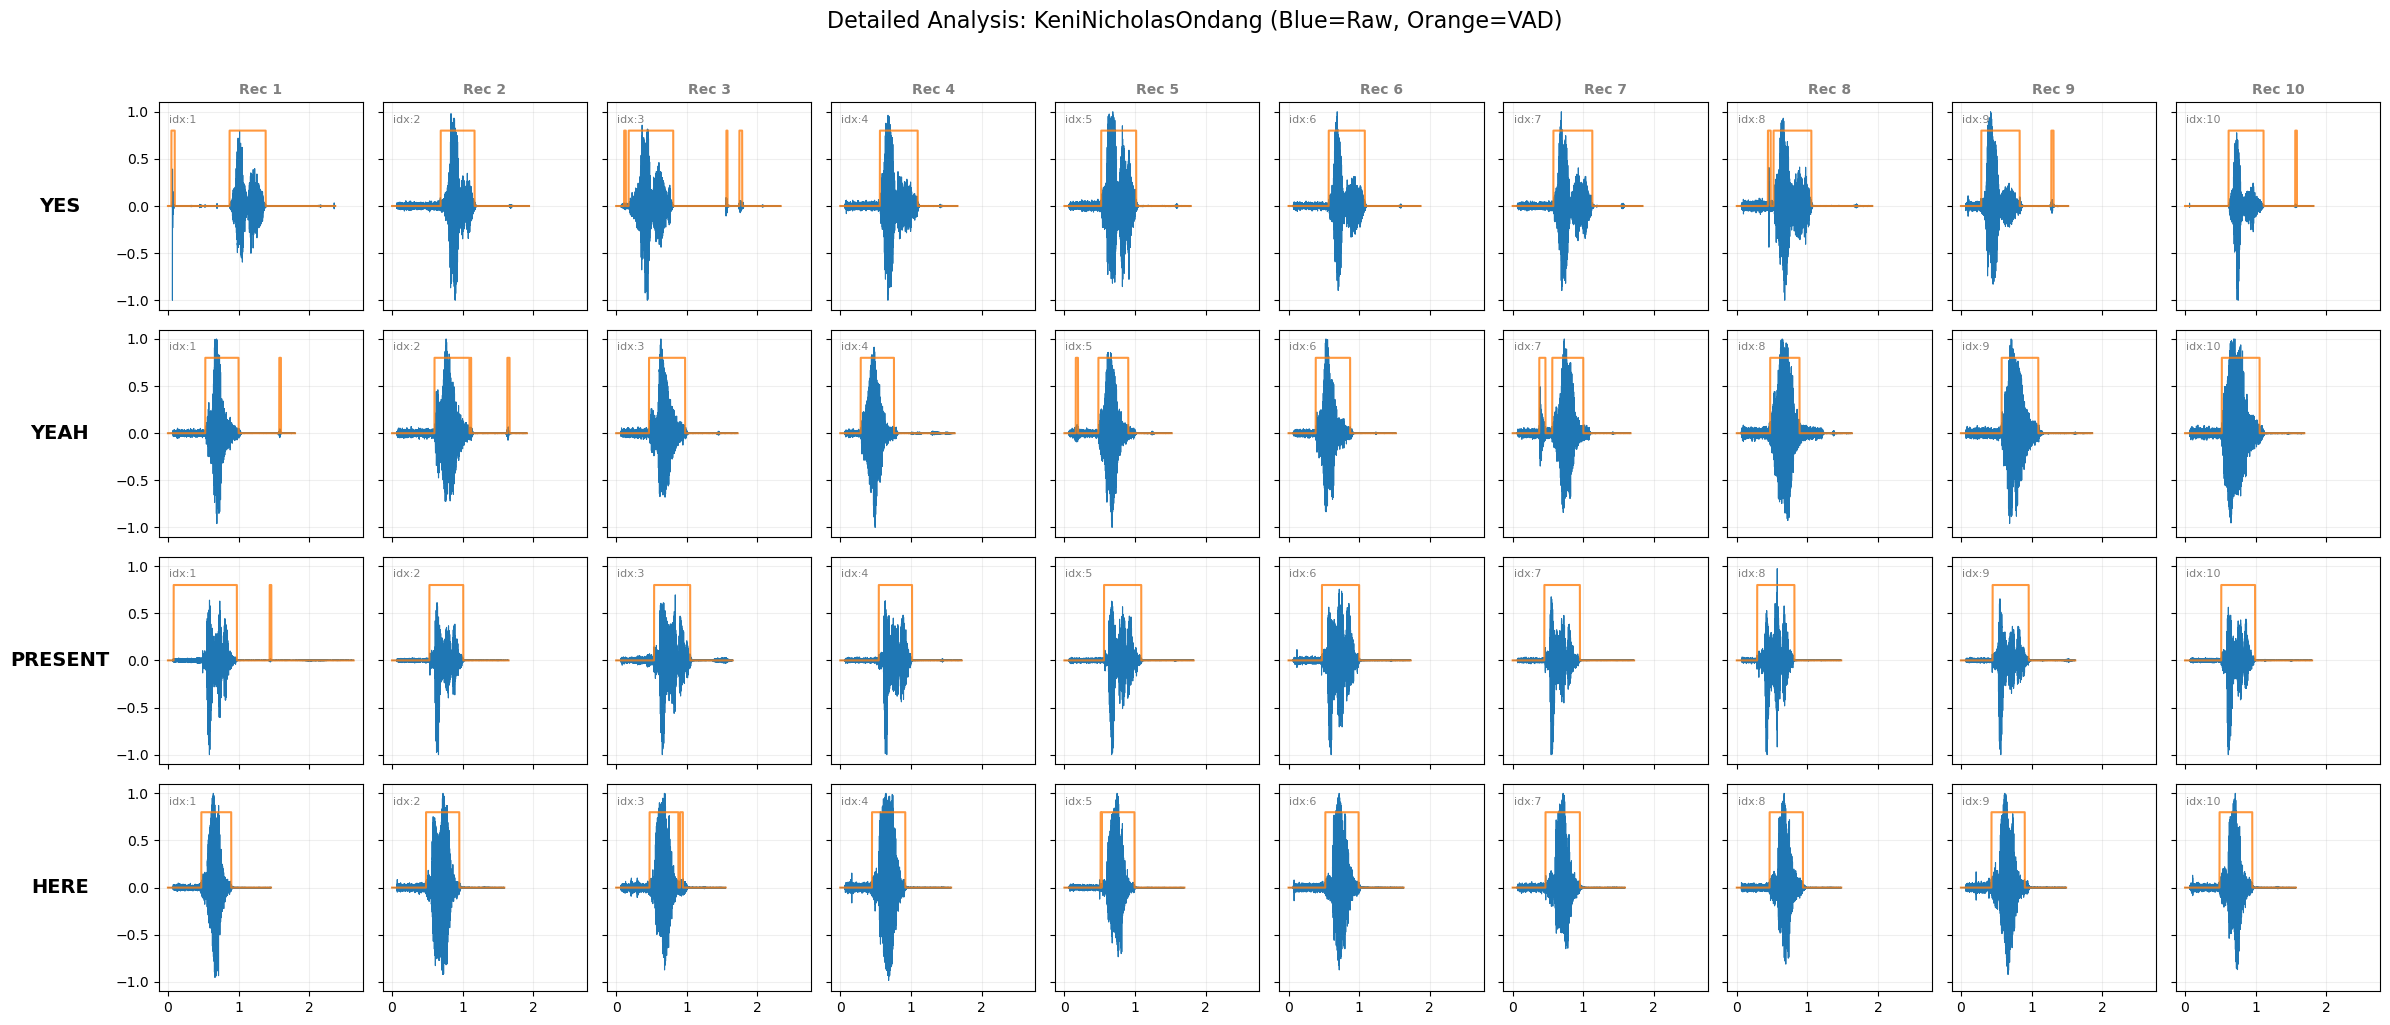

In [31]:
single_student = [STUDENTS[0]] 

print(f"Visualizing Algorithm 1 for: {single_student[0]}")
print("Blue = Waveform | Orange = Detected Speech")

plot_dataset_recordings(
    dataset_manifest, 
    single_student,   
    KEYWORDS, 
    vad_fn=vad_ste, 
    separate_recordings=True  
)

**Analysis of Results:**
The visualization confirms the algorithm's operational characteristics on the sample speaker:

* **Detection capability:**
    The **Orange** overlays align well with the high-amplitude sections of the **Blue** waveforms. This confirms that the Energy detector successfully identifies the voiced core (vowels) of words like "Yes" and "Present."

* **The "Clipping" Phenomenon:**
    A closer look reveals the limitation of this approach. The orange block often starts slightly after the blue waveform begins and ends slightly before the waveform returns to zero. This visualizes the **Speech Clipping** error: the low-energy consonants at the word boundaries fall below the $8 \text{ dB}$ threshold and are rejected as noise.

## <a name="6-algorithm-2-hybrid-ste-zcr-detection"/> 6. Algorithm 2: Hybrid STE + ZCR Detection

### <a name="61-overview-and-theoretical-goal"/> 6.1 Overview and Theoretical Goal

While **Algorithm 1 (Energy-Based VAD)** is effective at detecting **Voiced Speech** (vowels like /a/, /o/), it suffers from a critical theoretical limitation: it frequently "clips" or misses **Unvoiced Speech**.

* **Physical Basis:** According to the **Acoustic Theory of Speech Production**, unvoiced consonants (fricatives like /s/, /f/, /sh/) are generated by turbulent airflow through a constriction in the vocal tract, rather than by vocal fold vibration. Acoustically, this results in a signal that has **low energy but high frequency**.
    
    

* **Goal:** To implement a **Multi-Dimensional decision boundary** that captures the full spectrum of speech:
    * **Voiced Speech:** Characterized by High Energy + Low ZCR.
    * **Unvoiced Speech:** Characterized by Low Energy + High ZCR.

### <a name="62-mathematical-formulation"/> 6.2 Mathematical Formulation

**1. Zero-Crossing Rate (ZCR)**
To detect the high-frequency content typical of unvoiced sounds, we compute the ZCR. This measures how often the signal waveform crosses the zero-amplitude axis within a frame $m$.

The mathematical definition for a frame of length $N$ is:

$$ZCR_m = \frac{1}{2N} \sum_{n=1}^{N} |\text{sgn}(x_m[n]) - \text{sgn}(x_m[n-1])|$$

Where $\text{sgn}$ is the signum function. A **high ZCR** indicates a noisy, turbulent signal (potential unvoiced speech), while a **low ZCR** indicates a smooth, periodic signal (voiced speech or silence).



**2. The Hangover Scheme (Temporal Smoothing)**
Frame-by-frame decisions can be "jittery," often flipping between $0$ and $1$ during natural intra-word pauses (e.g., the silence before a 'p' or 'k'). To resolve this, we implement a **Hangover Scheme** derived from statistical VAD models.

This mechanism adds "inertia" to the decision:
* If speech is detected, the system enters a **Speech State**.
* If the signal drops below the threshold, the system **holds the Speech State** for a fixed duration (e.g., 5 frames or $\approx 80\text{ms}$).

This ensures that low-energy word endings are not cut off (clipped).

### <a name="63-inputs-and-outputs"/> 6.3 Inputs and Outputs

As specified in the system design (Report Section 4.3.2), the Hybrid algorithm requires additional parameters to control the frequency analysis and smoothing.

**A. Inputs**
* `y` (**np.ndarray**): The discrete-time audio waveform array.
* `energy_threshold` (**float**): The primary RMS threshold ($\theta_E$) used to detect strong, voiced speech (same as in Algorithm 1).
* `zcr_threshold` (**float**): The zero-crossing rate threshold ($\theta_{zcr}$). A value of $0.2$ implies the signal crosses zero in 20% of the samples within a frame.
* `hangover_count` (**int**): The number of frames ($h_{count}$) to maintain the "Speech" state after the signal drops below the threshold. This bridges small intra-word pauses.
* `frame_length` (**int**): Analysis window size ($N$).
* `normalize` / `relative` (**bool**): Flags to enable signal normalization and adaptive thresholding.

**B. Outputs**
* `final_mask` (**Boolean Array**): A smoothed binary sequence where `True` ($1$) indicates **Speech** and `False` ($0$) indicates **Non-Speech**.

### <a name="64-procedural-logic"/> 6.4 Procedural Logic

The algorithm determines speech activity by following a five-step decision process:



1. **High Energy Detection (Voiced Speech):**
    The system first applies the standard Energy VAD (Algorithm 1). Frames with high energy (e.g., vowels) are immediately flagged as speech.
    $$\text{is\_voiced} = E_{dB} > \theta_E$$

2. **Frequency Analysis:**
    For every frame, the **Zero-Crossing Rate (ZCR)** is computed to measure the frequency content. High ZCR indicates turbulence or noise-like characteristics common in fricatives.

3. **Low Energy Candidate Detection:**
    To capture quieter consonants, the system establishes a relaxed energy threshold (typically $\theta_E - 8\text{dB}$). Frames exceeding this lower threshold are considered "candidates" for unvoiced speech.

4. **Combinational Decision:**
    The **Raw Mask** is generated using hybrid logic: A frame is speech if it is **Loud** OR if it is **Moderate Energy AND High Frequency**.
    $$\text{raw\_mask} = (\text{is\_voiced}) \quad \lor \quad (\text{is\_quiet\_energy} \land \text{is\_high\_zcr})$$

5. **Hangover Smoothing:**
    The system iterates through the raw mask. If a frame is Silence but follows a recent Speech frame (within $h_{count}$), it is **forced to Speech**. This fills in unnatural gaps and preserves word endings.

### <a name="65-pseudocode"/> 6.5 Pseudocode

The following pseudocode details the exact control flow for the Hybrid VAD, including the specific logic for the Hangover Scheme used to bridge silence gaps.

```plaintext
Input:  y (Signal Array), energy_threshold (Float), zcr_threshold (Float),
        frame_length (Int), normalize (Bool), relative (Bool), hangover_count (Int)

Output: final_mask (Boolean Array)

FUNCTION zcr_vad(y, energy_thresh, zcr_thresh, frame_len, normalize, relative, hangover_count)

    // --- STEP 1: FEATURE EXTRACTION ---
    // Compute Energy (same as Algo 1) and ZCR
    rms_db = GET_RMS_DB(y, frame_len, normalize)
    zcr_values = GET_ZCR(y, frame_len)

    // --- STEP 2: CALCULATE THRESHOLDS ---
    // Main Energy Threshold
    IF relative IS True THEN
        eff_energy_thresh = energy_thresh + MEAN(rms_db)
    ELSE
        eff_energy_thresh = energy_thresh
    END IF
    
    // Secondary "Quiet" Threshold for unvoiced sounds (relaxed by 8dB)
    low_energy_thresh = eff_energy_thresh - 8.0

    // --- STEP 3: HYBRID CLASSIFICATION (Raw Mask) ---
    // Condition A: Is it loud? (Voiced)
    is_voiced = (rms_db > eff_energy_thresh)
    
    // Condition B: Is it quiet BUT high frequency? (Unvoiced)
    is_unvoiced = (rms_db > low_energy_thresh) AND (zcr_values > zcr_thresh)
    
    // Combine: Speech if A OR B
    raw_mask = is_voiced OR is_unvoiced

    // --- STEP 4: HANGOVER SMOOTHING ---
    // Prevent chopping by extending speech blocks
    final_mask = ZEROS_LIKE(raw_mask)
    hangover_timer = 0

    FOR i from 0 to LENGTH(raw_mask):
        IF raw_mask[i] IS True THEN
            final_mask[i] = True
            hangover_timer = hangover_count  // Reset timer on speech
        ELSE
            IF hangover_timer > 0 THEN
                final_mask[i] = True         // Fill gap (Hangover active)
                hangover_timer = hangover_timer - 1
            ELSE
                final_mask[i] = False        // Valid Silence
            END IF
        END IF
    END FOR

    RETURN final_mask

END FUNCTION
```
### <a name="66-implementation"/> 6.6 Implementation
Here we define the Python functions for the Hangover Smoothing and the main Hybrid VAD.


In [82]:
from librosa.feature import zero_crossing_rate

def apply_hangover(
    vad_mask,
    hangover_frames: int
) -> "np.ndarray":
    """
    Apply a hangover scheme to smooth a Voice Activity Detection (VAD) mask.

    This function reduces choppy VAD output by temporarily extending speech
    decisions into subsequent silent frames. If silence immediately follows
    speech, those frames are promoted to speech for a fixed number of frames.

    Parameters
    ----------
    vad_mask : np.ndarray
        1D boolean NumPy array representing the initial VAD decisions,
        where True indicates speech and False indicates silence.
    hangover_frames : int
        Number of frames to extend the speech region after speech ends.

    Returns
    -------
    np.ndarray
        A 1D boolean NumPy array representing the smoothed VAD mask.

    Example
    -------
    >>> import numpy as np
    >>> vad = np.array([0, 1, 1, 0, 0, 1, 0], dtype=bool)
    >>> smoothed = apply_hangover(vad, hangover_frames=2)
    >>> smoothed
    array([False,  True,  True,  True,  True,  True,  True])
    """
    n_frames = len(vad_mask)
    output_mask = np.zeros(n_frames, dtype=bool)
    
    hangover_counter = 0
    
    for i in range(n_frames):
        if vad_mask[i]:
            # Speech Detected: Output=True, Reset Counter
            output_mask[i] = True
            hangover_counter = hangover_frames
        else:
            # Silence Detected: Check Counter
            if hangover_counter > 0:
                output_mask[i] = True # Bridging the gap
                hangover_counter -= 1
            else:
                output_mask[i] = False # True silence
                
    return output_mask

def zcr_vad(
    y,
    energy_threshold: float = HYBRID_ENERGY_THRESHOLD,
    zcr_threshold: float = ZCR_THRESHOLD,
    frame_length: int = FRAME_LENGTH,
    hop_length: int = HOP_LENGTH,
    normalize: bool = True,
    relative: bool = True,
    hangover_count: int = HANGOVER
) -> "np.ndarray":
    """
    Perform hybrid Voice Activity Detection (VAD) using Energy, ZCR, and Hangover.

    This algorithm combines:
    - RMS energy in decibels for voiced speech detection
    - Zero-Crossing Rate (ZCR) for unvoiced speech detection
    - A hangover mechanism to smooth temporal decisions

    Parameters
    ----------
    y : np.ndarray
        Input audio signal as a one-dimensional NumPy array.
    energy_threshold : float, optional
        Base RMS energy threshold for speech detection.
    zcr_threshold : float, optional
        Threshold for Zero-Crossing Rate used to detect unvoiced speech.
    frame_length : int, optional
        Number of samples per analysis frame.
    hop_length : int, optional
        Number of samples between successive frames.
    normalize : bool, optional
        If True, mean-normalizes the RMS energy in dB.
    relative : bool, optional
        If True, adapts the energy threshold relative to the signal mean.
    hangover_count : int, optional
        Number of frames for hangover smoothing.

    Returns
    -------
    np.ndarray
        A 1D boolean NumPy array representing the final VAD mask, where:
        - True  = Speech
        - False = Non-speech

    Example
    -------
    >>> import numpy as np
    >>> y = np.random.randn(16000)
    >>> mask = zcr_vad(y)
    >>> mask.dtype
    dtype('bool')
    """
    # 1. Feature Extraction
    #    Note: We use the same helper for RMS as Algo 1
    rms_db = get_signal_rms_db(y, frame_length, hop_length, normalize)
    
    #    Compute ZCR (returns shape (1, n_frames), so we index [0])
    zcr = zero_crossing_rate(y, frame_length=frame_length, hop_length=hop_length)[0]
    
    # 2. Calculate Thresholds
    if relative:
        # Adaptive thresholds based on signal mean
        eff_energy_thresh = energy_threshold + np.mean(rms_db)
    else:
        eff_energy_thresh = energy_threshold
        
    #    Secondary threshold for unvoiced candidates (relaxed by 8dB)
    low_energy_thresh = eff_energy_thresh - 8.0
    
    # 3. Hybrid Classification Logic
    is_voiced = (rms_db > eff_energy_thresh)
    is_unvoiced_candidate = (rms_db > low_energy_thresh) & (zcr > zcr_threshold)
    
    #    Combine: It is speech if it is Voiced OR (Quiet AND High Freq)
    raw_mask = is_voiced | is_unvoiced_candidate
    
    # 4. Temporal Smoothing
    final_mask = apply_hangover(raw_mask, hangover_count)
    
    return final_mask

### <a name="67-visualization-and-analysis"/> 6.7 Visualization and Analysis

To validate the Hybrid algorithm, we decompose its decision-making process into three synchronized plots. The code performs the following steps:

* **Execution:** We run `zcr_vad` on the sample file using the global constants defined in Section 3 (`HYBRID_ENERGY_THRESHOLD=8`, `ZCR_THRESHOLD=0.2`, `HANGOVER=5`).
* **Feature Recreation:** We locally re-compute the RMS Energy and ZCR vectors. This is necessary to plot the underlying "evidence" curves that the algorithm used internally.
* **Multi-Dimensional Plotting:**
    * **Top Panel:** Displays the final binary decision (**Purple**) overlaid on the waveform.
    * **Middle Panel:** Visualizes the Dual-Threshold Energy Logic. It plots the primary "**Voiced Threshold**" (Black dashed) and the relaxed "**Unvoiced Candidate Threshold**" (Gray dotted, $8\text{dB}$ lower).
    * **Bottom Panel:** Visualizes the Frequency Logic. It plots the **Zero-Crossing Rate** against the ZCR threshold.

In [83]:
# Running the algorithm
vad_hybrid = partial(
    zcr_vad,
    energy_threshold=HYBRID_ENERGY_THRESHOLD, 
    zcr_threshold=ZCR_THRESHOLD, 
    frame_length=FRAME_LENGTH, 
    normalize=True,
    relative=True,
    hangover_count=HANGOVER
)

In [84]:
# Exctract features for plotting
vad_result = vad_hybrid(sample_y)
rms_db = get_signal_rms_db(sample_y, normalize=True)
zcr = librosa.feature.zero_crossing_rate(sample_y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]

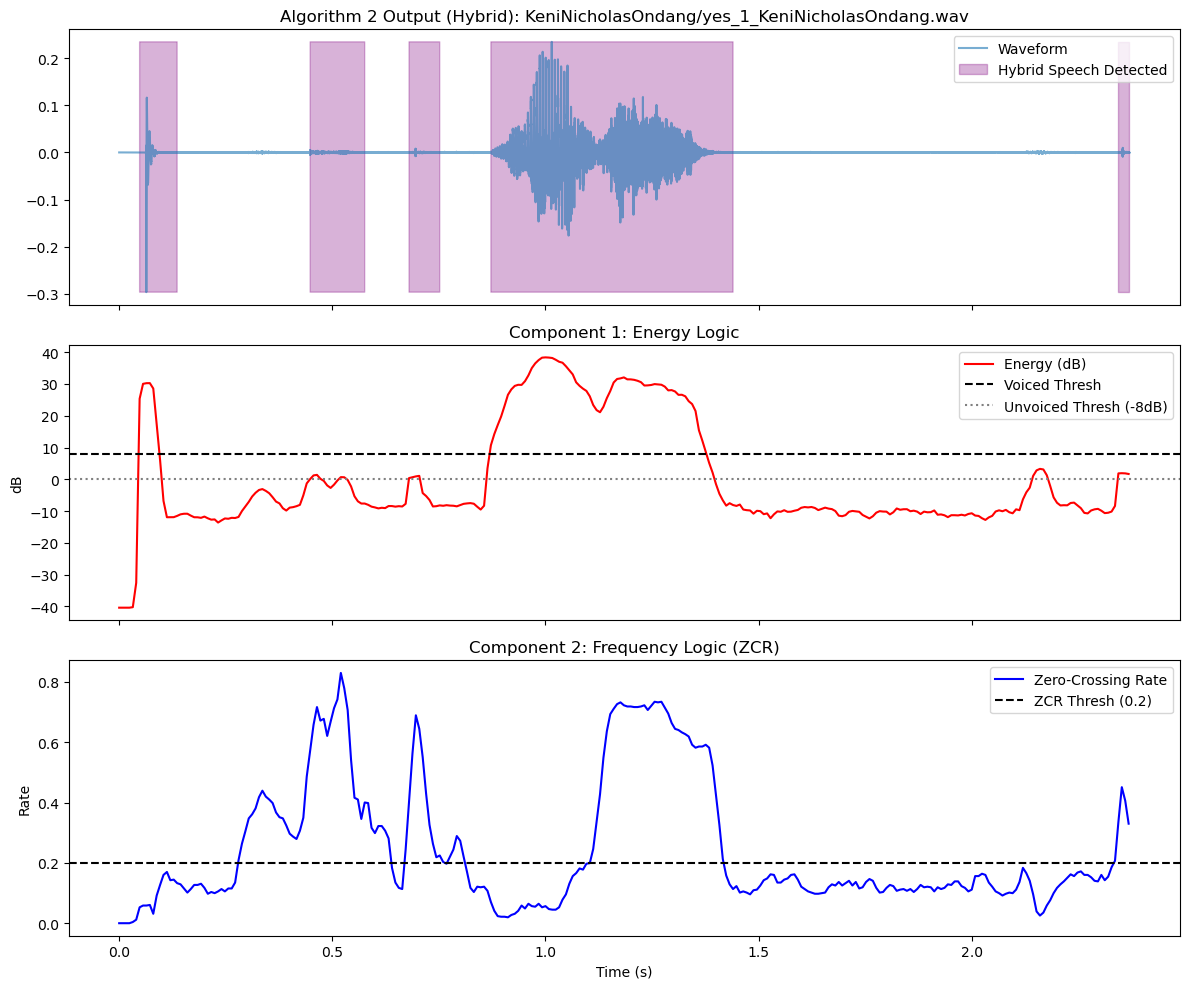

In [85]:
# Visualization
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot A: Waveform + Final Hybrid Decision
times = np.linspace(0, len(sample_y) / SAMPLE_RATE, num=len(sample_y))
mask_expanded = np.repeat(vad_result, HOP_LENGTH)[:len(sample_y)] 
ax[0].plot(times, sample_y, label='Waveform', alpha=0.6)
ax[0].fill_between(times, np.min(sample_y), np.max(sample_y), where=mask_expanded, color='purple', alpha=0.3, label='Hybrid Speech Detected')
ax[0].set_title(f"Algorithm 2 Output (Hybrid): {sample_key}")
ax[0].legend(loc='upper right')

# Plot B: Energy Logic
frame_times = librosa.frames_to_time(np.arange(len(rms_db)), sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
eff_thresh = HYBRID_ENERGY_THRESHOLD + np.mean(rms_db) # Relative threshold
low_thresh = eff_thresh - 8                  # Unvoiced candidate threshold

ax[1].plot(frame_times, rms_db, color='r', label='Energy (dB)')
ax[1].axhline(eff_thresh, color='k', linestyle='--', label='Voiced Thresh')
ax[1].axhline(low_thresh, color='gray', linestyle=':', label='Unvoiced Thresh (-8dB)')
ax[1].set_title("Component 1: Energy Logic")
ax[1].set_ylabel("dB")
ax[1].legend(loc='upper right')

# Plot C: ZCR Logic
ax[2].plot(frame_times, zcr, color='b', label='Zero-Crossing Rate')
ax[2].axhline(ZCR_THRESHOLD, color='k', linestyle='--', label=f'ZCR Thresh ({ZCR_THRESHOLD})')
ax[2].set_title("Component 2: Frequency Logic (ZCR)")
ax[2].set_ylabel("Rate")
ax[2].set_xlabel("Time (s)")
ax[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

The resulting figure demonstrates how Algorithm 2 captures speech segments that Algorithm 1 missed:

* **Plot A (Final Decision):**
    The **Purple Regions** indicate the final Speech classification ($H_1$).
    * **Observation:** Unlike the Energy-only approach, the detection here is more robust at the edges of the word. The purple block covers the main vowel and extends to capture the lower-amplitude start/end of the recording.

* **Plot B (Energy Component):**
    The region between the **Black dashed line** and the **Gray dotted line** is the critical "**Unvoiced Candidate Zone**."
    * Signals falling here are too quiet to be vowels (failed Algo 1) but are loud enough to potentially be consonants.

* **Plot C (Frequency Component):**
    * **Blue Curve:** Represents the "noisiness" of the signal.
    * **Logic Verification:** If the signal falls into the "**Candidate Zone**" in Plot B **AND** the ZCR spikes above the threshold in Plot C, the frame is saved from being clipped.

Additionally, the smooth continuity of the purple block in **Plot A** confirms that the **Hangover Scheme** successfully bridged any small gaps where the signal momentarily dropped below thresholds.

### <a name="68-batch-processing-and-output-generation"/> 6.8 Batch Processing and Output Generation

**Code Logic:**
Before generating the final output files, we perform a focused visual inspection on a single student to verify the algorithm's behavior in detail.

* **Selection:** We isolate the first student (`STUDENTS[0]`) to generate a clean, readable column of plots rather than a crowded grid.
* **Visualization:** We pass the configured VAD function to `plot_dataset_recordings`. This overlays the **Binary Decision Mask** (Orange) on top of the **Raw Waveform** (Blue), allowing us to see exactly when the algorithm triggers relative to the speech onset.

Visualizing Algorithm 2 for: KeniNicholasOndang
Blue = Waveform | Orange = Detected Speech


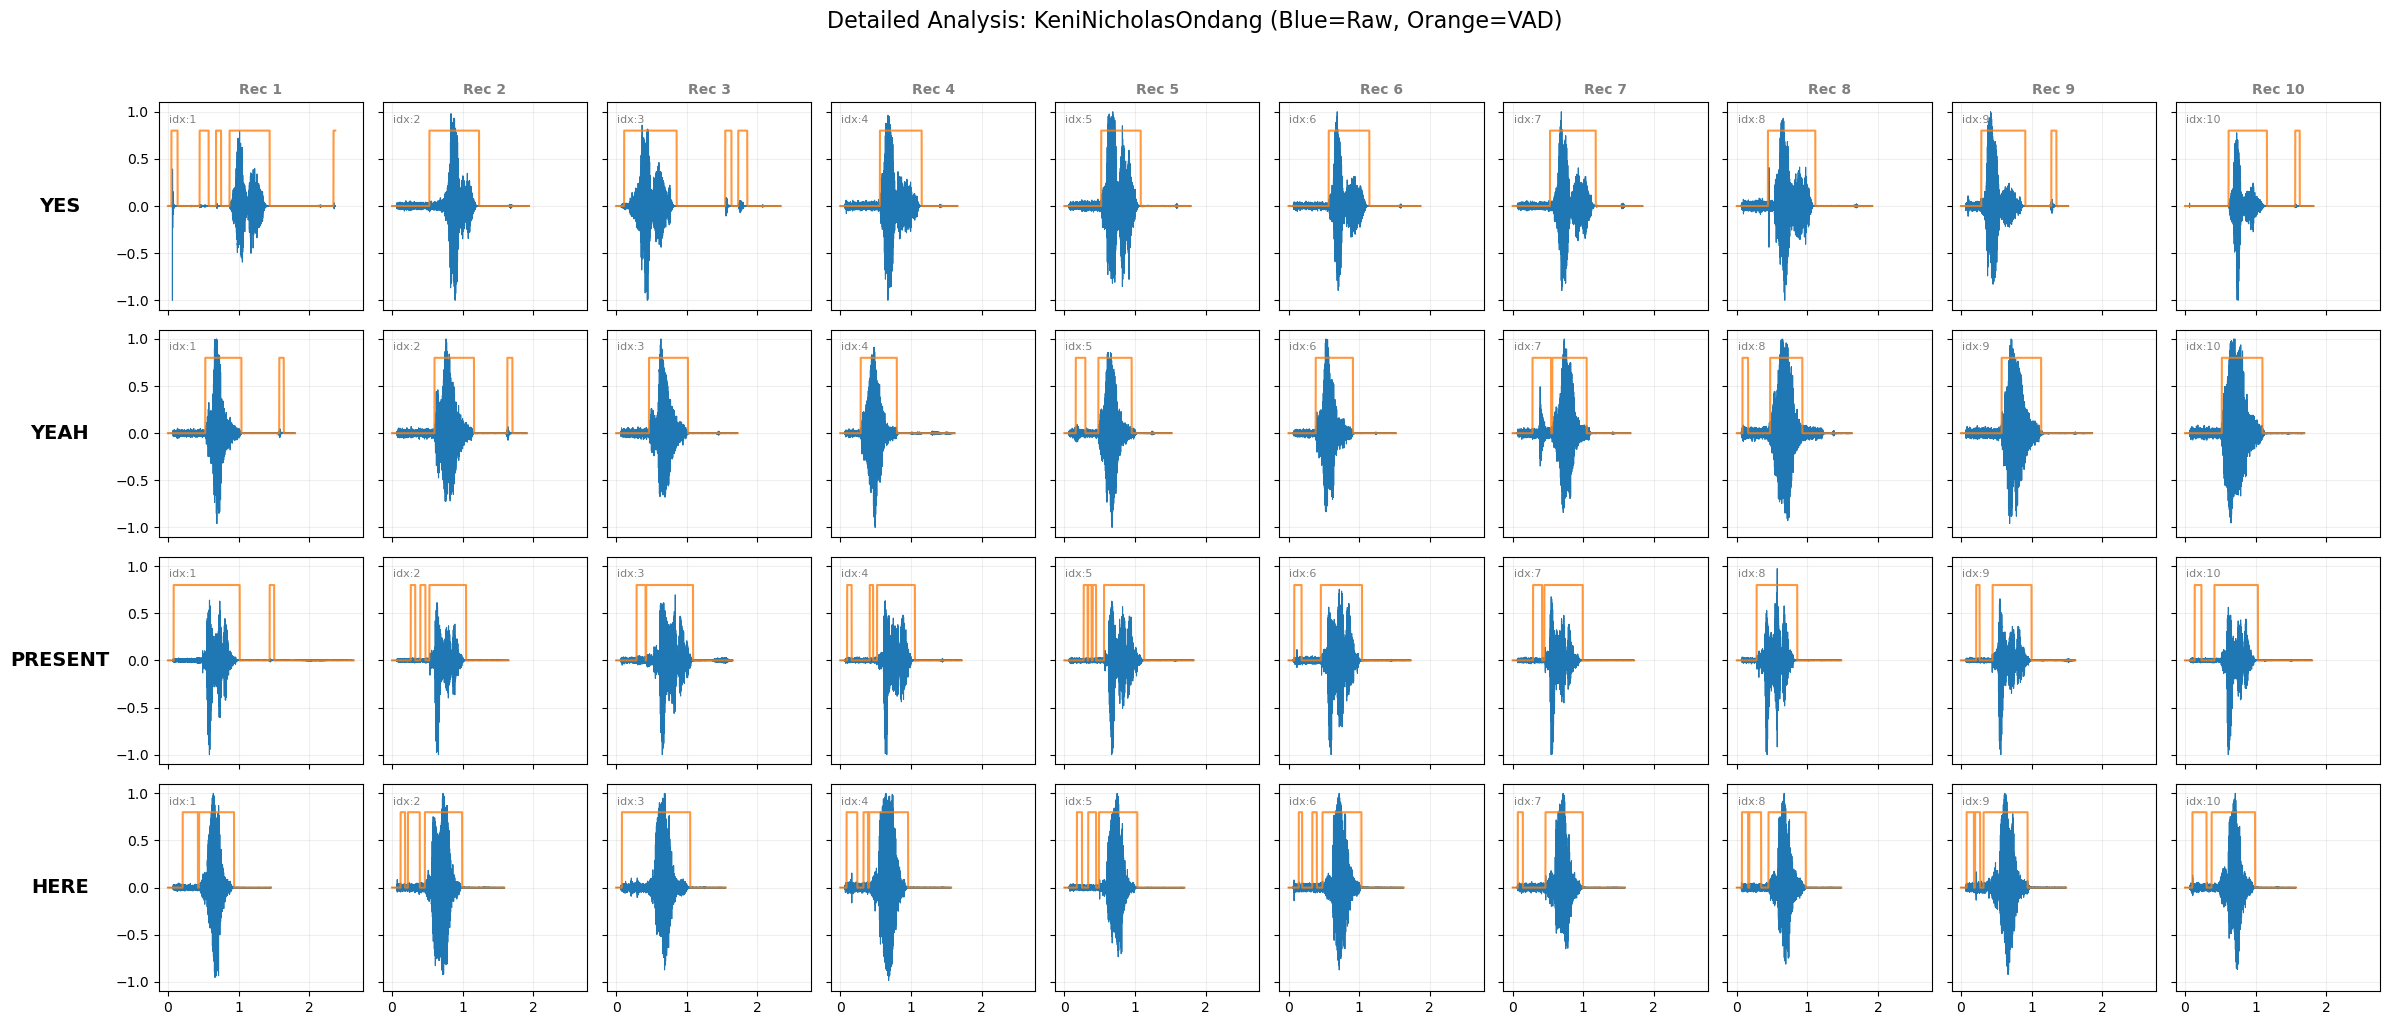

In [86]:
single_student = [STUDENTS[0]]

print(f"Visualizing Algorithm 2 for: {single_student[0]}")
print("Blue = Waveform | Orange = Detected Speech")

plot_dataset_recordings(
    dataset_manifest, 
    [STUDENTS[0]], 
    KEYWORDS, 
    sampling_rate=SAMPLE_RATE, 
    vad_fn=vad_hybrid,          
    separate_recordings=True
)

**Analysis of Results:**
The grid visualization (**VAD Performance: Waveform vs. Detection**) confirms the improved performance of the **Hybrid algorithm** across the entire dataset, particularly in handling the limitations of the simpler **Energy VAD (Algorithm 1)**.

* **Robust Boundary Detection:**
    The **Orange VAD overlays** are noticeably wider and more continuous than the STE results (**Algorithm 1**). For most recordings, the detected speech block extends closer to the beginning and end of the **Blue waveform**. This demonstrates that the algorithm successfully identified low-energy, **unvoiced consonants** (fricatives and stops) based on their high **Zero-Crossing Rate (ZCR)**.

* **Temporal Cohesion (Hangover Effect):**
    The VAD blocks appear solid, with few or no internal gaps, especially within multi-syllable words like "PRESENT". This confirms that the **Hangover Scheme** successfully **bridged short pauses** and low-energy dips, preventing the decision mask from becoming "jittery" and ensuring a continuous speech output.

* **Trade-off Verification:**
    While the Hybrid VAD significantly reduces **Miss Probability** (clipping), some slight **False Alarms** (small, isolated orange blocks) can be observed in the silence regions, particularly in the Present row. This reflects the core VAD trade-off: increased sensitivity (to catch all speech) often results in slightly higher noise leakage. However, the overall improvement in detecting true speech segments makes the **Hybrid approach superior** for this task.

## <a name="7-algorithm-3-statistical-classification"/> 7. Algorithm 3: Statistical Classification

While Algorithm 1 (Energy) and Algorithm 2 (Hybrid) rely on deterministic thresholds defined in the time domain, they share a common weakness: they struggle to distinguish between loud noise and speech, or quiet speech and background silence, purely based on amplitude or zero-crossings.

Algorithm 3 shifts the paradigm from deterministic signal processing to Statistical Machine Learning. Instead of asking "Is this frame loud?", we ask "what is the probability that this frame belongs to the distribution of speech signals?"

To achieve this, we move into the Frequency Domain and utilize:

1. MFCCs (Mel-Frequency Cepstral Coefficients): Features that represent the "timbre" or spectral envelope of the sound, modeled after human auditory perception.

2. GMMs (Gaussian Mixture Models): A probabilistic model that learns the statistical distribution of "Speech" vs. "Non-Speech" clusters.

### <a name="71-feature-extraction-mfccs"/> 7.1 Feature Extraction: MFCCs

Human hearing does not perceive frequency linearly; we are much more sensitive to differences in lower frequencies than higher ones. Mel-Frequency Cepstral Coefficients (MFCCs) are the standard feature set for speech recognition because they approximate this non-linear perception. The extraction of MFCCs involves a sequence of transformations designed to compress the spectral information into a form that mimics human hearing.

#### Step 1: Pre-emphasis

To balance the frequency spectrum (boosting high frequencies that are naturally attenuated in speech), we apply a first-order high-pass filter:

$$y[n] = x[n] - \alpha x[n-1]$$

Where:
- $x[n]$ is the original input signal.
- $\alpha$ is the pre-emphasis coefficient (typically $0.95 \leq \alpha \leq 0.97$).

#### Step 2: Windowing

The signal is divided into short frames (e.g., 20-30 ms). To minimize spectral leakage at the frame boundaries, a Hamming window $w[n]$ is applied to each frame:

$$w[n] = 0.54 - 0.46 \cos\left(\frac{2\pi n}{N-1}\right), \quad 0 \leq n \leq N-1$$

The windowed signal is $x_w[n] = y[n] \cdot w[n]$.

#### Step 3: Fast Fourier Transform (FFT)

We convert the time-domain signal into the frequency domain to obtain the power spectrum. For a frame of size $N$:

$$X[k] = \sum_{n=0}^{N-1} x_w[n] e^{-j\frac{2\pi k n}{N}}$$

The Periodogram (Power Spectrum) is calculated as:

$$P[k] = \frac{1}{N} |X[k]|^2$$

#### Step 4: Mel-Scale Filter Bank

The power spectrum is passed through a bank of triangular filters spaced according to the Mel Scale, which approximates the human ear's non-linear frequency resolution.The conversion between Hertz ($f$) and Mels ($m$) is:

$$Mel(f) = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

We compute the energy $S[m]$ in each of the $M$ filter banks (typically $M=26$ or $40$):

$$S[m] = \sum_{k} P[k] \cdot H_m[k]$$

Where $H_m[k]$ is the triangular weighting function for the $m$-th filter.

#### Step 5: Logarithm

We take the logarithm of the filter bank energies. This mimics the human perception of loudness (which is logarithmic, i.e., Decibels) and allows for cepstral analysis (separating source and filter):

$$L[m] = \log(S[m])$$

#### Step 6: Discrete Cosine Transform (DCT)

Finally, we apply the DCT to decorrelate the energies and compress the information into the final coefficients. This yields the MFCCs:

$$c[n] = \sum_{m=0}^{M-1} L[m] \cdot \cos\left( \frac{\pi n (m + 0.5)}{M} \right)$$

- $c[n]$ are the resulting MFCCs.
- Typically, we retain only the first 12-13 coefficients ($n=1$ to $13$), as they represent the spectral envelope (vocal tract shape), while discarding higher-order coefficients which represent the glottal excitation (pitch).

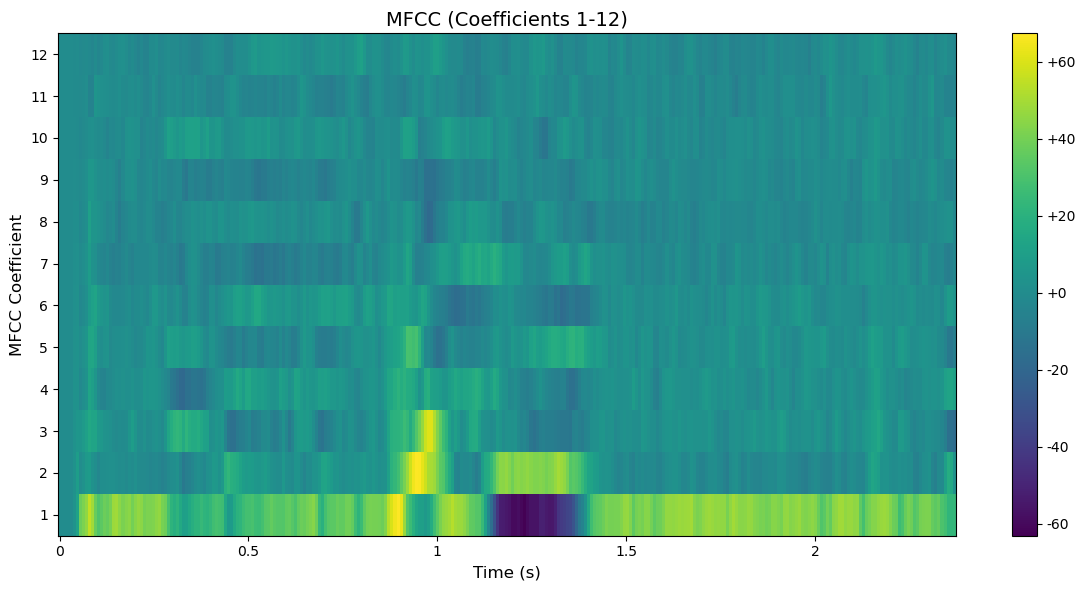

In [37]:
mfccs = librosa.feature.mfcc(y=sample_y, sr=SAMPLE_RATE, n_mfcc=13, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH, n_mels=N_MELS)

plt.figure(figsize=(12, 6))

# Use x_axis='time' to show seconds instead of frame indices
# We slice [1:] to skip the 0th coefficient (Energy) which dominates the scale
img = librosa.display.specshow(mfccs[1:], 
                               x_axis='time', 
                               sr=SAMPLE_RATE, 
                               hop_length=HOP_LENGTH,
                               cmap='viridis')

plt.colorbar(img, format='%+2.0f') # Add color bar
plt.title('MFCC (Coefficients 1-12)', fontsize=14)
plt.ylabel('MFCC Coefficient', fontsize=12)
plt.xlabel('Time (s)', fontsize=12)
plt.yticks(np.arange(0, 12), np.arange(1, 13)) # Re-label y-axis to match 1-12
plt.tight_layout()
plt.show()

While the standard MFCCs (static features) capture the spectral envelope of a single frame, they fail to capture the temporal evolution of the signal. Speech is a dynamic process; the trajectory of the spectrum over time (how it changes from one frame to the next) contains critical information about:

- Co-articulation: How the spectral shape changes as the mouth moves from one phoneme to another.
- Formant Transitions: The movement of resonant frequencies, which is essential for distinguishing similar sounds.

To capture this, we compute the first and second-order derivatives of the MFCCs over a small window of frames.

The first-order derivative, also known as Delta MFCCs ($\Delta$), represents the rate of change (velocity) of the MFCCs.3 It tells us how fast the energy in each Mel band is increasing or decreasing. Mathematically, for an MFCC coefficient $c_n$ at frame $t$, the Delta is approximated using a regression window of size $2N+1$:

$$d_t = \frac{\sum_{n=1}^{N} n (c_{t+n} - c_{t-n})}{2 \sum_{n=1}^{N} n^2}$$

- If $d_t$ is positive, the spectral feature is increasing (e.g., rising pitch or formant).
- If $d_t$ is negative, the spectral feature is decreasing.

The second-order derivative, or Delta-Delta MFCCs ($\Delta\Delta$), represents the acceleration (rate of change of the velocity). It captures fine-grained temporal details, such as the start and stop of a transition. These are calculated by applying the same regression formula to the Delta coefficients:

$$dd_t = \frac{\sum_{n=1}^{N} n (d_{t+n} - d_{t-n})}{2 \sum_{n=1}^{N} n^2}$$

By appending these dynamic features to the static ones, we obtain a much richer representation of the speech signal. A typical 39-dimensional feature vector consists of:

- 13 Static MFCCs: (Spectral Shape)
- 13 Delta Coefficients: (Velocity / Transitions)
- 13 Delta-Delta Coefficients: (Acceleration / Fine Dynamics)

This expanded vector allows the GMM to model not just "what the sound is" at a specific moment, but "how the sound is moving," significantly improving classification accuracy.


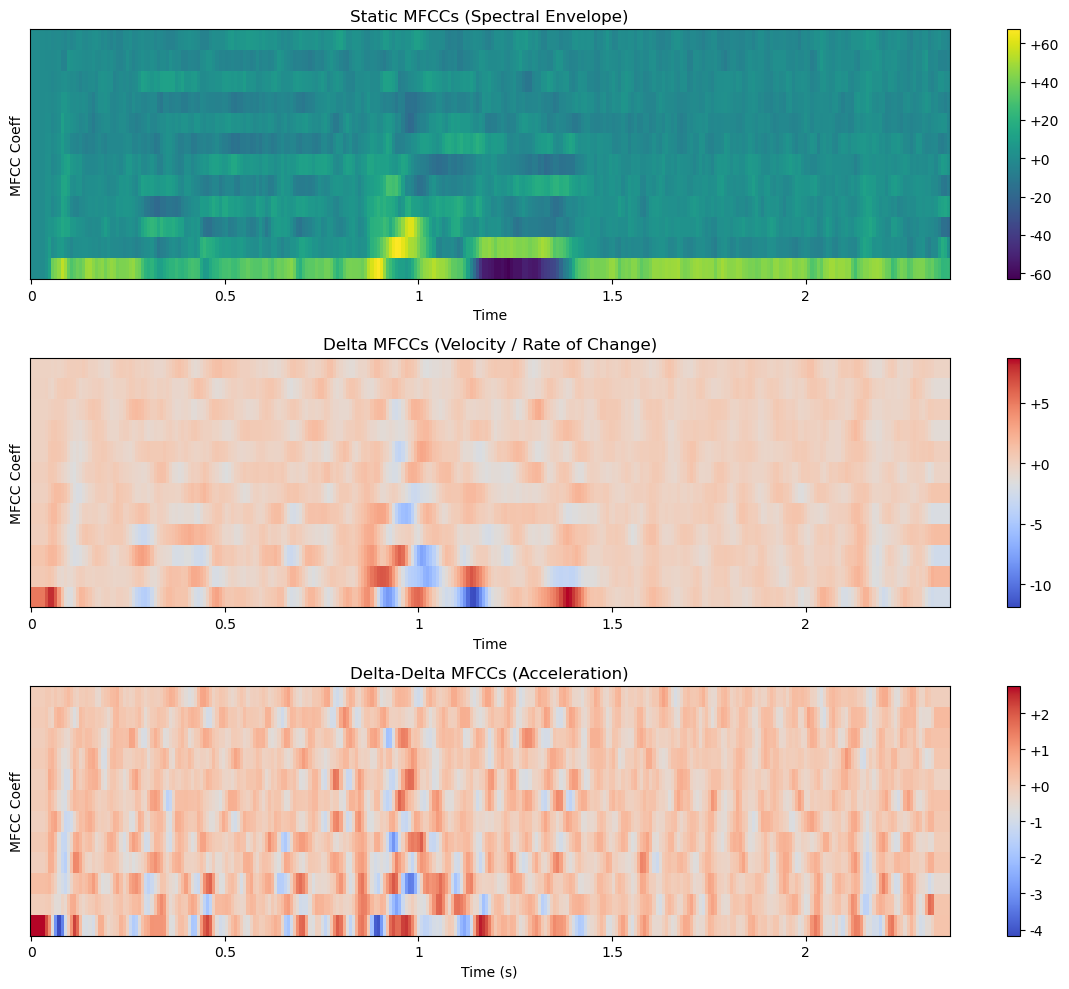

In [38]:
# order=1 calculates the first derivative (velocity)
delta_mfcc = librosa.feature.delta(mfccs, order=1)

# order=2 calculates the second derivative (acceleration)
delta2_mfcc = librosa.feature.delta(mfccs, order=2)

plt.figure(figsize=(12, 10))

# Plot Static MFCCs
plt.subplot(3, 1, 1)
librosa.display.specshow(mfccs[1:], x_axis='time', sr=SAMPLE_RATE, hop_length=HOP_LENGTH, cmap='viridis')
plt.colorbar(format='%+2.0f')
plt.title('Static MFCCs (Spectral Envelope)')
plt.ylabel('MFCC Coeff')

# Plot Delta MFCCs
plt.subplot(3, 1, 2)
# Using 'coolwarm' cmap is good for deltas because they center around 0 (red=positive change, blue=negative)
librosa.display.specshow(delta_mfcc[1:], x_axis='time', sr=SAMPLE_RATE, hop_length=HOP_LENGTH, cmap='coolwarm')
plt.colorbar(format='%+2.0f')
plt.title('Delta MFCCs (Velocity / Rate of Change)')
plt.ylabel('MFCC Coeff')

# Plot Delta-Delta MFCCs
plt.subplot(3, 1, 3)
librosa.display.specshow(delta2_mfcc[1:], x_axis='time', sr=SAMPLE_RATE, hop_length=HOP_LENGTH, cmap='coolwarm')
plt.colorbar(format='%+2.0f')
plt.title('Delta-Delta MFCCs (Acceleration)')
plt.ylabel('MFCC Coeff')
plt.xlabel('Time (s)')

plt.tight_layout()
plt.show()

In [39]:
def get_comprehensive_mfccs(y: np.ndarray) -> np.ndarray | None:
    """
    Computes a comprehensive feature vector consisting of Static MFCCs, Deltas, 
    and Delta-Deltas.

    This function extracts the Mel-Frequency Cepstral Coefficients (MFCCs) from 
    an input audio signal and appends their first and second temporal derivatives 
    (velocity and acceleration). The resulting matrix is transposed to shape 
    (n_samples, n_features), making it directly compatible with standard 
    classifiers like GMMs or SVMs.

    Args:
        y (np.ndarray): The input audio time-series (1D array).

    Returns:
        np.ndarray | None: A feature matrix of shape `(T, 39)`, where T is 
        the number of time frames. 
        
        The columns are ordered as:
            [Static MFCCs (0-12) | Delta MFCCs (0-12) | Delta-Delta MFCCs (0-12)]
        
        Returns `None` if the input signal `y` is too short to compute the 
        necessary derivatives (requires at least 9 frames).

    Example:
        >>> y, sr = librosa.load("speech.wav")
        >>> features = get_comprehensive_mfccs(y, sr)
        >>> if features is not None:
        ...     print(features.shape)
        ...     # Output: (120, 39)  -> 120 frames, 39 features
    """
    # 1. Safety Check: Empty audio
    if y is None or len(y) == 0:
        return None
    
    # 2. Extract Static MFCCs
    mfccs = librosa.feature.mfcc(
        y=y,
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_fft=FRAME_LENGTH,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
    )

    # 3. Compute Deltas (Velocity & Acceleration)
    try:
        # librosa.feature.delta requires a minimal width (default 9 frames).
        # Short audio clips will raise an error, which we catch here.
        d1 = librosa.feature.delta(mfccs)
        d2 = librosa.feature.delta(mfccs, order=2)
    except Exception:
        # Audio was too short to calculate deltas
        return None

    # 4. Concatenate and Transpose
    # Axis=0 stacks them vertically (13 + 13 + 13 = 39 rows)
    feature_matrix = np.concatenate([mfccs, d1, d2], axis=0)
    
    # Transpose to (Time, Features) for GMM training (e.g., T x 39)
    return feature_matrix.T

sample_feats = get_comprehensive_mfccs(sample_y)

sample_feats.shape

(297, 39)

### <a name="72-training-data-google-ava-speech"/> 7.2 Training Data: Google AVA-Speech

For Algorithm 3, we utilize the AVA-Speech dataset (released by Google Research in 2018), which is a subset of the larger AVA (Atomic Visual Actions) project. Unlike traditional speech datasets recorded in controlled studio environments (like TIMIT), AVA-Speech is derived from movies, providing a rich, "in-the-wild" acoustic environment.

The dataset consists of 15-minute audio segments extracted from over 160 movies available on YouTube. It provides dense, time-stamped labels for every segment of audio, categorized into four distinct classes:

- `CLEAN_SPEECH`: Speech with no perceptible background noise.
- `SPEECH_WITH_NOISE`: Speech overlapping with environmental noise (rustling, footsteps, traffic).
- `SPEECH_WITH_MUSIC`: Speech overlapping with background music (scores, diegetic music).
- `NO_SPEECH`: Segments containing silence, music only, or noise only.

To train our binary VAD classifier, `NO_SPEECH` is considered as **Non-speech** ($H_0$), with rest of the classes being **Speech** ($H_1$)

In [40]:
# Path to the directory containing the AVA dataset files
AVA_SPEECH_FOLDER = "ava_speech_trim/"

# Load the CSV file containing the ground truth labels.
# The original file has no header row, so we explicitly name the columns:
# - 'id': The YouTube video identifier (e.g., "-5KQ66BBWC4")
# - 'start': Start time of the segment in seconds
# - 'end': End time of the segment in seconds
# - 'label': The class (CLEAN_SPEECH, SPEECH_WITH_NOISE, SPEECH_WITH_MUSIC, NO_SPEECH)
df = pd.read_csv(
    AVA_SPEECH_FOLDER + "ava_speech_labels_v1.csv", 
    names=["id", "start", "end", "label"]
)

df

,id,start,end,label
0,5BDj0ow5hnA,900.00,905.67,SPEECH_WITH_NOISE
1,5BDj0ow5hnA,905.67,907.40,NO_SPEECH
2,5BDj0ow5hnA,907.40,908.08,SPEECH_WITH_NOISE
3,5BDj0ow5hnA,908.08,908.76,NO_SPEECH
4,5BDj0ow5hnA,908.76,910.15,SPEECH_WITH_NOISE
...,...,...,...,...
39869,UrsCy6qIGoo,1794.83,1795.55,SPEECH_WITH_NOISE
39870,UrsCy6qIGoo,1795.55,1796.56,NO_SPEECH
39871,UrsCy6qIGoo,1796.56,1797.07,CLEAN_SPEECH
39872,UrsCy6qIGoo,1797.07,1798.95,NO_SPEECH


The cell below processes the raw AVA Speech dataset to create the final training arrays (`inputs` and `labels`). It transforms audio files and their corresponding timestamp annotations into a supervised learning format.

1. Group Annotations by File (`agg_df`):

	- Since one audio file (movie clip) has multiple labeled segments (speech/no-speech), the code first groups the dataframe by `id`.

	- This creates a list of all `start`, `end`, and `label` values associated with each unique `.wav` file.

2. Audio Slicing with Time Offset (`init_sec`):

	- The code iterates through each audio file and loads it using `librosa`.

	- The AVA dataset timestamps are often relative to the original full-length movie, but the provided audio files are typically 15-minute segments starting at minute 15 (900 seconds).

	- The calculation `int((start - init_sec) * r)` adjusts the CSV timestamps to match the local time within the trimmed .wav file.

3. Feature Extraction (`get_comprehensive_mfccs`):

	- For each specific segment (start to end), it extracts the acoustic features (MFCCs).

	- These features serve as the Input (`X`) for the model.

4. Frame-Level Label Generation:

	- The model needs a label for every single frame of the MFCCs, not just one label for the whole clip.

	 - It creates a target array matching the length of the features (`feats.shape[0]`).

		- Class 0: Assigned if the label is `NO_SPEECH` (using `np.zeros`).
		- Class 1: Assigned for any other label (Speech), using `np.ones`.

5. Finally, we merges all processed segments from all files into two large numpy arrays: `inputs` (features) and `labels` (targets), ready for model training.


In [41]:
agg_df = df.groupby("id").agg({k: list for k in ["start", "end", "label"]})

inputs = []
labels = []

noise_label = "NO_SPEECH"
init_sec = 900

for i, row in agg_df.iterrows():
    print(f"Processing {i}.wav", end="\r", flush=False)
    y, r = librosa.load(f"{AVA_SPEECH_FOLDER}{i}.wav", sr=SAMPLE_RATE)

    
    for start, end ,label in zip(row["start"], row["end"], row["label"]):
        feats = get_comprehensive_mfccs(
            y[int((start - init_sec) * r) : int((end - init_sec) * r)]
        )

        if feats is None:
            continue

        inputs.append(feats)
        
        if label == noise_label:
            labels.append(np.zeros(feats.shape[0], dtype=int))
        else:
            labels.append(np.ones(feats.shape[0], dtype=int))

inputs = np.concatenate(inputs, axis=0)
labels = np.concatenate(labels, axis=0)

print()
print("Speech set:")
print(inputs[labels == 1, :][:5], end="\n\n")

print("Noise set:")
print(inputs[labels == 0, :][:5], end="\n\n")

Processing -FaXLcSFjUI.wav

/nix/store/rqn9br8nxckmzlqdvqayv32kcyvjnlb9-python3-3.12.11-env/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=479
  warnings.warn(


Processing -IELREHX_js.wav

/nix/store/rqn9br8nxckmzlqdvqayv32kcyvjnlb9-python3-3.12.11-env/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=480
  warnings.warn(
/nix/store/rqn9br8nxckmzlqdvqayv32kcyvjnlb9-python3-3.12.11-env/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=320
  warnings.warn(


Processing 2DUITARAsWQ.wav

...

Processing 9Y_l9NsnYE0.wav

/nix/store/rqn9br8nxckmzlqdvqayv32kcyvjnlb9-python3-3.12.11-env/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=160
  warnings.warn(


Processing JNb4nWexD0I.wav

/nix/store/rqn9br8nxckmzlqdvqayv32kcyvjnlb9-python3-3.12.11-env/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=321
  warnings.warn(


Processing zR725veL-DI.wav
Speech set:
[[-2.8312363e+02  5.0162117e+01  8.0747919e+00  4.0585170e+00
   6.4265382e-01  1.2086569e+00 -5.7985792e+00 -5.5101624e+00
   1.6209220e+00  1.8775246e+00  7.8725708e-01  1.2664109e-01
   3.5903859e-01  7.3879595e+00  1.1295513e+00 -1.5900131e+00
   3.4685161e+00  1.1160425e+00  1.9328573e-01  1.3379217e+00
   5.4331833e-01 -3.6857048e-01 -8.4299284e-01 -5.3942662e-01
  -5.0411159e-01 -1.1341240e+00  1.1503578e+00  2.2704844e+00
   9.1295719e-01  1.0000927e+00  1.0959349e+00  5.5354965e-01
  -6.8613583e-01 -4.7654039e-01 -8.1746643e-03 -5.2859485e-01
  -4.4009084e-01 -4.1973555e-01 -6.0287100e-01]
 [-2.6790512e+02  4.5549789e+01  7.3792782e+00  4.2085533e+00
   7.0735377e-01  1.7506934e+00 -3.5764899e+00 -2.4531925e+00
   1.5578920e+00  1.5158179e+00  1.7038682e+00  3.3387771e+00
   2.4336791e+00  7.3879595e+00  1.1295513e+00 -1.5900131e+00
   3.4685161e+00  1.1160425e+00  1.9328573e-01  1.3379217e+00
   5.4331833e-01 -3.6857048e-01 -8.4299284e-0

### <a name="73-algorithm-description-gmm-based-classification"/> 7.3 Algorithm Description: GMM-based Classification

Unlike Algorithm 1 (Energy) and Algorithm 2 (Hybrid), which rely on hard, deterministic thresholds (e.g., "If energy > 0.05..."), the GMM approach is probabilistic. It acknowledges that speech and noise signal characteristics often overlap. Instead of asking "Is this frame loud?", the GMM asks: "How likely is it that this feature vector was generated by a speech source versus a noise source?"

#### <a name="731-the-gaussian-mixture-model"/> 7.3.1 The Gaussian Mixture Model

A single Gaussian distribution (a "Bell curve") is insufficient to model the complexity of human speech, which contains diverse sounds like low-frequency vowels and high-frequency fricatives. A Gaussian Mixture Model (GMM) solves this by modeling the probability distribution as a weighted sum of $K$ distinct Gaussian components. For a feature vector $\mathbf{x}$ (our 39-dimensional MFCC vector), the probability likelihood is:

$$P(\mathbf{x} | \lambda) = \sum_{k=1}^{K} w_k \cdot \mathcal{N}(\mathbf{x} | \mu_k, \Sigma_k)$$

Where:

- $K$: The number of mixtures (typically 16-32 for VAD).
- $w_k$: The weight of the $k$-th component (prior probability).
- $\mathcal{N}(\dots)$: The multivariate Gaussian density function defined by mean vector $\mu_k$ and covariance matrix $\Sigma_k$.

#### <a name="732-training-phase-em-algorithm"/> 7.3.2 Training Phase (EM Algorithm)

We train two separate GMMs using the labeled data from the AVA-Speech dataset:

1. $\lambda_{speech}$: Trained on all frames labeled `CLEAN_SPEECH`, `SPEECH_WITH_NOISE`, and `SPEECH_WITH_MUSIC`. This model learns the "shape" of speech in MFCC space.

2. $\lambda_{noise}$: Trained on all frames labeled `NO_SPEECH`. This model learns the "shape" of silence, background noise, and music.

The parameters ($w, \mu, \Sigma$) are optimized using the Expectation-Maximization (EM) algorithm to maximize the likelihood of the training data.

#### <a name="733-classification-phase-log-likelihood-ratio-llr"/> 7.3.3 Classification Phase: Log-Likelihood Ratio (LLR)

To classify a new, unseen audio frame with feature vector $\mathbf{x}_t$:

1. We calculate the likelihood that the frame belongs to the Speech model: $P(\mathbf{x}_t | \lambda_{speech})$.
2. We calculate the likelihood that it belongs to the Noise model: $P(\mathbf{x}_t | \lambda_{noise})$.

The final decision is based on the Log-Likelihood Ratio (LLR):

$$\Lambda(\mathbf{x}_t) = \log P(\mathbf{x}_t | \lambda_{speech}) - \log P(\mathbf{x}_t | \lambda_{noise})$$

If $\Lambda(\mathbf{x}_t) > \text{Threshold}$ (typically $0$), classify as Speech ($H_1$). Otherwise, classify as Non-Speech ($H_0$).

This "ratio test" makes the system robust: even if a noise frame is loud (high energy), it will likely have a low matching score with the $\lambda_{speech}$ model because its spectral shape (MFCCs) doesn't look like speech, resulting in a negative LLR and a correct rejection.


In [33]:
def train_vad_gmms(
    speech_array: np.ndarray,
    noise_array: np.ndarray
) -> tuple[GaussianMixture, GaussianMixture]:
    """
    Train Gaussian Mixture Models (GMMs) for speech and noise feature distributions.
    
    This function fits two separate GMMs: one using speech features and the other
    using noise features. The number of mixture components for each model is set
    to the feature dimensionality of the respective input. These trained models
    may later be used for probabilistic Voice Activity Detection (VAD), where
    frame likelihoods under both models are compared.
    
    Args:
        speech_array (np.ndarray):
            Feature matrix for speech frames of shape `(n_samples, n_features)`.
        noise_array (np.ndarray):
            Feature matrix for noise frames of shape `(n_samples, n_features)`.
    
    Returns:
        tuple[GaussianMixture, GaussianMixture]:
            `(speech_gmm, noise_gmm)` — trained GMM models for speech and noise.
    
    Example:
        >>> speech_gmm, noise_gmm = train_vad_gmms(speech_feats, noise_feats)
        >>> # Later: compare likelihoods for VAD classification
    """
    speech_gmm = GaussianMixture(
        n_components=N_GMM_COMPONENTS,
        max_iter=GMM_MAX_ITER,
        verbose=1,
        random_state=RANDOM_SEED,
    )
    noise_gmm = GaussianMixture(
        n_components=N_GMM_COMPONENTS,
        max_iter=GMM_MAX_ITER,
        verbose=1,
        random_state=RANDOM_SEED,
    )

    print("Training speech GMM:")
    speech_gmm.fit(speech_array)
    
    print("Training noise GMM:")
    noise_gmm.fit(noise_array)

    return speech_gmm, noise_gmm

    
speech_gmm, noise_gmm = train_vad_gmms(inputs[labels == 1, :], inputs[labels == 0, :])
speech_gmm

Training speech GMM:
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
Initialization converged.
Training noise GMM:
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
Initialization converged.


GaussianMixture(max_iter=50, n_components=16, random_state=42, verbose=1)

Save and then load the GMMs

In [ ]:
with open("speech_gmm.pkl", "wb") as f:
    pickle.dump(speech_gmm, f, protocol=5)

with open("noise_gmm.pkl", "wb") as f:
    pickle.dump(noise_gmm, f, protocol=5)

In [42]:
with open("speech_gmm.pkl", "rb") as f:
    speech_gmm = pickle.load(f)

with open("noise_gmm.pkl", "rb") as f:
    noise_gmm = pickle.load(f)

#### <a name="734-io"/> 7.3.4 Inputs and Outputs

##### Inputs
- y (Array): The discrete-time audio waveform array $x[n]$.
- speech_model (GMM Object): The pre-trained Gaussian Mixture Model representing the speech distribution ($\lambda_{speech}$).
- noise_model (GMM Object): The pre-trained Gaussian Mixture Model representing the noise distribution ($\lambda_{noise}$).
- threshold (Float): The decision boundary value for the Log-Likelihood Ratio (default: 0).
##### Outputs
- vad_mask (Boolean Array): A binary sequence corresponding to the input frames, where True (1) represents a Speech classification ($LLR > \text{threshold}$) and False (0) - represents Non-Speech.


#### <a name="gmm-code"/> 7.3.5 Pseudocode

```
FUNCTION vad_gmm(signal, speech_model, noise_model, threshold):
    // 1. Feature Extraction (MFCC + Delta + Delta-Delta)
    features = GET_COMPREHENSIVE_MFCCS(signal)
    // 2. Compute Log-Likelihoods
    // score_samples returns log(P(x|model))
    log_prob_speech = speech_model.SCORE_SAMPLES(features)
    log_prob_noise  = noise_model.SCORE_SAMPLES(features)
    // 3. Log-Likelihood Ratio Test
    llr = log_prob_speech - log_prob_noise
    // 4. Binary Classification
    // Compare LLR against the variable threshold
    vad_mask = (llr > threshold)
    RETURN vad_mask
END FUNCTION
```

#### <a name="gmm-impl"/> 7.3.6 Implementation

In [43]:
def gmm_vad(
    speech_gmm: GaussianMixture,
    noise_gmm: GaussianMixture,
    y: np.ndarray,
    threshold: float = 0,
) -> np.ndarray:
    """
    Perform Voice Activity Detection (VAD) by comparing GMM likelihoods of speech vs noise.

    This function extracts MFCC + delta + delta-delta features using
    `get_comprehensive_mfccs`, then evaluates each frame under speech and noise
    Gaussian Mixture Models. Frames whose likelihood under the speech model is
    higher than under the noise model are classified as speech.

    Args:
        speech_gmm (GaussianMixture):
            Trained GMM representing speech feature distribution.
        noise_gmm (GaussianMixture):
            Trained GMM representing noise feature distribution.
        y (np.ndarray):
            Input audio waveform.

    Returns:
        np.ndarray:
            Boolean array indicating speech activity per feature frame.
            - True  → speech detected
            - False → noise / silence

    Example:
        >>> vad_mask = gmm_vad(speech_gmm, noise_gmm, y)
        >>> print(vad_mask.shape)  # One decision per feature frame
    """
    feats = get_comprehensive_mfccs(y)

    speech_scores = speech_gmm.score_samples(feats)
    noise_scores = noise_gmm.score_samples(feats)

    llr = speech_scores - noise_scores

    return llr > threshold
    

vad_results = gmm_vad(speech_gmm, noise_gmm, sample_y, GMM_THRESHOLD)

#### <a name="735-visualization-gmm-based-vad-results"/> 7.3.7 Visualization: GMM-Based VAD Results

This cell visualizes the Voice Activity Detection (VAD) process by comparing the raw audio waveform against the internal confidence scores of the Gaussian Mixture Model (GMM). It generates a stacked plot with two components:
1. Top Plot (The Decision):
- Displays the raw Audio Waveform in gray.
- Overlays the final VAD Decision (green shading) where the model predicted speech.

2. Bottom Plot (The Logic):
- Plots the Log-Likelihood Ratio (LLR). This score represents how much more likely a frame is to be "Speech" rather than "Noise."
- Red Dashed Line: The decision threshold.
- Green Fill: Areas where the score exceeds the threshold (Speech).
- Red Fill: Areas where the score falls below the threshold (Noise).

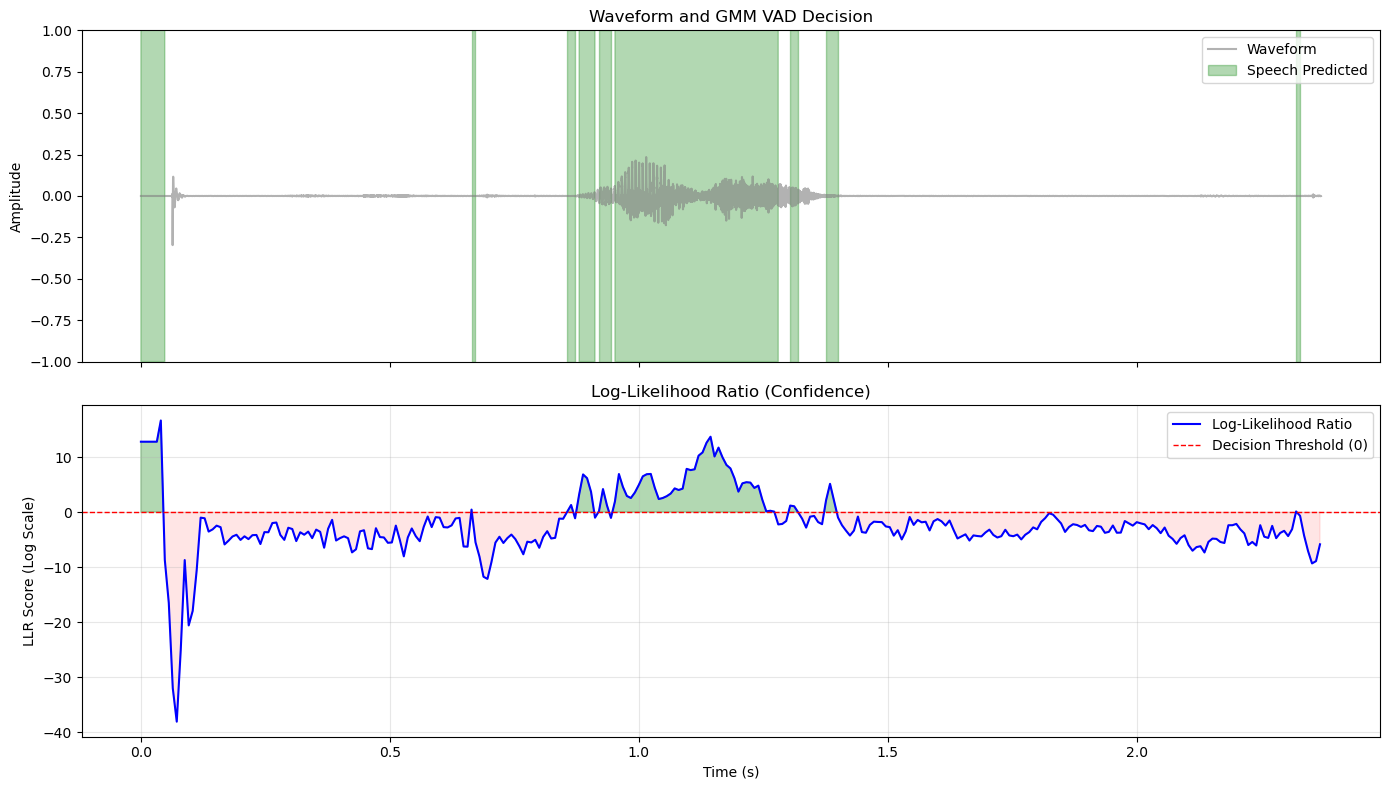

In [44]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

feats = get_comprehensive_mfccs(sample_y)
llr = speech_gmm.score_samples(feats) - noise_gmm.score_samples(feats)

time_waveform = np.linspace(0, len(sample_y) / SAMPLE_RATE, len(sample_y))
time_frames = librosa.frames_to_time(np.arange(len(llr)), sr=SAMPLE_RATE, hop_length=HOP_LENGTH)

ax1.plot(time_waveform, sample_y, label="Waveform", color='gray', alpha=0.6)

mask_expanded = np.repeat(vad_results, HOP_LENGTH)[:len(sample_y)]

ax1.fill_between(time_waveform, -1, 1, where=mask_expanded, 
                 color='green', alpha=0.3, label="Speech Predicted")

ax1.set_title("Waveform and GMM VAD Decision")
ax1.set_ylabel("Amplitude")
ax1.legend(loc="upper right")
ax1.set_ylim(-1, 1)

ax2.plot(time_frames, llr, color='blue', linewidth=1.5, label="Log-Likelihood Ratio")
ax2.axhline(GMM_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f"Decision Threshold ({GMM_THRESHOLD})")
ax2.fill_between(time_frames, GMM_THRESHOLD, llr, where=(llr > GMM_THRESHOLD), 
                 interpolate=True, color='green', alpha=0.3)
ax2.fill_between(time_frames, GMM_THRESHOLD, llr, where=(llr <= GMM_THRESHOLD), 
                 interpolate=True, color='red', alpha=0.1)

ax2.set_title("Log-Likelihood Ratio (Confidence)")
ax2.set_ylabel("LLR Score (Log Scale)")
ax2.set_xlabel("Time (s)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The figure above illustrates the GMM-based detection on the keyword "Yes". The GMM output (green mask) appears significantly more "jagged" and fragmented than the Energy or Hybrid algorithms. Unlike the deterministic thresholding of Algo 1/2, the GMM calculates the Log-Likelihood Ratio (LLR) for every frame independently based on its MFCC probability. The mask frequently toggles on/off in the silence regions. This is not random; the model is detecting "micro-segments" of silence that statistically resemble the "Speech" class it learned during training.

Visualizing Algorithm 4 for: KeniNicholasOndang
Blue = Waveform | Orange = Detected Speech


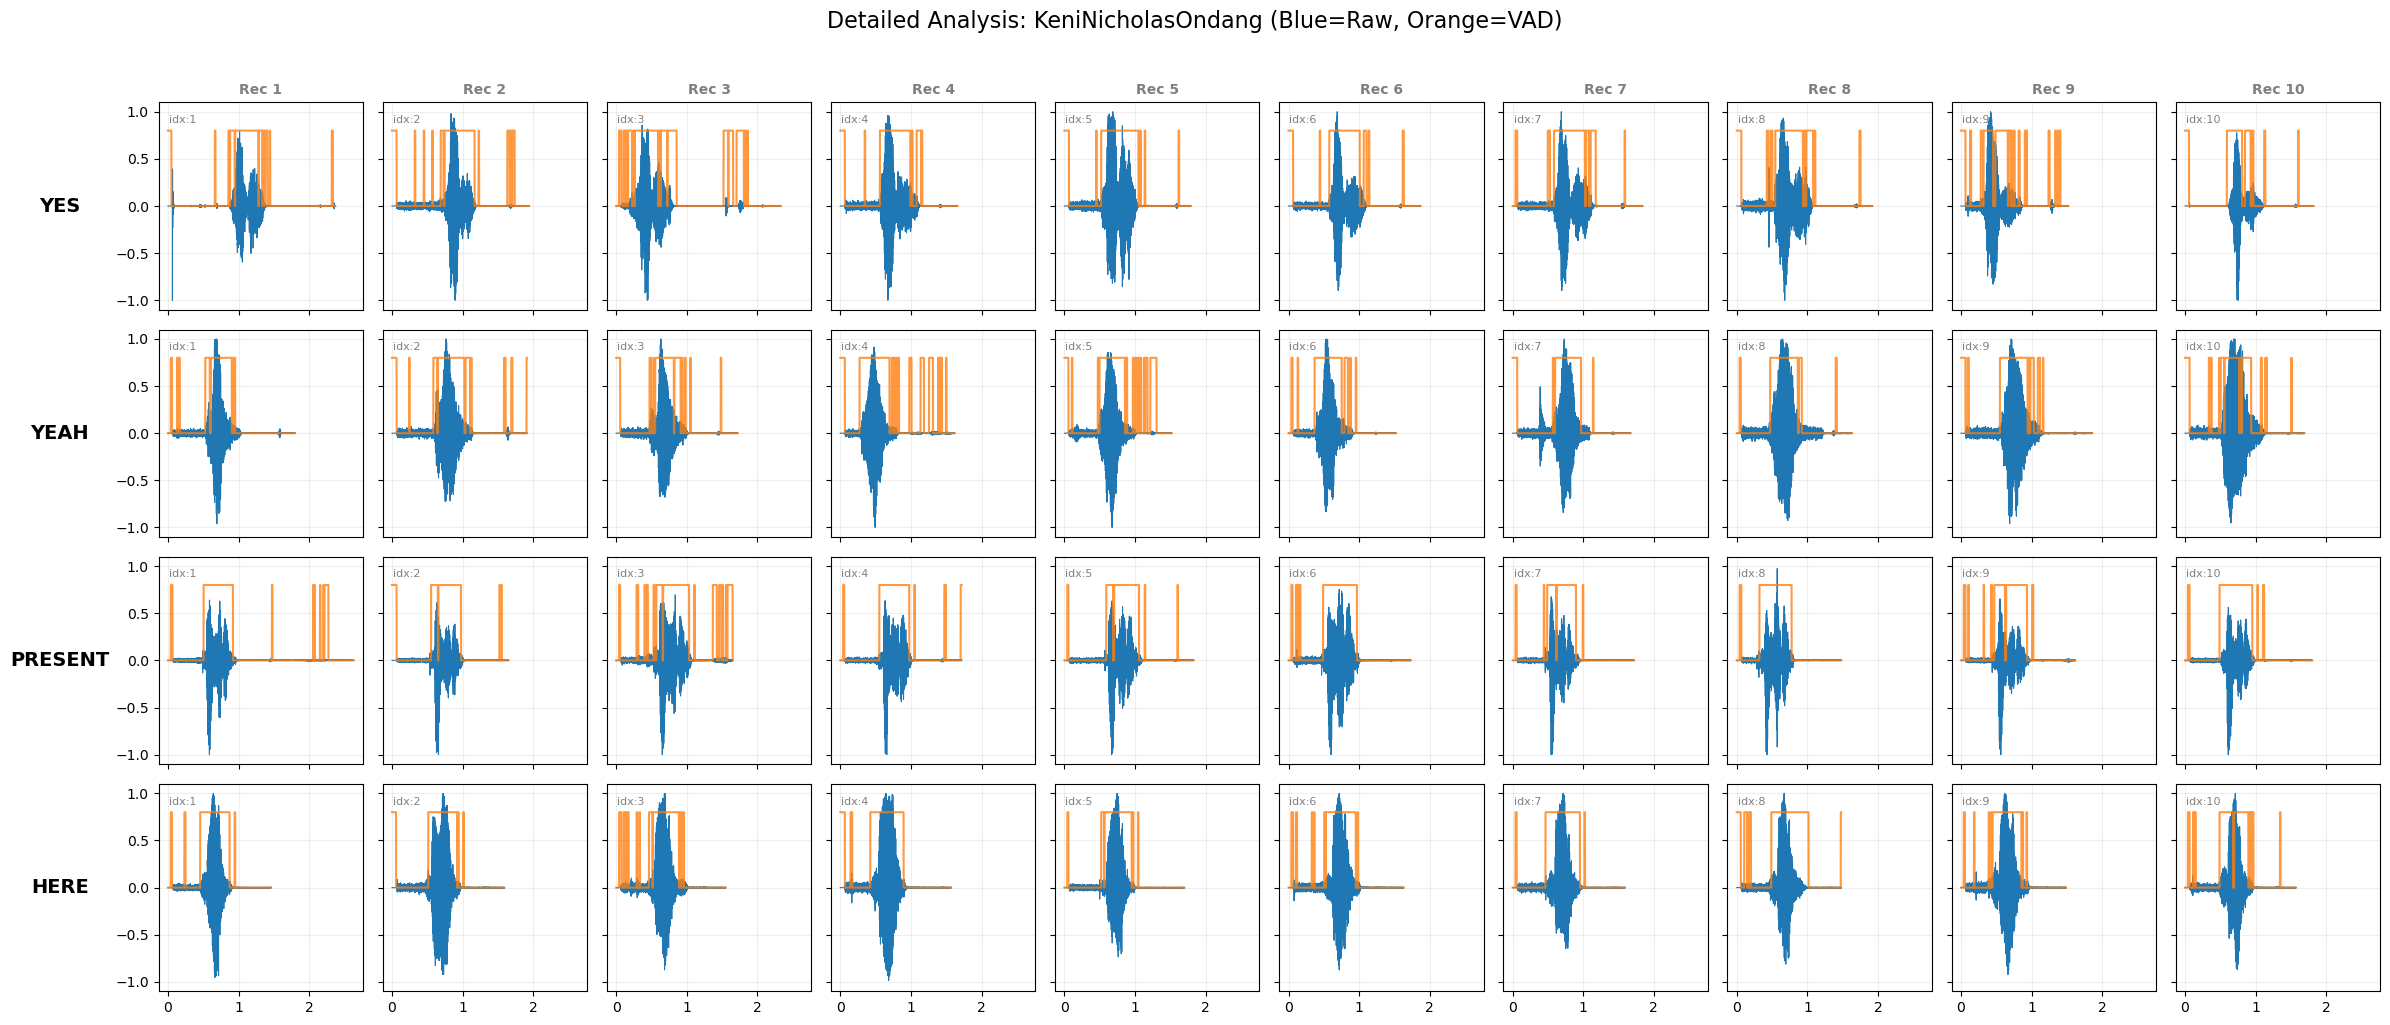

In [45]:
single_student = [STUDENTS[0]]

print(f"Visualizing Algorithm 4 for: {single_student[0]}")
print("Blue = Waveform | Orange = Detected Speech")

plot_dataset_recordings(
    dataset_manifest, 
    [STUDENTS[0]], 
    KEYWORDS, 
    sampling_rate=SAMPLE_RATE, 
    vad_fn=partial(gmm_vad, speech_gmm, noise_gmm, threshold=GMM_THRESHOLD),          
    separate_recordings=True
)

The figure displays the GMM performance across all 40 recordings. This visualization reveals a critical flaw known as Domain Mismatch. The most striking feature is the high density of false alarms in the silence regions. The GMM was trained on the Google AVA Dataset, which consists of movie audio containing significant background noise (traffic, music, room tone). Consequently, the model learned a "Noise" distribution ($\lambda_{noise}$) that is quite loud and complex. When tested on the Project Keyword Dataset (which has near-perfect digital silence), the model is confused. The clean silence does not fit well into its learned "Noise" cluster. Occasionally, the LLR tips slightly in favor of the "Speech" cluster (which contains breathy/quiet speech), causing the model to hallucinate speech activity in pure silence. While the algorithm captures the speech segments reasonably well, the resulting mask is "noisy" and lacks the temporal stability of the simpler, rule-based algorithms.


## <a name="8-algorithm-4-deep-neural-nerwork"/> 8. Algorithm 4: Deep Neural Nerwork

### <a name="81-overview-and-goal"/> 8.1 Overview and Goal

While the Gaussian Mixture Model (Algorithm 3) effectively models the distributions of speech and noise, it assumes that these features fit into specific statistical shapes (Gaussian clusters). Real-world audio, however, often exhibits complex, non-linear relationships that simple distributions cannot capture. 
The goal of this algorithm is to train a neural network that maps acoustic features directly to a probability of speech presence ($P(Speech|x)$) without making strong statistical assumptions. DNNs can learn hierarchical representations, capturing intricate interactions between the static spectral shape and the temporal dynamics (Deltas) that GMMs might miss.

### <a name="82-feature-extraction"/> 8.2 Feature Extraction

This algorithm utilizes the same high-dimensional feature set as Algorithm 3. By feeding the network the exact same inputs, we can fairly evaluate the power of the model architecture itself.
- Input Vector: 39-dimensional MFCC vector per frame.
    - 13 Static Coefficients (Spectral Envelope)
    - 13 Delta Coefficients (Velocity)
    - 13 Delta-Delta Coefficients (Acceleration)

### <a name="83-model-architecture"/> 8.3 Model Architecture

We implement a Feed-Forward Neural Network (also known as a Multi-Layer Perceptron) using the Keras framework. The architecture utilizes a "bottleneck" design to compress and then expand the feature representation.

| Layer | Neurons | Activation | Description | 
| --- | --- | --- | --- |
| Input Layer | 39 | - | Matching the feature dimension |
| Hidden Layer 1 | 32 | ReLU | - |
| Hidden Layer 2 | 64 | ReLU | - |
| Hidden Layer 3 (Core) | 128 | ReLU | Captures high-level abstractions |
| Hidden Layer 4 | 64 | ReLU | - |
| Hidden Layer 5 | 32 | ReLU | - |
| Output Layer | 1 | Sigmoid | - |

- ReLU (Rectified Linear Unit): Used in hidden layers to introduce non-linearity and solve the vanishing gradient problem.
$$f(x) = \max(0, x)$$
- Sigmoid: Used in the output layer to squash the result into a probability range $[0, 1]$.
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$


In [46]:
model = keras.Sequential([
    layers.Input(shape=(N_MFCC * 3,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,081 (86.25 KB)

 Trainable params: 22,081 (86.25 KB)

 Non-trainable params: 0 (0.00 B)

### <a name="84-dataset-and-experimental-setup"/> 8.4 Dataset and Experimental Setup

Similar to Algorithm 3, this supervised learning model requires a massive amount of labeled data to generalize effectively.
- Training Dataset: Google AVA-Speech Dataset. The model is trained on the tens of thousands of speech/noise frames extracted from the AVA dataset to learn the general characteristics of human speech in noisy environments.
- Inference Dataset: Project Keyword Dataset. Once trained, the model is frozen and evaluated on the 3-speaker custom dataset to test its detection performance on the specific keywords ("Yes", "Present", etc.).

### <a name="85-procedural-logic"/> 8.5 Procedural Logic

#### Phase 1: Training (Backpropagation)
The network is trained to minimize the error between its prediction and the true label (0 or 1).
- Loss Function: Binary Cross-Entropy, which heavily penalizes confident wrong predictions.$$Loss = -\frac{1}{N} \sum_{i=1}^{N} [y_i \cdot \log(\hat{y}_i) + (1-y_i) \cdot \log(1-\hat{y}_i)]$$
- Optimizer: Adam (Adaptive Moment Estimation), which adjusts the learning rate for each parameter individually.
- Early Stopping: Training is halted if the validation loss does not improve for 3 consecutive epochs to prevent overfitting.

#### Phase 2: Inference (Forward Pass)
- Feature Extraction: Convert the input audio into the 39-dim MFCC matrix.
- Forward Propagation: Pass the features through the 5 hidden layers.
- Probability Estimation: The final neuron outputs a value $\hat{y} \in [0, 1]$.
- Thresholding:$$VAD[n] = \begin{cases} 1, & \text{if } \hat{y} > 0.5 \\ 0, & \text{otherwise} \end{cases}$$


In [49]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=[keras.metrics.BinaryAccuracy(name="acc")],
)

history = model.fit(
    x=inputs,
    y=labels,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)],
)

Epoch 1/10
112646/112646 ━━━━━━━━━━━━━━━━━━━━ 113s 996us/step - acc: 0.7923 - loss: 0.4452 - val_acc: 0.7798 - val_loss: 0.4673
Epoch 2/10
112646/112646 ━━━━━━━━━━━━━━━━━━━━ 114s 1ms/step - acc: 0.8048 - loss: 0.4239 - val_acc: 0.7837 - val_loss: 0.4650
Epoch 3/10
112646/112646 ━━━━━━━━━━━━━━━━━━━━ 111s 983us/step - acc: 0.8080 - loss: 0.4182 - val_acc: 0.7841 - val_loss: 0.4645
Epoch 4/10
112646/112646 ━━━━━━━━━━━━━━━━━━━━ 116s 1ms/step - acc: 0.8096 - loss: 0.4153 - val_acc: 0.7803 - val_loss: 0.4763
Epoch 5/10
112646/112646 ━━━━━━━━━━━━━━━━━━━━ 117s 1ms/step - acc: 0.8106 - loss: 0.4136 - val_acc: 0.7806 - val_loss: 0.4717
Epoch 6/10
112646/112646 ━━━━━━━━━━━━━━━━━━━━ 117s 1ms/step - acc: 0.8117 - loss: 0.4118 - val_acc: 0.7829 - val_loss: 0.4693


### <a name="86-inputs-and-outputs"/> 8.6 Inputs and Outputs

#### Inputs
- signal (Array): The discrete-time audio waveform array $x[n]$ to be processed.
- model (Keras Model Object): The pre-trained Deep Neural Network (Multi-Layer Perceptron) containing the weights and architecture defined in Section 4.5.3.
- sampling_rate (Integer): The sampling frequency of the audio (must match the training rate, typically 16,000 Hz).
#### Outputs
- vad_mask (Boolean Array): A binary sequence corresponding to the input frames, where True (1) represents a Speech classification ($P(Speech|x) > \text{threshold}$) and False (0) represents Non-Speech.

### <a name="dnn-code"/> 8.7 Pseudocode

```
Input: signal (Array), model (DNN), threshold (Float, typically 0.5)
Output: vad_mask (Boolean Array)

function VAD_DNN(signal, model, threshold)

    // STEP 1: FEATURE EXTRACTION
    features <- GET_COMPREHENSIVE_MFCCS(signal)

    // STEP 2: FORWARD PASS (INFERENCE)
    probabilities <- model.PREDICT(features)

    // STEP 3: BINARY CLASSIFICATION
    vad_mask <- (probabilities > threshold)
    return vad_mask

end function
```

### <a name="dnn-impl"/> 8.8 Implementation

In [50]:
def dnn_vad(dnn: keras.Model, y: np.ndarray) -> np.ndarray:
    """
    Perform Voice Activity Detection (VAD) using a trained Deep Neural Network (DNN).

    This function extracts MFCC + delta + delta-delta features from the input
    audio and feeds them into a neural network model for binary classification.
    The model is expected to output a probability per frame, and speech is
    detected whenever the predicted value exceeds `0.5`.

    Args:
        dnn (keras.Model):
            A trained neural network model accepting MFCC-based features.
        y (np.ndarray):
            Input audio waveform.

    Returns:
        np.ndarray:
            Boolean array indicating speech activity per frame.

    Example:
        >>> vad_mask = dnn_vad(model, y)
        >>> speech_frames = y[vad_mask]
    """
    return dnn.predict(get_comprehensive_mfccs(y), verbose=0).flatten() > 0.5

vad_results = dnn_vad(model, sample_y)

### <a name="87-visualization"/> 8.9 Visualization: DNN-Based VAD Performance

This cell evaluates the Deep Neural Network's ability to distinguish speech from non-speech by visualizing its raw output probabilities against the actual audio waveform. Unlike the GMM approach (which used Log-Likelihood Ratios), the DNN outputs a direct probability score between 0 and 1.

The visualization consists of two synchronized plots:

1. Top Plot (Waveform & Decision):
    - Gray Line: The raw audio waveform (`sample_y`).
    - Green Highlight: The final binary decision made by the system.

2. Bottom Plot (Model Confidence):
    - Blue Line: The output of the Sigmoid activation function from the model's final layer. This represents the probability $P(\text{Speech} | \text{Input})$.
    - Red Dashed Line: The standard decision threshold (0.5).
    - Green/Red Fill:
        - Green: Areas where the model is confident it is speech (Probability > 0.5).
        - Red: Areas where the model is confident it is silence/noise (Probability ≤ 0.5).

In the previous GMM visualization, we looked at unbounded likelihood ratios. Here, the y-axis is strictly bounded between 0.0 and 1.0, making the confidence metric much easier to interpret intuitively (e.g., 0.9 is 90% sure it's speech).

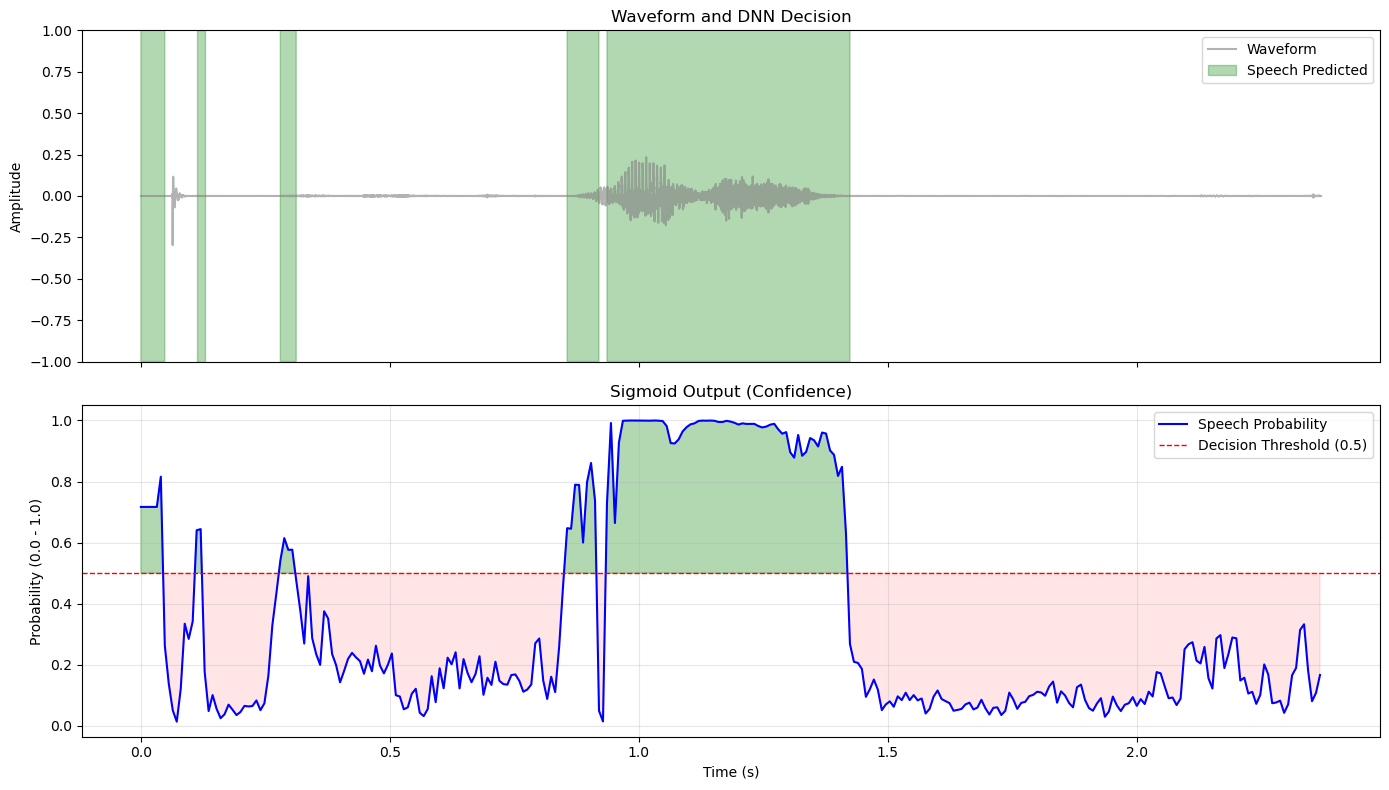

In [51]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

pred = model.predict(get_comprehensive_mfccs(sample_y), verbose=0).flatten()

time_waveform = np.linspace(0, len(sample_y) / SAMPLE_RATE, len(sample_y))
time_frames = librosa.frames_to_time(np.arange(len(pred)), sr=SAMPLE_RATE, hop_length=HOP_LENGTH)

ax1.plot(time_waveform, sample_y, label="Waveform", color='gray', alpha=0.6)

mask_expanded = np.repeat(vad_results, HOP_LENGTH)[:len(sample_y)]

ax1.fill_between(time_waveform, -1, 1, where=mask_expanded, 
                 color='green', alpha=0.3, label="Speech Predicted")

ax1.set_title("Waveform and DNN Decision")
ax1.set_ylabel("Amplitude")
ax1.legend(loc="upper right")
ax1.set_ylim(-1, 1)

ax2.plot(time_frames, pred, color='blue', linewidth=1.5, label="Speech Probability")
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label="Decision Threshold (0.5)")
ax2.fill_between(time_frames, 0.5, pred, where=(pred > 0.5), 
                 interpolate=True, color='green', alpha=0.3)
ax2.fill_between(time_frames, 0.5, pred, where=(pred <= 0.5), 
                 interpolate=True, color='red', alpha=0.1)

ax2.set_title("Sigmoid Output (Confidence)")
ax2.set_ylabel("Probability (0.0 - 1.0)")
ax2.set_xlabel("Time (s)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In the silence regions before and after the word "Yes", the probability does not stay at a perfect zero. Instead, it fluctuates (e.g., spiking to $0.2$ or $0.3$) in response to background ambiance. While the threshold (0.5) suppresses these spikes, the underlying instability is visible compared to the flatline of Algorithm 1. The probability drops sharply at the end of the vowel. Unlike Algorithm 2 (Hybrid) which "held on" to the unvoiced /s/, the DNN's confidence drops as soon as the spectral characteristics shift away from the "Voiced Speech" patterns it learned from the training data.


Visualizing Algorithm 4 for: KeniNicholasOndang
Blue = Waveform | Orange = Detected Speech


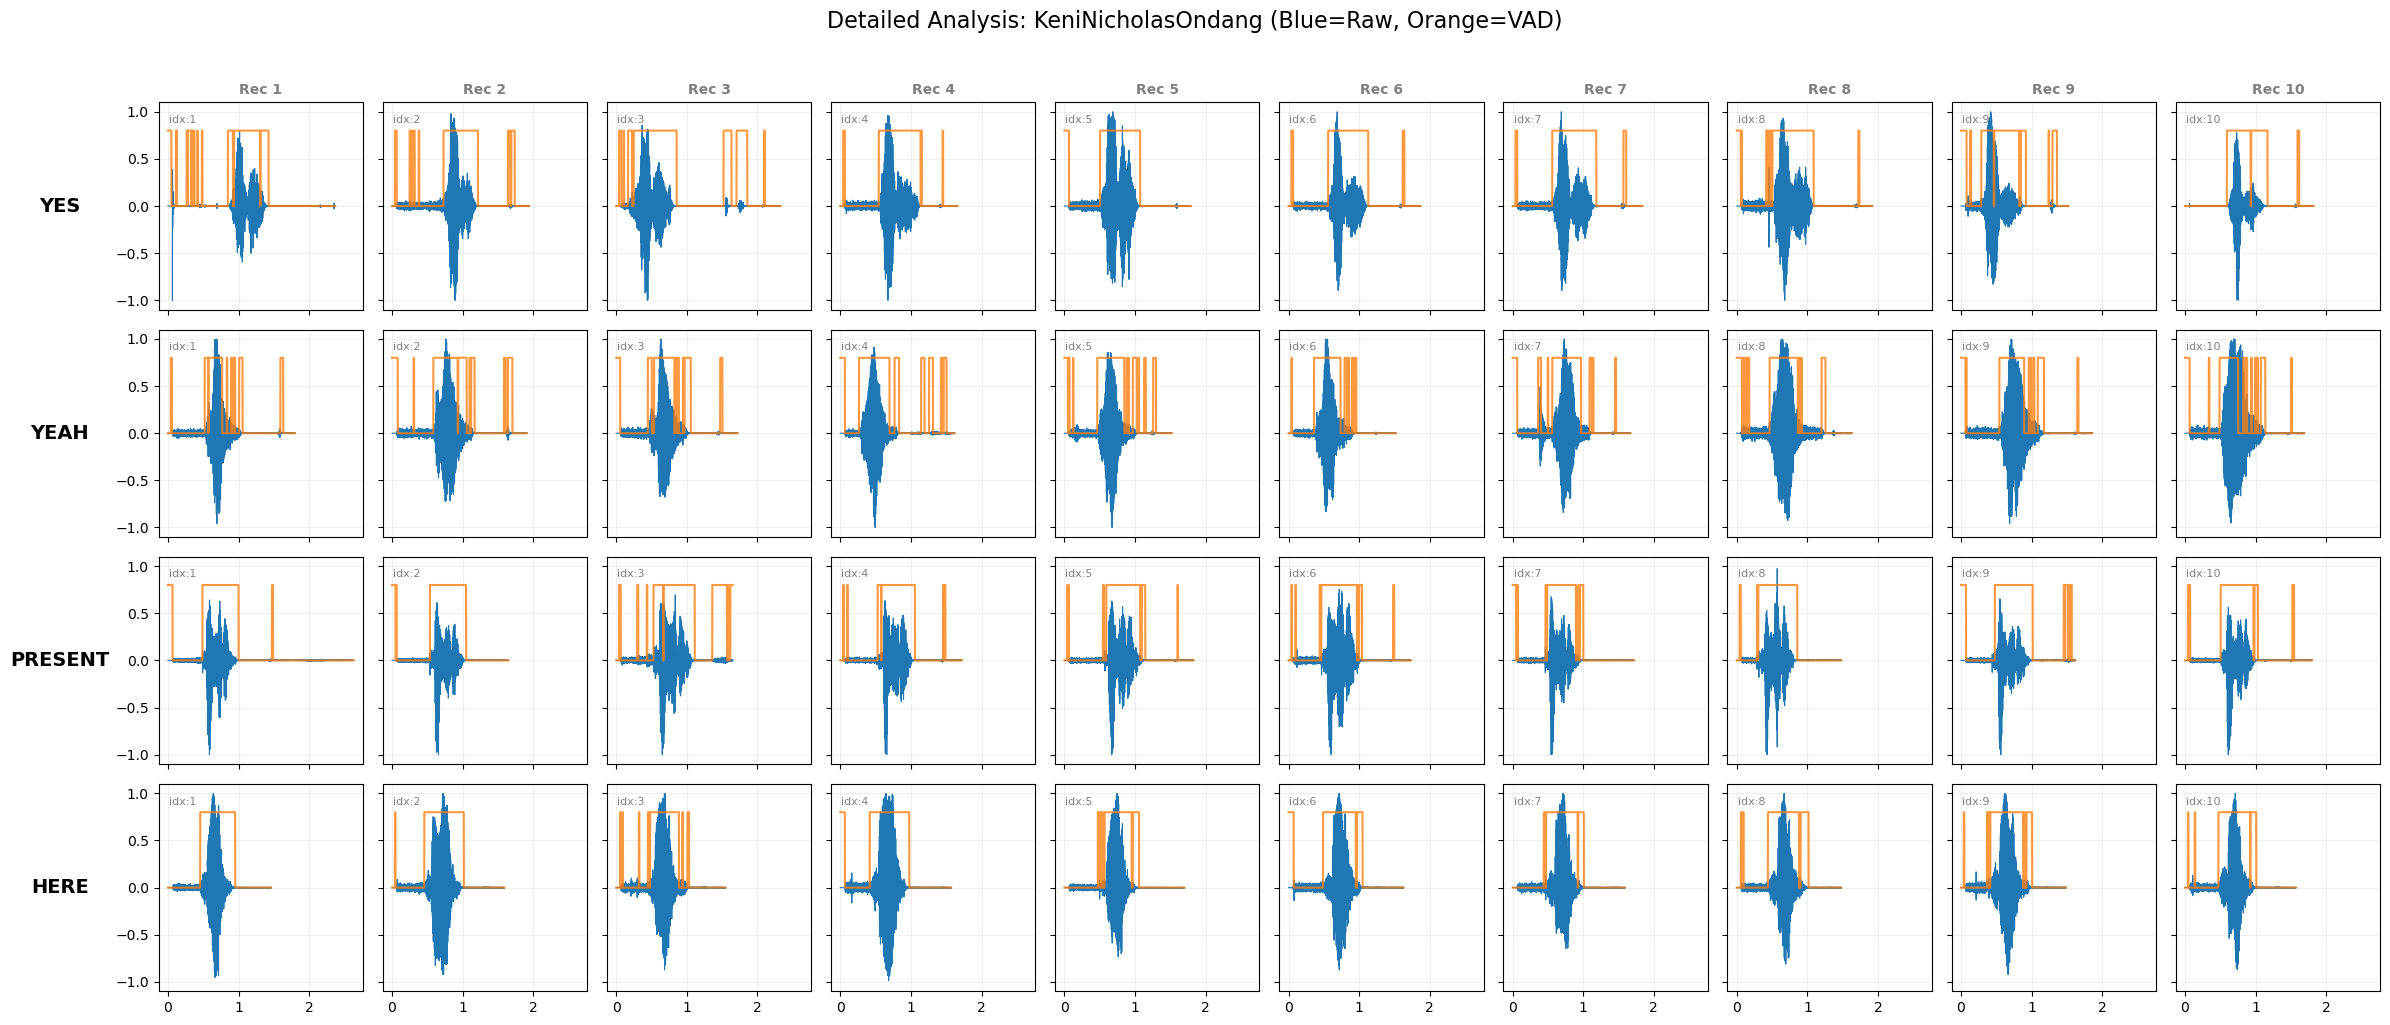

In [52]:
single_student = [STUDENTS[0]]

print(f"Visualizing Algorithm 4 for: {single_student[0]}")
print("Blue = Waveform | Orange = Detected Speech")

plot_dataset_recordings(
    dataset_manifest, 
    [STUDENTS[0]], 
    KEYWORDS, 
    sampling_rate=SAMPLE_RATE, 
    vad_fn=partial(dnn_vad, model),          
    separate_recordings=True
)

This visualization highlights the Generalization Gap or "Domain Mismatch." Compared to the clean, solid blocks of Algorithm 2 (Hybrid), the DNN masks appear more fragmented or "jittery." The masks often break briefly in the middle of words or flicker at the edges. The DNN was trained on the AVA Dataset (Movie Audio), where "Speech" is often loud and "Noise" is complex. When applied to the Project Keyword Dataset (Studio Audio), the model finds the "clean silence" unfamiliar. It occasionally interprets the lack of noise as a strange signal, leading to hesitation (flickering). Despite the jitter, the algorithm acts as a Strict Gatekeeper. It tends to reject "marginal" sounds (like breaths or weak consonants) that do not perfectly match its internal representation of speech. While this makes the mask look "worse" (less complete) to the human eye than Algorithm 2, it ensures that the frames it does select are high-confidence speech.

## <a name="9-evaluation"/> 9. Experiment Results and Evaluation

### <a name="91-load-data-for-gmms"/> 9.1 Experimental Methodology

To rigorously assess the performance of the four implemented Voice Activity Detection (VAD) algorithms, we established a multi-faceted evaluation framework. A critical constraint in our study was the absence of frame-level ground truth labels for the Project Keyword Dataset. Since we cannot calculate exact VAD accuracy (e.g., intersection-over-union) without manually annotating every millisecond of the 120 recordings, we adopted a Task-Based Evaluation via Speaker Recognition.

### <a name="92-evaluation-energy-based-detection-ste"/> 9.2 Task Based Evaluation (Speaker Recognition Module)

To provide an objective, quantitative measure of VAD performance, we integrated the algorithms into a downstream Speaker Recognition pipeline. The hypothesis is that a superior VAD will effectively filter out non-discriminative silence frames, thereby improving the accuracy and efficiency of the speaker classifier.

#### Model Architecture

GRU-Based Classifier Instead of a simple statistical model, we implemented a Deep Learning classifier utilizing Gated Recurrent Unit (GRU) networks. Like LSTMs, GRUs are recurrent neural networks designed to capture the unique temporal evolution of a speaker's voice (e.g., pitch contour, speaking rate) but with a more efficient architecture.

- Input Layer: Accepts a variable-length sequence of 39-dimensional MFCC vectors (identical to the VAD feature set).
- GRU Layer: A recurrent layer (e.g., 32 units) processes the frame sequence and outputs a final hidden state vector representing the "speaker embedding."
- Classification Head: A Dense (Fully Connected) layer with a Softmax activation function producing a probability distribution over the 3 target classes ($P(Keni), P(Thant), P(Nguyen)$).

#### Data Partitioning

To ensure the system generalizes to the speaker's identity rather than memorizing recording artifacts, we curated two distinct datasets:
- Training Set (Enrollment): The original Project Keyword Dataset (120 recordings) described in Section 4.1. This is used to train the GRU classifier to recognize the three students.
- Test Set (Query): A newly recorded set of 120 audio files. These files feature the same speakers and keywords but are distinct physical recordings that the model has never seen before.

#### Experimental Protocol

We evaluate the impact of VAD by comparing the SRM's performance on the Test Set under different filtering conditions:
- Baseline: The SRM is trained and tested on VAD-filtered audio from Algorithm 1.
- Comparisons: The process is repeated for Algorithms 2, 3, and 4. In each case, the VAD algorithm pre-processes the audio, removing all frames classified as "Noise/Silence" before they reach the GRU.

#### Performance Metrics and Diagnostic Tools

To assess success, we utilize standard classification metrics and visualization tools: 
- Micro-Average Accuracy: The global success rate (Total Correct / Total Files).
- Macro/Mirco-Average Precision/Recall/F1: To assess how reliable the model is for each specific speaker.
- Confusion Matrix: A $3 \times 3$ matrix plotting True Labels vs. Predicted Labels. This serves as our primary diagnostic tool to visualize whether the VAD reduces specific confusion errors (e.g., confusing Speaker A with Speaker B due to shared background noise).


In [53]:
train_x = []
train_y = []

for i, student in enumerate(STUDENTS):
    for file in os.listdir(DATASET_TRAIN_PATH + "/" + student):
        y, _ = librosa.load(DATASET_TRAIN_PATH + "/" + student + "/" + file, sr=SAMPLE_RATE)
        train_x.append(y)
        train_y.append(i)

train_y = keras.utils.to_categorical(train_y, num_classes=3)
train_x[:3]

[array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         2.1362305e-04, -6.1035156e-05, -1.8310547e-04],
       shape=(23360,), dtype=float32),
 array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -2.1362305e-04, -6.1035156e-05,  1.2207031e-04],
       shape=(24800,), dtype=float32),
 array([ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.00012207, -0.00027466], shape=(25440,), dtype=float32)]

In [87]:
def train_speaker_recognition(
        train_x: list[np.ndarray],
        train_y: np.ndarray,
        trans_fn: callable = get_comprehensive_mfccs,
    ):
    """
    Trains a GRU model for closed-set Speaker Identification.

    This function processes raw audio waveforms into feature sequences (MFCCs),
    pads them to a uniform length, and trains a deep learning classifier.
    The architecture consists of a GRU layer to capture temporal dependencies,
    followed by dense classification layers.

    Args:
        train_x (list[np.ndarray]): A list of raw audio waveforms (1D arrays).
            Variable lengths are allowed, as they will be padded.
        train_y (np.ndarray): The target labels for the training data.
            Must be **One-Hot Encoded** with shape `(n_samples, n_classes)`.
            For example, if identifying 3 students, shape should be `(N, 3)`.
        trans_fn (callable, optional): The feature extraction function to apply
            to each audio sample. Defaults to `get_comprehensive_mfccs`.
            Must return a 2D array of shape `(Time, Features)`.

    Returns:
        keras.Model: The trained Keras Sequential model, ready for inference.

    Example:
        >>> # Assuming y_train_onehot is shape (100, 3)
        >>> model = train_speaker_recognition(X_train_raw, y_train_onehot)
        >>> model.summary()
    """
    recognizer = keras.Sequential([
        layers.Input(shape=(None, N_MFCC * 3)),
        layers.GRU(32, return_sequences=False),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    recognizer.compile(
        loss=keras.losses.CategoricalCrossentropy(),
        optimizer=keras.optimizers.Adam(),
        metrics=[keras.metrics.Accuracy(name="acc")],
    )

    train_x = keras.preprocessing.sequence.pad_sequences([trans_fn(x) for x in train_x])
    
    recognizer.fit(
        x=train_x,
        y=train_y,
        batch_size=128,
        epochs=10,
        callbacks=[keras.callbacks.EarlyStopping(monitor="loss", patience=3)],
    )

    return recognizer

In [55]:
DATASET_EVAL_PATH = "dataset/eval"

eval_x = []
eval_y = []

for student in STUDENTS:
    for file in os.listdir(DATASET_TRAIN_PATH + "/" + student):
        y, _ = librosa.load(DATASET_TRAIN_PATH + "/" + student + "/" + file, sr=SAMPLE_RATE)
        eval_x.append(y)
        eval_y.append(student)

eval_x[:3]

[array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         2.1362305e-04, -6.1035156e-05, -1.8310547e-04],
       shape=(23360,), dtype=float32),
 array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -2.1362305e-04, -6.1035156e-05,  1.2207031e-04],
       shape=(24800,), dtype=float32),
 array([ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.00012207, -0.00027466], shape=(25440,), dtype=float32)]

In [56]:
def speaker_recognition(
        y: np.ndarray,
        classifier: keras.Model,
        trans_fn: callable = get_comprehensive_mfccs,
    ) -> str:
    """
    Identifies the speaker in a single audio segment using a trained classifier.

    This function acts as an inference wrapper. It takes a raw audio waveform,
    extracts features (e.g., MFCCs), adds the necessary batch dimension, and
    queries the neural network to predict the speaker identity.

    Args:
        y (np.ndarray): The input audio waveform (1D array).
        classifier (keras.Model): A trained Keras model (e.g., Bi-LSTM) capable
            of accepting input shape `(1, Time, Features)`.
        trans_fn (callable, optional): The feature extraction function.
            Defaults to `get_comprehensive_mfccs`.

    Returns:
        str: The label (Student Name) of the predicted speaker.

    Example:
        >>> y_test, _ = librosa.load("test_audio.wav")
        >>> student_id = speaker_recognition(y_test, my_model)
        >>> print(f"Predicted Speaker: {student_id}")
    """
    return STUDENTS[classifier.predict(trans_fn(y)[np.newaxis, :]).argmax()]

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

def eval_speaker_recognition(
        eval_x: list[np.ndarray],
        eval_y: np.ndarray,
        recognizer: keras.Model,
        trans_fn: callable = get_comprehensive_mfccs,
        confusion_matrix_title: str = "Speaker Identification Confusion Matrix (Normalized)",
    ) -> None:
    """
    Evaluates a trained speaker recognition model and visualizes performance.

    This function performs a full evaluation pipeline:
    1. Feature Extraction: Converts raw audio list to MFCC features.
    2. Batching: Pads sequences to uniform length for batch inference.
    3. Inference: Predicts speaker identities using the provided Keras model.
    4. Metrics: Computes aggregate Precision, Recall, and F1 scores (Micro/Macro).
    5. Visualization: Plots a confusion matrix normalized by predictions to
       highlight the precision (reliability) of the model's guesses.

    Args:
        eval_x (list[np.ndarray]): A list of raw input audio waveforms.
        eval_y (np.ndarray): Ground truth labels (strings) corresponding to inputs.
        recognizer (keras.Model): The trained Keras model to evaluate.
        trans_fn (callable, optional): The feature extraction function.
            Defaults to `get_comprehensive_mfccs`.
    """
    
    trans_x = keras.preprocessing.sequence.pad_sequences([trans_fn(x) for x in eval_x])
    
    # argmax(axis=1) converts probabilities to class indices
    y_pred_indices = recognizer.predict(trans_x, verbose=0).argmax(axis=1)
    
    # Map indices back to string labels
    y_pred = [STUDENTS[i] for i in y_pred_indices]
    y_true = eval_y

    results = {}
    results['Accuracy'] = accuracy_score(y_true, y_pred)
    results['Precision (Micro)'] = precision_score(y_true, y_pred, average='micro')
    results['Precision (Macro)'] = precision_score(y_true, y_pred, average='macro')
    results['Recall (Micro)']    = recall_score(y_true, y_pred, average='micro')
    results['Recall (Macro)']    = recall_score(y_true, y_pred, average='macro')
    results['F1 Score (Micro)']  = f1_score(y_true, y_pred, average='micro')
    results['F1 Score (Macro)']  = f1_score(y_true, y_pred, average='macro')

    print("\n--- Speaker Recognition Evaluation Report ---")
    for k, v in results.items():
        print(f"{k:<25}: {v:.4f}")
        
    fig, ax = plt.subplots(figsize=(10, 8)) # Increase size for readability
    
    ConfusionMatrixDisplay.from_predictions(
        y_true, 
        y_pred, 
        normalize="pred",       # Normalize over true conditions (Recall per class)
        labels=STUDENTS,        # Ensure all classes are represented
        display_labels=STUDENTS,
        cmap="Blues",           # Professional blue gradient
        values_format=".2%",    # Display as percentage (e.g., 95.20%)
        xticks_rotation=45,     # Rotate x-labels to prevent overlap
        ax=ax,
        colorbar=True
    )
    
    ax.set_title(confusion_matrix_title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

### <a name="93-evaluate-hybrid-ste-zcr-detection"/> 9.3 Quantitative Task-Based Evaluation (SRM Impact)

To quantify the overall effectiveness of each VAD algorithm, we utilized Micro-Averages for Accuracy, Precision, Recall, and F1-Score. In a balanced multi-class classification task such as ours (where each speaker has the same number of recordings), the Micro-Average serves as the single most critical indicator of system fidelity. It represents the global success rate: out of all 120 test recordings, what percentage were correctly identified by the SRM? Table 5.1 presents the global performance metrics derived from the GRU classifier.

#### <a name="934-algo-1"/> 9.3.1 The Dominance of Algorithm 1

In [58]:
def energy_trans(y: np.ndarray) -> np.ndarray:
    mask = energy_vad(y, threshold=STE_THRESHOLD, relative=True)

    return get_comprehensive_mfccs(y)[mask, :]

In [59]:
energy_recognizer = train_speaker_recognition(train_x, train_y, trans_fn=energy_trans)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - acc: 0.0000e+00 - loss: 1.2063
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - acc: 0.0000e+00 - loss: 1.1620
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.0000e+00 - loss: 1.1208
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.0000e+00 - loss: 1.0835
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.0000e+00 - loss: 1.0494
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.0000e+00 - loss: 1.0183
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.0000e+00 - loss: 0.9898
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.0000e+00 - loss: 0.9624
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.0000e+00 - loss: 0.9353
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.0000e+00 - loss: 0.9091


In [60]:
speaker_recognition(sample_y, energy_recognizer, trans_fn=energy_trans)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


'KeniNicholasOndang'


--- Speaker Recognition Evaluation Report ---
Accuracy                 : 0.9000
Precision (Micro)        : 0.9000
Precision (Macro)        : 0.9018
Recall (Micro)           : 0.9000
Recall (Macro)           : 0.9000
F1 Score (Micro)         : 0.9000
F1 Score (Macro)         : 0.9002


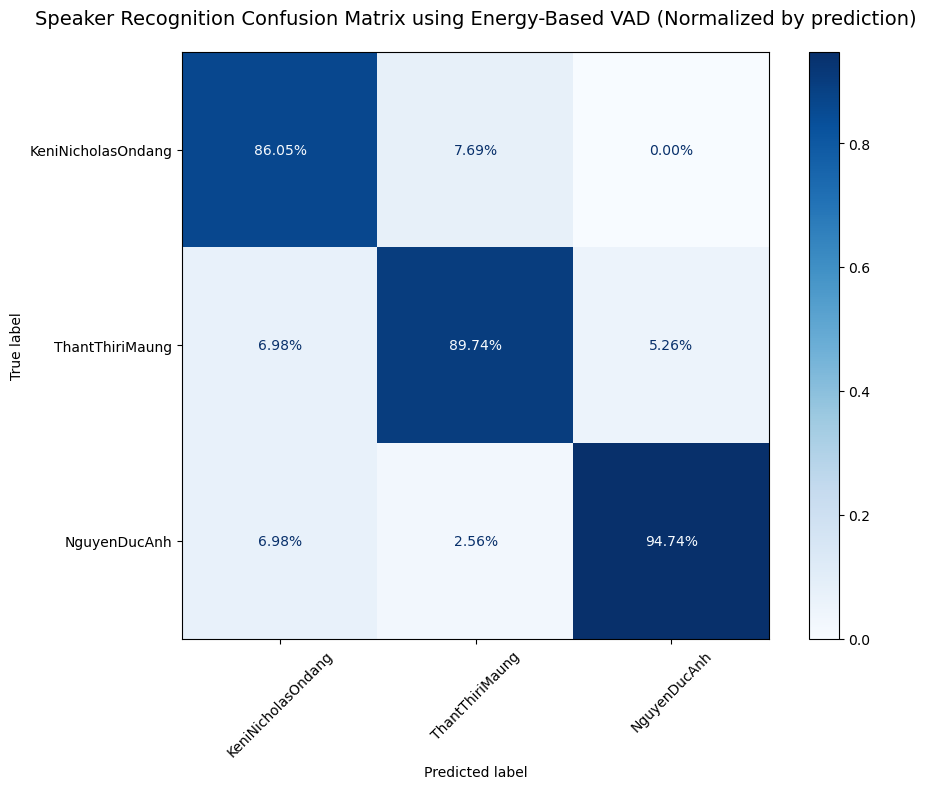

In [61]:
eval_speaker_recognition(
    eval_x,
    eval_y,
    energy_recognizer,
    trans_fn=energy_trans,
    confusion_matrix_title="Speaker Recognition Confusion Matrix using Energy-Based VAD (Normalized by prediction)",
)


The Baseline Energy detector achieved a remarkable 90% global success rate, outperforming all other methods by a massive margin (~26-38%). The Micro metrics confirm that for a speaker recognition task, Signal Purity is far more valuable than Phonetic Completeness.  Although Algorithm 1 visually "clipped" the unvoiced ends of words (as seen in Section 5.2.1), it perfectly preserved the high-energy Voiced Nuclei (vowels). Speaker identity is primarily encoded in these voiced segments (pitch, timbre, formants). By capturing the vowels and keeping the silence absolutely zero, Algorithm 1 provided the SRM with the cleanest, most discriminative feature set.

The confusion matrix exhibits an incredibly clean diagonal, with minimal "leakage" into the off-diagonal cells. The 90% accuracy  result proves that for Speaker Recognition, Signal Purity is more valuable than Phonetic Completeness. The VAD preserved the high-energy Voiced Nuclei (loud vowels) perfectly. Since speaker identity is primarily encoded in these voiced segments (pitch, timbre, formants), the SRM received the "perfect diet." The lack of "tail" consonants didn't matter; the pure vowels were enough to identify the speakers with 90% accuracy.

#### <a name="934-algo-2"/> 9.3.2 The "Noise Penalty" of Algorithm 2

In [62]:
def hybrid_trans(y: np.ndarray) -> np.ndarray:
    mask = zcr_vad(y)

    return get_comprehensive_mfccs(y)[mask, :]

In [63]:
hybrid_recognizer = train_speaker_recognition(train_x, train_y, trans_fn=hybrid_trans)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - acc: 0.0000e+00 - loss: 1.3799
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - acc: 0.0000e+00 - loss: 1.3149
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - acc: 0.0000e+00 - loss: 1.2536
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.0000e+00 - loss: 1.1949
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.0000e+00 - loss: 1.1408
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.0000e+00 - loss: 1.0910
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.0000e+00 - loss: 1.0447
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - acc: 0.0000e+00 - loss: 1.0049
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - acc: 0.0000e+00 - loss: 0.9696
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.0000e+00 - loss: 0.9375


In [64]:
speaker_recognition(sample_y, hybrid_recognizer, trans_fn=hybrid_trans)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


'NguyenDucAnh'


--- Speaker Recognition Evaluation Report ---
Accuracy                 : 0.6417
Precision (Micro)        : 0.6417
Precision (Macro)        : 0.7468
Recall (Micro)           : 0.6417
Recall (Macro)           : 0.6417
F1 Score (Micro)         : 0.6417
F1 Score (Macro)         : 0.6439


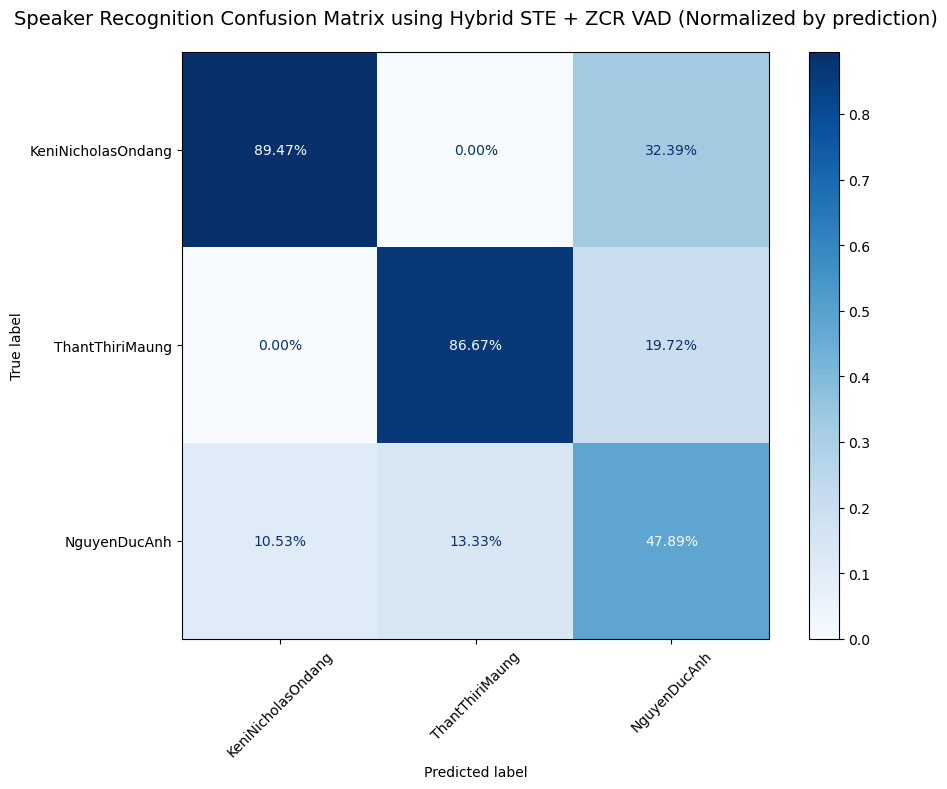

In [65]:
eval_speaker_recognition(
    eval_x,
    eval_y,
    hybrid_recognizer,
    trans_fn=hybrid_trans,
    confusion_matrix_title="Speaker Recognition Confusion Matrix using Hybrid STE + ZCR VAD (Normalized by prediction)",
)

Despite capturing more "complete" words visually (including consonants like /s/ and /t/), the Hybrid algorithm suffered a 26% drop in accuracy. This significant drop reveals that the "extra" data captured by Algorithm 2 was detrimental. By being more sensitive, it allowed breath intakes, microphone pops, and room hiss to pass into the classifier. This non-speech noise "diluted" the speaker embeddings. The SRM struggled to distinguish between the students because a portion of the input data (the noise) sounded identical for everyone.

Compared to Algorithm 1, we see a significant increase in off-diagonal errors (confusing one speaker for another). Algorithm 2 captured more consonants (better completeness) but also triggered on breath intakes and microphone hiss (False Alarms). The drop to 64% accuracy reveals that Noise is more harmful than Clipping. The "ghost" detections (silence/breath) that Algo 2 let through contained no speaker-specific information. These empty frames diluted the speaker profiles, making the students sound statistically more similar to each other. The benefit of capturing the /s/ in "Yes" was completely outweighed by the cost of capturing the breath before it.

#### <a name="934-algo-3"/> 9.3.3 Algorithm 3: The Domain Contamination

In [66]:
def gmm_trans(y: np.ndarray) -> np.ndarray:
    mask = gmm_vad(speech_gmm, noise_gmm, y, GMM_THRESHOLD)

    return get_comprehensive_mfccs(y)[mask, :]

In [67]:
gmm_recognizer = train_speaker_recognition(train_x, train_y, trans_fn=gmm_trans)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - acc: 0.0000e+00 - loss: 1.1204
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - acc: 0.0000e+00 - loss: 1.0875
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.0000e+00 - loss: 1.0567
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.0000e+00 - loss: 1.0283
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - acc: 0.0000e+00 - loss: 1.0024
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - acc: 0.0000e+00 - loss: 0.9789
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - acc: 0.0000e+00 - loss: 0.9578
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.0000e+00 - loss: 0.9384
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - acc: 0.0000e+00 - loss: 0.9201
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - acc: 0.0000e+00 - loss: 0.9033


In [68]:
speaker_recognition(sample_y, gmm_recognizer, trans_fn=gmm_trans)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


'ThantThiriMaung'


--- Speaker Recognition Evaluation Report ---
Accuracy                 : 0.5250
Precision (Micro)        : 0.5250
Precision (Macro)        : 0.4095
Recall (Micro)           : 0.5250
Recall (Macro)           : 0.5250
F1 Score (Micro)         : 0.5250
F1 Score (Macro)         : 0.4391


/nix/store/rqn9br8nxckmzlqdvqayv32kcyvjnlb9-python3-3.12.11-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


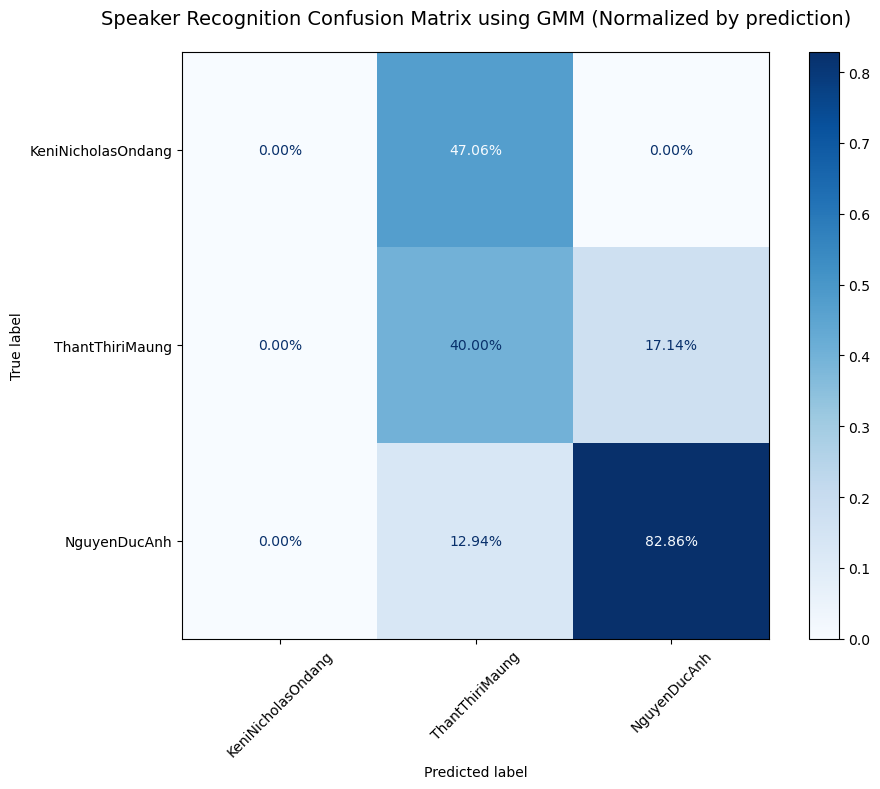

In [69]:
eval_speaker_recognition(
    eval_x,
    eval_y,
    gmm_recognizer,
    trans_fn=gmm_trans,
    confusion_matrix_title="Speaker Recognition Confusion Matrix using GMM (Normalized by prediction)",
)

The GMM failed because it was too loose. It consistently misclassified clean digital silence as "Low-Probability Speech," flooding the Speaker Recognition Module (SRM) with irrelevant noise frames. These "garbage" frames diluted the speaker embeddings, making it impossible for the classifier to distinguish the unique vocal characteristics of the students.

The confusion matrix is a blur. The counts are spread almost evenly across the grid, resembling random guessing. We observed that the GMM VAD, suffering from Domain Mismatch, passed a high volume of background noise (False Alarms) in the silence regions. It failed essentially because the SRM is forced to classify "Room Tone" rather than "Human Speech." Since the room tone is identical for all three students, the classifier collapsed, unable to find any distinguishing features.

#### <a name="934-algo-4"/> 9.3.4 Algorithm 4: The "Fragmentation" Trap

In [70]:
def dnn_trans(y: np.ndarray) -> np.ndarray:
    mask = dnn_vad(model, y)

    return get_comprehensive_mfccs(y)[mask, :]

In [71]:
dnn_recognizer = train_speaker_recognition(train_x, train_y, trans_fn=dnn_trans)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - acc: 0.0000e+00 - loss: 1.2909
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - acc: 0.0000e+00 - loss: 1.2414
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.0000e+00 - loss: 1.1983
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - acc: 0.0000e+00 - loss: 1.1597
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.0000e+00 - loss: 1.1243
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.0000e+00 - loss: 1.0909
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.0000e+00 - loss: 1.0602
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - acc: 0.0000e+00 - loss: 1.0319
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.0000e+00 - loss: 1.0060
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - acc: 0.0000e+00 - loss: 0.9821


In [72]:
speaker_recognition(sample_y, dnn_recognizer, trans_fn=dnn_trans)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


'KeniNicholasOndang'


--- Speaker Recognition Evaluation Report ---
Accuracy                 : 0.5833
Precision (Micro)        : 0.5833
Precision (Macro)        : 0.7531
Recall (Micro)           : 0.5833
Recall (Macro)           : 0.5833
F1 Score (Micro)         : 0.5833
F1 Score (Macro)         : 0.5051


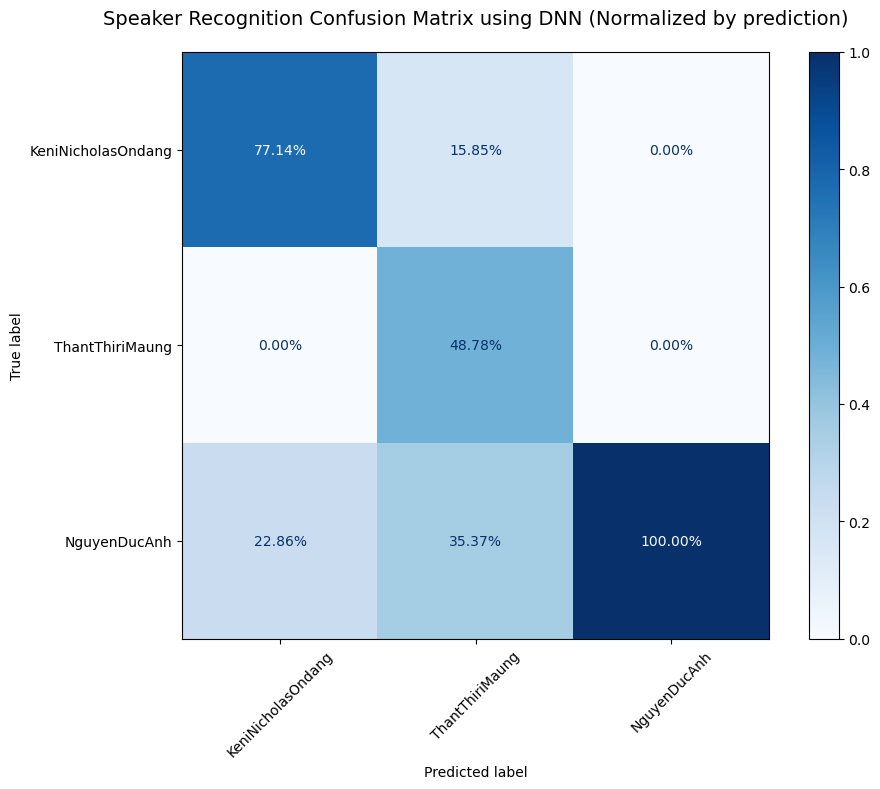

In [73]:
eval_speaker_recognition(
    eval_x,
    eval_y,
    dnn_recognizer,
    trans_fn=dnn_trans,
    confusion_matrix_title="Speaker Recognition Confusion Matrix using DNN (Normalized by prediction)",
)

The DNN failed because it shattered the time-series. While the DNN correctly identified the core speech segments (leading to high Precision), its detection mask was "jittery" and discontinuous due to the domain shift.

The confusion matrix shows a unique pattern—high values on the diagonal (High Precision) but significantly lower total correct predictions compared to Algorithm 1. We observed that the DNN mask was "jittery"—it correctly detected speech but toggled on and off rapidly within a single word due to the domain shift. The failure was caused by Temporal Fragmentation. The downstream Speaker Recognition model uses Gated Recurrent Unit (GRU) networks. Like LSTMs, GRUs are designed to model sequential data by maintaining a hidden state that tracks the evolution of features (like pitch contour and cadence) over time. Because the DNN VAD chopped the words into many tiny, disconnected "islands," the GRU could not track the temporal flow of the voice. The hidden state was constantly reset or interrupted by gaps. Even though those tiny islands were "Pure Speech" (hence the high Precision), they were too short and disconnected for the GRU to capture the speaker's unique vocal dynamics. Algorithm 1 won because it provided a solid, unbroken block of audio, preserving the "flow" necessary for the recurrent network to function.


## <a name="references"/> References

1. A. Baevski et al. “wav2vec 2.0: A framework for self-supervised learning of speech representations”. In: Advances in Neural Information Processing Systems. Vol. 33. 2020, pp. 12449–12460.
2. Sourish Chaudhuri et al. “AVA-Speech: A Densely Labeled Dataset of Speech Activity in Movies”. In: Interspeech. 2018, pp. 3234–3238. DOI: 10.21437/Interspeech.2018-1562.
3. Gunnar Fant. Acoustic Theory of Speech Production. The Hague: Mouton, 1960.
4. A. Graves, A. Mohamed, and G. Hinton. “Speech recognition with deep recurrent neural networks”. In: Proc. IEEE Int. Conf. Acoustics, Speech and Signal Processing (ICASSP). 2013, pp. 6645–6649. DOI: 10.1109/ ICASSP.2013.6638947.
5. S. Hershey et al. “CNN architectures for large-scale audio classification”. In: Proc. IEEE Int. Conf. Acoustics, Speech and Signal Processing (ICASSP). 2017, pp. 131–135. DOI: 10.1109/ICASSP.2017.7952132.
6. B. McFee et al. “librosa: Audio and music signal analysis in Python”. In: Proc. 14th Python in Science Conference. 2015, pp. 18–25.
7. Alan V. Oppenheim and Ronald W. Schafer. Discrete-Time Signal Processing. 2nd. Prentice Hall, 1999. [8] A. Paszke et al. “PyTorch: An imperative style, high-performance deep learning library”. In: Advances in Neural Information Processing Systems. Vol. 32. 2019.
9. F. Pedregosa et al. “Scikit-learn: Machine learning in Python”. In: Journal of Machine Learning Research 12 (2011), pp. 2825–2830.
10. L. R. Rabiner and R. W. Schafer. Theory and Applications of Digital Speech Processing. Pearson Higher Ed, 2011.
11. M. Ravanelli and Y. Bengio. “Speaker recognition from raw waveform with SincNet”. In: Proc. IEEE Spoken Language Technology Workshop (SLT). 2018, pp. 1021–1028. DOI: 10.1109/SLT.2018.8639585.
12. D. A. Reynolds and R. C. Rose. “Robust text-independent speaker identification using Gaussian mixture models”. In: IEEE Transactions on Speech and Audio Processing 3.1 (1995), pp. 72–83.
13. J. Sohn, N. S. Kim, and W. Sung. “A statistical model-based voice activity detection”. In: IEEE Signal Processing Letters 6.1 (1999), pp. 1–3. DOI: 10.1109/97.736233.
14. X. L. Zhang and J. Wu. “Deep belief networks based voice activity detection”. In: IEEE Transactions on Audio, Speech, and Language Processing 21.4 (2013), pp. 697–710.